## XL092-123 — Raw-to-TLF Pipeline  
`raw_2_tlf_v1`  |  Two-arm oncology POC (Active 15 mg vs Active 25 mg, N=200 SAF)

---

### Run Order

| Cell | Stage | What it does | Key outputs / views |
|------|-------|-------------|---------------------|
| 1 | Setup | Locate YAML spec files in the workspace | sets `PROJECT_ROOT`, `DOMAINS_DIR` |
| 2 | Setup | Paths, logging, `safe_row_count()` / `safe_preview()` helpers; `REUSE_TIMESTAMP` flag | sets `TS`, `OUT_TS_DIR` |
| 3 | Pseudodata | Generate 220 subjects (100/arm + 20 SF), AE, LB, TR source views. **`NEW_RUN=True`** stamps a fresh output folder on every partial re-run | `dm_id_raw`, `ae_raw`, `lbl_raw`, `tr_sldia_raw`, `*_prepped` views |
| 4 | Standards | Load CDISC CT JSON (1 145 codelists, sdtmct-2024-09-27) | `ct_data` dict |
| 5 | Standards | Parse DM / AE / LB YAML domain specs | `domain_specs` dict |
| 6 | SDTM | YAML-driven SDTM domain build (DM first, then AE, LB) | `sdtmdata_dm`, `sdtmdata_ae`, `sdtmdata_lb` |
| 7 | SDTM | Quick row/column sanity check on built domains | console only |
| 8 | SDTM | Post-build validation: MedDRA completeness, CT conformance, cross-domain referential integrity | console QC report |
| 9 | Deps | `%pip install pyreadstat` (SAS XPT writer) | — |
| 10 | SDTM | Export XPT v5 transport files + SUPPQUAL | `sdtm_xpt/dm.xpt`, `ae.xpt`, `lb.xpt` |
| 11 | SDTM | Generate CDISC Define-XML 2.1 with XSL stylesheet | `define.xml`, `define2-1-0.xsl` |
| 12 | Stub | Email notification placeholder (disabled) | — |
| 13 | ADaM | Derive ADSL, ADAE, ADLB, ADTTE, ADTR, ADRS; export CSVs | `adam_*` views, `adam/*.csv` |
| 14 | TLF | Build 6 summary tables (disposition, demographics, AE overview, AE by SOC/PT, lab summary, response rate) | `tlf/t_*.csv/.html` |
| 15 | TLF | Figure 14.3.1 AE incidence, Figure 14.5.1 KM plot, Listings 16.1.1 + 16.2.1 | `tlf/figure_14_{3,5}_1_*.png`, listing CSVs/HTML |
| 16 | TLF | Figure 14.7.1 Lab shift plot (baseline vs Week 5 by arm) | `tlf/figure_14_7_1_lab_shift.png` |
| 17 | TLF | Figures 14.5.2 Forest, 14.6.1 Waterfall, 14.6.2 Spider, 14.7.2 Lab CFB, 14.8.1 Swim | `tlf/figure_14_{5,6,7,8}_*.png` |
| 18 | Summary | Final view inventory and output-path report | console only |

---

### Key Flags

| Flag | Cell | Default | Effect |
|------|------|---------|--------|
| `NEW_RUN` | 3 | `True` | `True` = fresh timestamped folder on every run from Cell 3 onward; `False` = reuse `TS` from Cell 2 |
| `REUSE_TIMESTAMP` | 2 | `None` | Override with a string (e.g. `"20260708T185048Z"`) to write into an existing run folder |
| `SUBJECTS_PER_TREATMENT_ARM` | 3 | `100` | Scale pseudodata volume |
| `RUN_ROW_COUNTS` | 2 | `False` | Enable `.count()` calls in diagnostic prints |
| `RUN_DATA_PREVIEW` | 2 | `False` | Enable `.show()` calls in diagnostic prints |

### Output Structure
```
out/<TS>/
├── sdtm_xpt/   dm.xpt  ae.xpt  lb.xpt
├── adam/        adsl  adae  adlb  adtte  adtr  adrs  .csv
├── tlf/         8 figures (PNG)  6 tables (CSV+HTML)  2 listings (CSV+HTML)
└── define.xml   Define-XML 2.1
```

## How YAML Drives the Raw-to-SDTM Build

### Why SDTM exists

Before regulators (FDA, EMA) will review a clinical trial, all collected data must be
reorganised into a standard format called **SDTM** (Study Data Tabulation Model).
SDTM defines exactly what columns exist in each dataset ("domain"), what they mean,
and what values are allowed. This makes it possible for reviewers to write standard
software that reads any sponsor’s submission without needing to learn each company’s
bespoke data layout.

| SDTM domain | What it contains | Typical raw source |
|-------------|-----------------|--------------------|
| **DM** — Demographics | One row per subject: age, sex, race, treatment arm, population flags | Subject enrolment CRF |
| **AE** — Adverse Events | One row per AE record: term, severity, seriousness, dates | AE CRF / SAE database |
| **LB** — Laboratory | One row per test result at each visit: value, unit, reference range | Central lab data transfer |

---

### The core problem: every sponsor’s raw data looks different

Raw clinical data is collected in proprietary EDC systems (e.g. Medidata Rave, Veeva
Vault) and the column names, date formats, and coded values almost never match SDTM
out of the box. For example:

| Raw column in EDC | What it really means | Required SDTM column |
|-------------------|---------------------|----------------------|
| `AE_PT_TEXT` | Adverse event preferred term | `AEDECOD` |
| `LBDAT` ("01JAN2026") | Lab sample date | `LBDTC` (ISO 8601: "2026-01-01") |
| `AESERIOU` = "YES" | Serious AE flag | `AESER` = "Y" |
| `ARMCD_STD` = "A25" | Treatment arm code | `ARMCD` = "A25" |

Hardcoding these mappings directly in Python makes the code fragile and impossible to
reuse across studies. Instead, this pipeline stores every mapping in **YAML specification
files** — one file per SDTM domain.

---

### What a YAML domain spec file contains

Each `.yaml` file (stored in `specs/domains/`) is a plain-text blueprint that describes
how to build one SDTM domain. It has four main sections:

```yaml
# ae.yaml (simplified example)
domain: AE
label: Adverse Events
source_view: ae_prepped        # which raw/prepped Spark view to read from
depends_on: [DM]               # must join DM first to get USUBJID and treatment info

variables:
  - name: USUBJID
    derivation: "USUBJID"      # pass-through: column already has the right name

  - name: AEDECOD
    derivation: "UPPER(TRIM(AETERM_PT))"   # SQL expression applied to the raw column

  - name: AESER
    derivation: "CASE WHEN AESERIOU = 'YES' THEN 'Y' ELSE 'N' END"

  - name: AESTDTC
    derivation: "DATE_FORMAT(TO_DATE(AEDAT,'ddMMMyyyy'), 'yyyy-MM-dd')"
    # converts sponsor date format 01JAN2026 → ISO 8601 2026-01-01

  - name: AETOXGR
    derivation: "CAST(AE_CTCGRADE AS STRING)"   # cast integer grade to string

suppqual_variables:            # sponsor-specific extra fields — go into SUPPAE
  - name: AECONTRT
    label: "Concomitant Treatment Given"
    derivation: "AECONTRT_STD"
```

The Python builder in **Cell 6** reads this file, loops over the `variables` list, and
builds a single Spark SQL `SELECT` statement automatically.

---

### Sponsor-specific specifications

Two types of sponsor customisation live in the YAML files:

**1. Non-standard variables — SUPPQUAL datasets**  
SDTM has a fixed column set per domain. Sponsors frequently collect extra variables
that have no SDTM equivalent (e.g. a custom biomarker, a protocol-specific question).
These go into supplementary datasets called **SUPPQUAL** (e.g. SUPPAE for AE extras).
The `suppqual_variables` section of the YAML handles this automatically — the builder
generates the vertical SUPP structure (RDOMAIN, IDVAR, IDVARVAL, QNAM, QLABEL, QVAL)
without any extra code.

**2. Post-processing methods**  
Some SDTM columns require logic that can’t be expressed in a single SQL expression:
- `[XL_SEQ]` — assigns a sequence number (e.g. AESEQ = 1, 2, 3 … per subject)
- `[XL_EPOCH]` — derives the study epoch from visit dates
- `[XL_DY]` — computes study day (e.g. AEDY = AESTDTC − RFSTDTC + 1)

These are flagged in the YAML as special tags and handled by dedicated Python functions
in Cell 6 after the main SELECT is applied.

---

### How controlled terminology is enforced

CDISC publishes approved value lists for many SDTM columns — for example, `SEX` must
be one of {M, F, U, UNDIFFERENTIATED} and `RACE` must use specific codes. These lists
are called **Controlled Terminology (CT)**.

- **Cell 4** loads the full CT package (1 145 codelists from `sdtmct-2024-09-27.json`).
- **Cell 8** (Post-Build Validation) checks every coded column against the CT and reports
  any values that don’t conform — catching mapping errors before they reach the
  Define-XML or submission package.

---

### Build order: why DM must come first

Every other domain needs to JOIN to the DM domain to inherit subject-level fields
(USUBJID, RFSTDTC, RFXSTDTC, ARM, ARMCD). The YAML `depends_on` field declares
these dependencies, and Cell 5 uses a topological sort to resolve the correct
build sequence automatically. In this study: **DM → AE → LB**.

---

### End-to-end flow (Cells 1 – 11)

```
Raw EDC data                  Specs / standards
(pseudodata, Cell 3)          (YAML files, Cell 5)
        │                             │
        └───────── Cell 6 (SDTM Build) ─────────┘
                         │
                         ▼
              sdtmdata_dm / sdtmdata_ae / sdtmdata_lb
              (Spark temp views, in-memory)
                         │
              ┌─────────┴─────────┐
              │                   │
         Cell 8              Cell 10
     QC / Validation       XPT v5 export     → Cell 11 Define-XML
     (CT, MedDRA,           (dm.xpt,
      cross-domain)          ae.xpt, lb.xpt)
```

After this point, the `adam_*` views (Cell 13) are derived from these same SDTM views,
and the TLF outputs (Cells 14–17) are derived from the `adam_*` views.

In [0]:
# =============================================================================
# Program : raw_2_tlf_v1
# Purpose : End-to-end clinical study pipeline — raw pseudodata → SDTM → ADaM → TLF.
# Study   : XL092-123  |  Two-arm oncology POC  |  N = 200 SAF
# Notes   : Run Cells 1–18 in order.
#           Cell 3 NEW_RUN flag controls output folder stamping.
#           YAML specs are read from the Databricks workspace path.
# =============================================================================

In [0]:
# =============================================================================
# CELL 1: YAML Spec Path Discovery
# =============================================================================
# Purpose:
#   Use the YAML files that are already stored in the Databricks workspace.
#
# User-provided Databricks workspace location:
#   /Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains
#
# Notes:
#   In Databricks Python, workspace files are commonly available under:
#   /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains
#
#   This cell checks both forms and uses the first path that actually exists.
#   There is no specs.zip extraction in this version.
# =============================================================================
from pathlib import Path
import os

USER_DOMAINS_PATH_TEXT = "/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains"

candidate_domains_dirs = [
    Path("/Workspace" + USER_DOMAINS_PATH_TEXT),
    Path(USER_DOMAINS_PATH_TEXT),
    Path("/dbfs/FileStore/SDTM_Build_POC/specs/domains"),
]

DOMAINS_DIR_SETUP = None
for candidate in candidate_domains_dirs:
    if candidate.exists() and candidate.is_dir():
        DOMAINS_DIR_SETUP = candidate
        break

if DOMAINS_DIR_SETUP is None:
    print("=" * 70)
    print("DATABRICKS YAML SPECS SETUP")
    print("=" * 70)
    print("ERROR: Could not find the YAML domains folder in any expected location.")
    print("")
    print("Checked these locations:")
    for candidate in candidate_domains_dirs:
        print(f"  {candidate}")
    print("")
    print("Expected files include dm.yaml, ae.yaml, and lb.yaml.")
    raise FileNotFoundError("YAML domains folder was not found in Databricks.")

SPECS_DIR_SETUP = DOMAINS_DIR_SETUP.parent
PROJECT_ROOT_SETUP = SPECS_DIR_SETUP.parent
PROJECT_ROOT_VALUE = str(PROJECT_ROOT_SETUP)

os.environ["PROJECT_ROOT"] = PROJECT_ROOT_VALUE
os.environ["SPECS_DIR"] = str(SPECS_DIR_SETUP)
os.environ["DOMAINS_DIR"] = str(DOMAINS_DIR_SETUP)

required_yaml_setup = ["dm.yaml", "ae.yaml", "lb.yaml"]
missing_yaml_setup = []

print("=" * 70)
print("DATABRICKS YAML SPECS SETUP")
print("=" * 70)
print(f"Project root : {PROJECT_ROOT_SETUP}")
print(f"Specs folder : {SPECS_DIR_SETUP}")
print(f"Domains dir  : {DOMAINS_DIR_SETUP}")
print("")
print("Required YAML check:")

for fname in required_yaml_setup:
    fpath = DOMAINS_DIR_SETUP / fname
    if fpath.exists():
        print(f"  OK:      {fpath}")
    else:
        print(f"  MISSING: {fpath}")
        missing_yaml_setup.append(fname)

print("=" * 70)

if missing_yaml_setup:
    print("YAML setup is not complete.")
    print(f"Missing YAML files: {missing_yaml_setup}")
    raise RuntimeError("Required YAML files are missing in the Databricks domains folder.")
else:
    print("YAML setup complete. Continue with Cell 2.")

DATABRICKS YAML SPECS SETUP
Project root : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC
Specs folder : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs
Domains dir  : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains

Required YAML check:
  OK:      /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains/dm.yaml
  OK:      /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains/ae.yaml
  OK:      /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains/lb.yaml
YAML setup complete. Continue with Cell 2.


In [0]:
# =============================================================================
# CELL 2: Environment and Path Setup
# =============================================================================
# Purpose:
#   Initialize paths and runtime flags for Databricks.
#
# Databricks changes:
#   - Do not create SparkSession with master("local[*]"). Databricks already
#     provides the active Spark session as spark.
#   - Do not use Windows C drive paths.
#   - Use PROJECT_ROOT from Cell 0 / environment variable.
# =============================================================================
import os
import sys
import json
import warnings
import logging
from datetime import datetime, timezone
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

RUN_ROW_COUNTS = False
RUN_DATA_PREVIEW = False
SEND_EMAIL = False

try:
    spark
except NameError as exc:
    raise RuntimeError("Spark session named spark is not available. Attach this notebook to a Databricks cluster.") from exc

try:
    dbutils
    running_in_databricks = True
except NameError:
    running_in_databricks = False

PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", "/dbfs/FileStore/SDTM_Build_POC")).resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUT_ROOT = PROJECT_ROOT / "out"
SPECS_DIR = Path(os.environ.get("SPECS_DIR", str(PROJECT_ROOT / "specs"))).resolve()
DOMAINS_DIR = Path(os.environ.get("DOMAINS_DIR", str(SPECS_DIR / "domains"))).resolve()
CT_DIR = SPECS_DIR / "ct"
RULES_DIR = SPECS_DIR / "rules"
DICT_DIR = SPECS_DIR / "dictionaries"

for d in [DATA_DIR, OUT_ROOT, DOMAINS_DIR, CT_DIR, RULES_DIR, DICT_DIR / "meddra", DICT_DIR / "whodrug"]:
    d.mkdir(parents=True, exist_ok=True)

REUSE_TIMESTAMP = None
TS = REUSE_TIMESTAMP if REUSE_TIMESTAMP else datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

OUT_TS_DIR = OUT_ROOT / TS
XPT_DIR = OUT_TS_DIR / "sdtm_xpt"
PARQUET_DIR = OUT_TS_DIR / "parquet"
QC_DIR = OUT_TS_DIR / "qc"
STATS_DIR = OUT_TS_DIR / "summary_stats"
CHARTS_DIR = OUT_TS_DIR / "charts"

for d in [OUT_TS_DIR, XPT_DIR, PARQUET_DIR, QC_DIR, STATS_DIR, CHARTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for domain in ["DM", "AE", "LB"]:
    (CHARTS_DIR / domain).mkdir(parents=True, exist_ok=True)

spark.conf.set("spark.sql.session.timeZone", "UTC")
for logger_name in ["pyspark", "pyspark.sql.connect"]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

def safe_row_count(df_or_view):
    if not RUN_ROW_COUNTS:
        return "not counted"
    if isinstance(df_or_view, str):
        return spark.table(df_or_view).count()
    return df_or_view.count()

def safe_preview(df, n=5, truncate=False):
    if RUN_DATA_PREVIEW:
        df.show(n, truncate=truncate)
    else:
        print("  Data preview skipped because RUN_DATA_PREVIEW = False")

print("=" * 70)
print("SDTM BUILD POC - DATABRICKS STARTUP")
print("=" * 70)
print(f"Environment     : {'Databricks' if running_in_databricks else 'Non-Databricks'}")
print(f"Project Root    : {PROJECT_ROOT}")
print(f"Specs Dir       : {SPECS_DIR}")
print(f"Domains Dir     : {DOMAINS_DIR}")
print(f"Timestamp       : {TS}")
print(f"Output Dir      : {OUT_TS_DIR}")
print(f"Spark Version   : {spark.version}")
print("=" * 70)

SDTM BUILD POC - DATABRICKS STARTUP
Environment     : Databricks
Project Root    : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC
Specs Dir       : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs
Domains Dir     : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains
Timestamp       : 20260716T202616Z
Output Dir      : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202616Z
Spark Version   : 4.1.0


In [0]:
# =============================================================================
# CELL 3: Pseudodata Generation
# =============================================================================
# Purpose:
#   Replace the tiny hand-written pseudodata with scalable programmatic
#   pseudodata while preserving the raw/prepped view names used downstream.
#
# Default scale in this cell:
#   * 100 subjects per treatment arm
#   * 20 additional screen failures
#
# To change the scale later, update SUBJECTS_PER_TREATMENT_ARM and/or
# SCREEN_FAILURE_SUBJECTS, then rerun this cell and the downstream build cells.
# =============================================================================

# ---------------------------------------------------------------------------
# NEW_RUN: True  = fresh timestamped output folder on every run from Cell 2B.
#          False = reuse the folder from the last Cell 1 run.
# This makes partial re-runs (Cell 2B onward) fully self-contained.
# ---------------------------------------------------------------------------
NEW_RUN = True
if NEW_RUN:
    from datetime import datetime as _dt, timezone as _tz
    TS = _dt.now(_tz.utc).strftime("%Y%m%dT%H%M%SZ")
    OUT_TS_DIR = OUT_ROOT / TS
    XPT_DIR    = OUT_TS_DIR / "sdtm_xpt"
    for _d in [OUT_TS_DIR, XPT_DIR]:
        _d.mkdir(parents=True, exist_ok=True)
    print(f"NEW_RUN=True  \u2192 fresh output folder: {TS}")
else:
    print(f"NEW_RUN=False \u2192 reusing existing  : {TS}")

import pandas as pd
import numpy as np
from datetime import date, timedelta
from pyspark.sql import functions as F

PSEUDO_RANDOM_SEED = 311
SUBJECTS_PER_TREATMENT_ARM = 100
SCREEN_FAILURE_SUBJECTS = 20
rng = np.random.default_rng(PSEUDO_RANDOM_SEED)

ARM_CONFIGS = [
    {"armcd": "A15", "arm": "Active Treatment 15 mg", "site": "101", "mean_age": 63, "female_prob": 0.46},
    {"armcd": "A25", "arm": "Active Treatment 25 mg", "site": "102", "mean_age": 61, "female_prob": 0.54},
]
RACE_LEVELS = [
    "WHITE",
    "ASIAN",
    "BLACK OR AFRICAN AMERICAN",
    "AMERICAN INDIAN OR ALASKA NATIVE",
    "OTHER",
]
RACE_PROBS = [0.55, 0.18, 0.17, 0.03, 0.07]
ETHNIC_LEVELS = ["NOT HISPANIC OR LATINO", "HISPANIC OR LATINO"]
ETHNIC_PROBS = [0.82, 0.18]
STRATA_LEVELS = ["Prior Therapy: Yes", "Prior Therapy: No"]
STRATA_PROBS = [0.42, 0.58]

AE_LIBRARY = [
    {
        "AETERM": "DIARRHEA", "AETERM_LLT": "Diarrhea", "AETERM_LLT_CODE": "10012727",
        "AETERM_PT": "Diarrhoea", "AETERM_PT_CODE": "10012735",
        "AETERM_HLT": "Diarrhoea excluding infective", "AETERM_HLT_CODE": "10012736",
        "AETERM_HLGT": "Gastrointestinal motility and defaecation conditions", "AETERM_HLGT_CODE": "10017977",
        "AETERM_SOC": "Gastrointestinal disorders", "AETERM_SOC_CODE": "10017947",
        "serious_prob": 0.03,
    },
    {
        "AETERM": "FATIGUE", "AETERM_LLT": "Fatigue", "AETERM_LLT_CODE": "10016256",
        "AETERM_PT": "Fatigue", "AETERM_PT_CODE": "10016256",
        "AETERM_HLT": "Asthenic conditions", "AETERM_HLT_CODE": "10003550",
        "AETERM_HLGT": "General system disorders NEC", "AETERM_HLGT_CODE": "10018073",
        "AETERM_SOC": "General disorders and administration site conditions", "AETERM_SOC_CODE": "10018065",
        "serious_prob": 0.02,
    },
    {
        "AETERM": "NAUSEA", "AETERM_LLT": "Nausea", "AETERM_LLT_CODE": "10028813",
        "AETERM_PT": "Nausea", "AETERM_PT_CODE": "10028813",
        "AETERM_HLT": "Nausea and vomiting symptoms", "AETERM_HLT_CODE": "10028817",
        "AETERM_HLGT": "Gastrointestinal signs and symptoms", "AETERM_HLGT_CODE": "10017983",
        "AETERM_SOC": "Gastrointestinal disorders", "AETERM_SOC_CODE": "10017947",
        "serious_prob": 0.01,
    },
    {
        "AETERM": "ALANINE AMINOTRANSFERASE INCREASED", "AETERM_LLT": "Alanine aminotransferase increased", "AETERM_LLT_CODE": "10001551",
        "AETERM_PT": "Alanine aminotransferase increased", "AETERM_PT_CODE": "10001551",
        "AETERM_HLT": "Hepatocellular damage and hepatitis NEC", "AETERM_HLT_CODE": "10019654",
        "AETERM_HLGT": "Hepatobiliary investigations, signs and symptoms", "AETERM_HLGT_CODE": "10019805",
        "AETERM_SOC": "Investigations", "AETERM_SOC_CODE": "10022891",
        "serious_prob": 0.04,
    },
    {
        "AETERM": "NEUTROPHIL COUNT DECREASED", "AETERM_LLT": "Neutrophil count decreased", "AETERM_LLT_CODE": "10029354",
        "AETERM_PT": "Neutrophil count decreased", "AETERM_PT_CODE": "10029354",
        "AETERM_HLT": "White blood cell analyses", "AETERM_HLT_CODE": "10048031",
        "AETERM_HLGT": "Haematology analyses", "AETERM_HLGT_CODE": "10018729",
        "AETERM_SOC": "Investigations", "AETERM_SOC_CODE": "10022891",
        "serious_prob": 0.08,
    },
]

LB_TEST_LIBRARY = [
    {"LBTESTCD": "ALB", "LBTEST": "Albumin", "LBCAT": "CHEMISTRY", "LBORRESU": "g/dL", "LBORNRLO": 3.5, "LBORNRHI": 5.2, "std_factor": 10.0, "LLSTRESU": "g/L", "LLSTNRLO": 35.0, "LLSTNRHI": 52.0, "mean_A15": 4.1, "mean_A25": 4.2, "sd": 0.25, "decimals": 1},
    {"LBTESTCD": "ALT", "LBTEST": "Alanine Aminotransferase", "LBCAT": "CHEMISTRY", "LBORRESU": "U/L", "LBORNRLO": 0.0, "LBORNRHI": 55.0, "std_factor": 1.0, "LLSTRESU": "U/L", "LLSTNRLO": 0.0, "LLSTNRHI": 55.0, "mean_A15": 24.0, "mean_A25": 21.0, "sd": 10.0, "decimals": 0},
    {"LBTESTCD": "HGB", "LBTEST": "Hemoglobin", "LBCAT": "HEMATOLOGY", "LBORRESU": "g/dL", "LBORNRLO": 12.0, "LBORNRHI": 16.0, "std_factor": 10.0, "LLSTRESU": "g/L", "LLSTNRLO": 120.0, "LLSTNRHI": 160.0, "mean_A15": 13.6, "mean_A25": 13.9, "sd": 1.1, "decimals": 1},
    {"LBTESTCD": "PLAT", "LBTEST": "Platelets", "LBCAT": "HEMATOLOGY", "LBORRESU": "10^9/L", "LBORNRLO": 150.0, "LBORNRHI": 400.0, "std_factor": 1.0, "LLSTRESU": "10^9/L", "LLSTNRLO": 150.0, "LLSTNRHI": 400.0, "mean_A15": 225.0, "mean_A25": 235.0, "sd": 35.0, "decimals": 0},
]
VISITS = [("Week 1 Day 1", 0), ("Week 5 Day 1", 28)]


def iso_date(value):
    return pd.Timestamp(value).strftime("%Y-%m-%d")


def cdisc_date(value):
    return pd.Timestamp(value).strftime("%d%b%Y").upper()


def publish_temp_view(view_name, pdf):
    spark.createDataFrame(pdf).createOrReplaceTempView(view_name)
    return spark.table(view_name)


subject_records = []
subject_counter = 1
for arm_cfg in ARM_CONFIGS:
    for _ in range(SUBJECTS_PER_TREATMENT_ARM):
        subjid = f"{subject_counter:03d}"
        subject = f"XL092-123-{subjid}"
        consent_dt = date(2025, 7, 1) + timedelta(days=int(rng.integers(0, 90)))
        rand_dt = date(2026, 1, 1) + timedelta(days=int(rng.integers(0, 45)))
        first_dose_dt = rand_dt + timedelta(days=int(rng.integers(0, 2)))
        sex = "F" if rng.random() < arm_cfg["female_prob"] else "M"
        age = int(np.clip(round(rng.normal(arm_cfg["mean_age"], 8.5)), 22, 85))
        race = str(rng.choice(RACE_LEVELS, p=RACE_PROBS))
        ethnic = str(rng.choice(ETHNIC_LEVELS, p=ETHNIC_PROBS))
        childpot = "Y" if sex == "F" and age < 55 and rng.random() < 0.65 else "N"
        strata = str(rng.choice(STRATA_LEVELS, p=STRATA_PROBS))
        subject_records.append({
            "Subject": subject,
            "USUBJID": subject,
            "SUBJID": subjid,
            "SiteNumber": arm_cfg["site"],
            "AGE": str(age),
            "AGEU_STD": "YEARS",
            "SEX_STD": sex,
            "RACE_STD": race,
            "RACE1_STD": race,
            "RACE2_STD": "",
            "RACE3_STD": "",
            "RACE4_STD": "",
            "RACE5_STD": "",
            "ETHNIC_STD": ethnic,
            "COUNTRY": "USA",
            "CHILDPOT_STD": childpot,
            "INVNAM": f"Investigator {arm_cfg['site']}",
            "RFICDAT": iso_date(consent_dt),
            "ENRLYN_STD": "ENROLLED",
            "ARM_STD": arm_cfg["arm"],
            "RANDDAT": iso_date(rand_dt),
            "ARMCD_STD": arm_cfg["armcd"],
            "STRATARN": "1" if strata.endswith("Yes") else "2",
            "STRATAR": strata,
            "ECSTDAT": iso_date(first_dose_dt),
            "ECDOSTOT": "25" if arm_cfg["armcd"] == "A25" else "15",
            "death_dt": iso_date(rand_dt + timedelta(days=int(rng.integers(90, 220)))) if rng.random() < 0.03 else "",
        })
        subject_counter += 1

for _ in range(SCREEN_FAILURE_SUBJECTS):
    subjid = f"{subject_counter:03d}"
    subject = f"XL092-123-{subjid}"
    consent_dt = date(2025, 7, 1) + timedelta(days=int(rng.integers(0, 90)))
    sex = "F" if rng.random() < 0.5 else "M"
    age = int(np.clip(round(rng.normal(60, 9.5)), 22, 85))
    race = str(rng.choice(RACE_LEVELS, p=RACE_PROBS))
    ethnic = str(rng.choice(ETHNIC_LEVELS, p=ETHNIC_PROBS))
    childpot = "Y" if sex == "F" and age < 55 and rng.random() < 0.65 else "N"
    subject_records.append({
        "Subject": subject,
        "USUBJID": subject,
        "SUBJID": subjid,
        "SiteNumber": "103",
        "AGE": str(age),
        "AGEU_STD": "YEARS",
        "SEX_STD": sex,
        "RACE_STD": race,
        "RACE1_STD": race,
        "RACE2_STD": "",
        "RACE3_STD": "",
        "RACE4_STD": "",
        "RACE5_STD": "",
        "ETHNIC_STD": ethnic,
        "COUNTRY": "USA",
        "CHILDPOT_STD": childpot,
        "INVNAM": "Investigator 103",
        "RFICDAT": iso_date(consent_dt),
        "ENRLYN_STD": "SCREEN FAILURE",
        "ARM_STD": "",
        "RANDDAT": "",
        "ARMCD_STD": "",
        "STRATARN": "",
        "STRATAR": "",
        "ECSTDAT": "",
        "ECDOSTOT": "",
        "death_dt": "",
    })
    subject_counter += 1

subjects_pdf = pd.DataFrame(subject_records)
treated_pdf = subjects_pdf[subjects_pdf["ENRLYN_STD"] == "ENROLLED"].copy().reset_index(drop=True)

publish_temp_view("dm_id_raw", subjects_pdf[["Subject", "USUBJID", "SUBJID", "SiteNumber"]])
publish_temp_view(
    "dm_sc_raw",
    subjects_pdf[[
        "Subject", "AGE", "AGEU_STD", "SEX_STD", "RACE_STD", "RACE1_STD", "RACE2_STD",
        "RACE3_STD", "RACE4_STD", "RACE5_STD", "ETHNIC_STD", "COUNTRY", "CHILDPOT_STD", "INVNAM"
    ]],
)
publish_temp_view("ds_ic_raw", subjects_pdf[["Subject", "RFICDAT"]])
publish_temp_view("ds_en_raw", subjects_pdf[["Subject", "ENRLYN_STD", "ARM_STD"]])
publish_temp_view("randomd_raw", treated_pdf[["Subject", "RANDDAT", "ARMCD_STD", "ARM_STD", "STRATARN", "STRATAR"]])

ec_rows = []
for _, row in treated_pdf.iterrows():
    first_dose_dt = pd.Timestamp(row["ECSTDAT"])
    dose = row["ECDOSTOT"]
    for offset in [0, 7, 14]:
        ec_rows.append({
            "Subject": row["Subject"],
            "ECSTDAT": iso_date(first_dose_dt + pd.Timedelta(days=offset)),
            "ECDOSTOT": dose,
        })
publish_temp_view("ec_or1_raw", pd.DataFrame(ec_rows))

ndeaths = max(4, int(0.03 * len(treated_pdf)))
death_subjects = treated_pdf[treated_pdf["death_dt"] != ""].copy()
if len(death_subjects) < ndeaths:
    extra = treated_pdf[~treated_pdf["Subject"].isin(death_subjects["Subject"])].sample(
        n=ndeaths - len(death_subjects),
        random_state=PSEUDO_RANDOM_SEED,
    )
    for idx in extra.index:
        rand_dt = pd.Timestamp(treated_pdf.loc[idx, "RANDDAT"])
        treated_pdf.loc[idx, "death_dt"] = iso_date(rand_dt + pd.Timedelta(days=int(rng.integers(90, 220))))
    death_subjects = treated_pdf[treated_pdf["death_dt"] != ""].copy()
publish_temp_view(
    "dd_raw",
    death_subjects[["Subject", "death_dt"]].rename(columns={"death_dt": "DDDAT"}),
)

ae_rows = []
for _, subj in treated_pdf.iterrows():
    n_events = int(rng.choice([0, 1, 2, 3, 4], p=[0.20, 0.33, 0.25, 0.15, 0.07]))
    if n_events == 0:
        continue
    first_dose_dt = pd.Timestamp(subj["ECSTDAT"])
    for recpos in range(1, n_events + 1):
        tpl = AE_LIBRARY[int(rng.integers(0, len(AE_LIBRARY)))]
        serious = "Y" if rng.random() < tpl["serious_prob"] else "N"
        if serious == "Y":
            grade = str(int(rng.choice([3, 4], p=[0.65, 0.35])))
        else:
            grade = str(int(rng.choice([1, 2, 3], p=[0.50, 0.35, 0.15])))
        ongoing = rng.random() < 0.12
        aestdt = first_dose_dt + pd.Timedelta(days=int(rng.integers(1, 120)))
        aeendt = None if ongoing else aestdt + pd.Timedelta(days=int(rng.integers(1, 15)))
        action = "DRUG INTERRUPTED" if serious == "Y" or grade in {"3", "4"} else "DOSE NOT CHANGED"
        aeout = "NOT RECOVERED/NOT RESOLVED" if ongoing else "RECOVERED/RESOLVED"
        aehosp = "Y" if serious == "Y" and rng.random() < 0.55 else ""
        ae_rows.append({
            "Subject": subj["Subject"],
            "RecordPosition": str(recpos),
            **{k: tpl[k] for k in [
                "AETERM", "AETERM_LLT", "AETERM_LLT_CODE", "AETERM_PT", "AETERM_PT_CODE",
                "AETERM_HLT", "AETERM_HLT_CODE", "AETERM_HLGT", "AETERM_HLGT_CODE", "AETERM_SOC", "AETERM_SOC_CODE"
            ]},
            "AESER_STD": serious,
            "AEACDI1_STD": "",
            "AEACDR1_STD": action if action == "DRUG INTERRUPTED" else "",
            "AEACDW1_STD": "",
            "AEACNC1_STD": action if action == "DOSE NOT CHANGED" else "",
            "AEACNA1_STD": "",
            "AEREL1_STD": "RELATED" if rng.random() < 0.72 else "NOT RELATED",
            "AENRCMSP": "",
            "AEOUT_STD": aeout,
            "AESCONG_STD": "",
            "AESDISAB_STD": "",
            "AESDTH_STD": "Y" if serious == "Y" and rng.random() < 0.03 else "",
            "AESHOSP_STD": aehosp,
            "AESLIFE_STD": "Y" if serious == "Y" and rng.random() < 0.08 else "",
            "AESMIE_STD": "",
            "AETOXGR_STD": grade,
            "AESTDAT_INT": iso_date(aestdt),
            "AESTDAT_YYYY": aestdt.strftime("%Y"),
            "AESTDAT_MM": aestdt.strftime("%m"),
            "AESTDAT_DD": aestdt.strftime("%d"),
            "AEENDAT_INT": "" if ongoing else iso_date(aeendt),
            "AEENDAT_YYYY": "" if ongoing else aeendt.strftime("%Y"),
            "AEENDAT_MM": "" if ongoing else aeendt.strftime("%m"),
            "AEENDAT_DD": "" if ongoing else aeendt.strftime("%d"),
            "AEONGO_STD": "Y" if ongoing else "N",
            "OLDCASE": f"OLD-AE-{subj['SUBJID']}-{recpos:03d}",
            "AEACNOT1_STD": "",
            "AEACNOT2_STD": "",
            "AUTOPIND_STD": "",
            "AENRCDRL_STD": "",
            "AENRCIRL_STD": "",
            "AENRCISP": "",
            "AENRCMRL_STD": "",
            "AENROTRL_STD": "",
            "AENROTSP": "",
            "AEOUTNRD_STD": "",
            "AEOUTSEQ": "",
            "AESHOSPO_STD": "",
            "AESOSP": "",
            "D_CASEID": "",
            "CASEID": "",
            "AEACNOT7": "",
            "AETERM_CODERDICTNAME": "MedDRA",
            "AETERM_CODERDICTVERSION": "27.1",
        })
publish_temp_view("ae_raw", pd.DataFrame(ae_rows))

lb_rows = []
for _, subj in treated_pdf.iterrows():
    rand_dt = pd.Timestamp(subj["RANDDAT"])
    armcd = subj["ARMCD_STD"]
    visit_record_position = 1
    for visit_label, visit_offset in VISITS:
        visit_dt = rand_dt + pd.Timedelta(days=visit_offset + int(rng.integers(0, 3)))
        for test in LB_TEST_LIBRARY:
            base_mean = test[f"mean_{armcd}"]
            visit_shift = 0.0
            if visit_offset > 0 and test["LBTESTCD"] == "ALT":
                visit_shift = float(rng.normal(2.0 if armcd == "A15" else 3.0, 3.0))
            raw_value = max(0.1, float(rng.normal(base_mean + visit_shift, test["sd"])))
            std_value = raw_value * test["std_factor"]
            if test["decimals"] == 0:
                raw_text = str(int(round(raw_value)))
                std_num = float(int(round(std_value)))
                std_text = str(int(round(std_value)))
            else:
                raw_text = f"{raw_value:.1f}"
                std_num = round(std_value, 1)
                std_text = f"{std_num:.1f}" if test["std_factor"] == 1.0 else f"{std_num:.0f}"
            if std_num < test["LLSTNRLO"]:
                nrind = "LOW"
            elif std_num > test["LLSTNRHI"]:
                nrind = "HIGH"
            else:
                nrind = "NORMAL"
            lb_rows.append({
                "Subject": subj["Subject"],
                "SUBJNUM": subj["SUBJID"],
                "RecordPosition": str(visit_record_position),
                "LBSAMPID": f"LAB{subj['SUBJID']}{visit_record_position:03d}",
                "LBTESTCD": test["LBTESTCD"],
                "LBTEST": test["LBTEST"],
                "LBCAT": test["LBCAT"],
                "LBORRES": raw_text,
                "LBORRESU": test["LBORRESU"],
                "LBORNRLO": f"{test['LBORNRLO']:.1f}" if test["LBORNRLO"] % 1 else str(int(test["LBORNRLO"])),
                "LBORNRHI": f"{test['LBORNRHI']:.1f}" if test["LBORNRHI"] % 1 else str(int(test["LBORNRHI"])),
                "LLSTRESC": std_text,
                "LLSTRESN": float(std_num),
                "LLSTRESU": test["LLSTRESU"],
                "LLSTNRLO": float(test["LLSTNRLO"]),
                "LLSTNRHI": float(test["LLSTNRHI"]),
                "LBNRIND": nrind,
                "LBSTAT": "",
                "LBNAM": "Central Lab",
                "LBSPEC": "BLOOD" if test["LBCAT"] == "HEMATOLOGY" else "SERUM",
                "LBFAST": "",
                "LBTOX": "",
                "VISITTXT": visit_label,
                "VISITLB": visit_label,
                "LBDAT": cdisc_date(visit_dt),
                "LBTX": "08:30",
                "LBCOM": "",
            })
            visit_record_position += 1
publish_temp_view("lbl_raw", pd.DataFrame(lb_rows))

preg_rows = []
for _, subj in treated_pdf[(treated_pdf["SEX_STD"] == "F") & (treated_pdf["CHILDPOT_STD"] == "Y")].iterrows():
    preg_rows.append({
        "Subject": subj["Subject"],
        "LBTESTCD": "PREG",
        "LBTEST": "Pregnancy Test",
        "LBORRES": "NEGATIVE",
        "LBDAT": cdisc_date(pd.Timestamp(subj["RANDDAT"]) - pd.Timedelta(days=1)),
    })
if not preg_rows:
    first_subject = treated_pdf.iloc[0]
    preg_rows.append({
        "Subject": first_subject["Subject"],
        "LBTESTCD": "PREG",
        "LBTEST": "Pregnancy Test",
        "LBORRES": "NEGATIVE",
        "LBDAT": cdisc_date(pd.Timestamp(first_subject["RANDDAT"]) - pd.Timedelta(days=1)),
    })
publish_temp_view("lb_preg_raw", pd.DataFrame(preg_rows))

print("=" * 60)
print("LARGE-SAMPLE RAW PSEUDODATA VIEWS CREATED")
print("=" * 60)
print(f"Treated subjects per arm : {SUBJECTS_PER_TREATMENT_ARM}")
print(f"Screen failure subjects  : {SCREEN_FAILURE_SUBJECTS}")
print(f"Total enrolled subjects  : {len(treated_pdf)}")
print(f"Total subject records    : {len(subjects_pdf)}")
print(f"AE rows                  : {len(ae_rows)}")
print(f"LB rows                  : {len(lb_rows)}")
print(f"Pregnancy rows           : {len(preg_rows)}")

spark.sql("""
CREATE OR REPLACE TEMP VIEW dm_prepped AS
SELECT
    i.Subject,
    i.USUBJID,
    i.SUBJID,
    i.SiteNumber,
    s.AGE,
    s.AGEU_STD,
    s.SEX_STD,
    s.RACE_STD,
    s.RACE1_STD,
    s.RACE2_STD,
    s.RACE3_STD,
    s.RACE4_STD,
    s.RACE5_STD,
    s.ETHNIC_STD,
    s.COUNTRY,
    s.CHILDPOT_STD,
    s.INVNAM,
    r.RFSTDTC,
    CAST(NULL AS STRING) AS RFENDTC,
    x.RFXSTDTC,
    CAST(NULL AS STRING) AS RFXENDTC,
    ic.RFICDTC,
    CAST(NULL AS STRING) AS RFPENDTC,
    d.DTHDTC,
    CASE WHEN d.DTHDTC IS NOT NULL THEN 'Y' ELSE '' END AS DTHFL,
    r.ARMCD,
    r.ARM,
    CASE WHEN x.RFXSTDTC IS NOT NULL THEN r.ARMCD ELSE '' END AS ACTARMCD,
    CASE WHEN x.RFXSTDTC IS NOT NULL THEN r.ARM ELSE '' END AS ACTARM,
    CASE WHEN en.ENRLYN_STD = 'SCREEN FAILURE' THEN 'SCREEN FAILURE' ELSE '' END AS ARMNRS,
    CAST(NULL AS STRING) AS ACTARMUD,
    en.ENRLYN_STD,
    en.ARM_STD,
    r.STRATARN,
    r.STRATAR
FROM dm_id_raw i
LEFT JOIN dm_sc_raw s ON i.Subject = s.Subject
LEFT JOIN (
    SELECT Subject, MIN(ECSTDAT) AS RFXSTDTC
    FROM ec_or1_raw
    WHERE ECSTDAT IS NOT NULL
      AND TRIM(ECSTDAT) <> ''
      AND ECDOSTOT IS NOT NULL
      AND TRIM(ECDOSTOT) <> ''
      AND ECDOSTOT <> '0'
    GROUP BY Subject
) x ON i.Subject = x.Subject
LEFT JOIN (
    SELECT Subject, MIN(RFICDAT) AS RFICDTC
    FROM ds_ic_raw
    WHERE RFICDAT IS NOT NULL
      AND TRIM(RFICDAT) <> ''
    GROUP BY Subject
) ic ON i.Subject = ic.Subject
LEFT JOIN (
    SELECT Subject, MIN(DDDAT) AS DTHDTC
    FROM dd_raw
    WHERE DDDAT IS NOT NULL
      AND TRIM(DDDAT) <> ''
    GROUP BY Subject
) d ON i.Subject = d.Subject
LEFT JOIN (
    SELECT Subject, RANDDAT AS RFSTDTC, ARMCD_STD AS ARMCD, ARM_STD AS ARM, STRATARN, STRATAR
    FROM randomd_raw
) r ON i.Subject = r.Subject
LEFT JOIN ds_en_raw en ON i.Subject = en.Subject
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW ae_prepped AS
SELECT
    a.*,
    d.USUBJID
FROM ae_raw a
LEFT JOIN (
    SELECT DISTINCT Subject, USUBJID
    FROM dm_id_raw
) d ON a.Subject = d.Subject
WHERE a.AETERM IS NOT NULL
  AND TRIM(a.AETERM) <> ''
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW lb_prepped AS
SELECT
    l.*,
    d.USUBJID
FROM lbl_raw l
LEFT JOIN (
    SELECT DISTINCT SUBJID, Subject, USUBJID
    FROM dm_id_raw
) d ON CAST(l.SUBJNUM AS STRING) = CAST(d.SUBJID AS STRING)
WHERE l.LBTESTCD IS NOT NULL
  AND TRIM(l.LBTESTCD) <> ''
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW lb_preg_prepped AS
SELECT
    p.*,
    d.USUBJID
FROM lb_preg_raw p
LEFT JOIN (
    SELECT DISTINCT Subject, USUBJID
    FROM dm_id_raw
) d ON p.Subject = d.Subject
""")

dm_prepped = spark.table("dm_prepped")
ae_prepped = spark.table("ae_prepped")
lb_prepped = spark.table("lb_prepped")
lb_preg_prepped = spark.table("lb_preg_prepped")

print("")
print("=" * 60)
print("LARGE-SAMPLE PREPPED VIEWS READY")
print("=" * 60)
_print_views = [
    "dm_id_raw", "dm_sc_raw", "ds_ic_raw", "ds_en_raw", "randomd_raw",
    "ec_or1_raw", "dd_raw", "ae_raw", "lbl_raw", "lb_preg_raw",
    "dm_prepped", "ae_prepped", "lb_prepped", "lb_preg_prepped",
]
# Resolve column counts once before the loop — avoids one Analyze RPC per view
_view_ncols = {vn: len(spark.table(vn).columns) for vn in _print_views}
for view_name in _print_views:
    print(f"  {view_name}: {spark.table(view_name).count()} rows, {_view_ncols[view_name]} cols")

# =============================================================================
# TR PSEUDODATA: Longitudinal tumour measurements (ADTR source)
# =============================================================================
# 3 assessment visits per treated subject: baseline, Week 9, Week 17.
# Arm-specific tumour dynamics (RECIST-style SLDIA in mm):
#   A25 mean cycle change = -30% (SD 20%)  — more favourable
#   A15 mean cycle change = +5%  (SD 25%)  — less favourable
# =============================================================================
_rng_tr = np.random.default_rng(PSEUDO_RANDOM_SEED + 200)

_TR_VISITS = [
    ("Week 1 Day 1",  1,   0),   # baseline
    ("Week 9 Day 1",  2,  56),   # ~8 weeks
    ("Week 17 Day 1", 3, 112),   # ~16 weeks
]
_ARM_TR_PARAMS = {
    "A25": {"mu": -0.30, "sd": 0.20},
    "A15": {"mu":  0.05, "sd": 0.25},
}

_tr_rows = []
for _, subj in treated_pdf.iterrows():
    base_sldia = float(_rng_tr.uniform(40, 150))
    armcd = subj["ARMCD_STD"]
    p = _ARM_TR_PARAMS.get(armcd, {"mu": 0.0, "sd": 0.25})
    trend = float(_rng_tr.normal(p["mu"], p["sd"]))
    try:
        rfx_dt = pd.Timestamp(subj["ECSTDAT"])
    except Exception:
        rfx_dt = pd.Timestamp("2026-01-01")
    for avisit, avisitn, day_offset in _TR_VISITS:
        if avisitn == 1:
            sldia, pchg_val = base_sldia, 0.0
        else:
            cycle = avisitn - 1
            noise = float(_rng_tr.normal(0, 0.05 * base_sldia))
            sldia = max(0.0, base_sldia * (1 + trend) ** cycle + noise)
            pchg_val = round(100.0 * (sldia - base_sldia) / base_sldia, 1)
        adt = (rfx_dt + pd.Timedelta(days=day_offset)).strftime("%Y-%m-%d")
        _tr_rows.append({
            "USUBJID":  subj["USUBJID"],
            "ARMCD":    armcd,
            "AVISIT":   avisit,
            "AVISITN":  avisitn,
            "ADT":      adt,
            "SLDIA":    round(sldia, 1),
        })

publish_temp_view("tr_sldia_raw", pd.DataFrame(_tr_rows))
print(f"tr_sldia_raw  : {len(_tr_rows)} rows "
      f"({len(_tr_rows) // len(_TR_VISITS)} subjects x {len(_TR_VISITS)} visits)")

print("")
print("Next run:")
print("  Cell 3")
print("  Cell 4")
print("  Cell 5")
print("=" * 60)

NEW_RUN=True  → fresh output folder: 20260716T202633Z
LARGE-SAMPLE RAW PSEUDODATA VIEWS CREATED
Treated subjects per arm : 100
Screen failure subjects  : 20
Total enrolled subjects  : 200
Total subject records    : 220
AE rows                  : 300
LB rows                  : 1600
Pregnancy rows           : 15

LARGE-SAMPLE PREPPED VIEWS READY
  dm_id_raw: 220 rows, 4 cols
  dm_sc_raw: 220 rows, 14 cols
  ds_ic_raw: 220 rows, 2 cols
  ds_en_raw: 220 rows, 3 cols
  randomd_raw: 200 rows, 6 cols
  ec_or1_raw: 600 rows, 3 cols
  dd_raw: 6 rows, 2 cols
  ae_raw: 300 rows, 57 cols
  lbl_raw: 1600 rows, 27 cols
  lb_preg_raw: 15 rows, 5 cols
  dm_prepped: 220 rows, 35 cols
  ae_prepped: 300 rows, 58 cols
  lb_prepped: 1600 rows, 28 cols
  lb_preg_prepped: 15 rows, 6 cols
tr_sldia_raw  : 600 rows (200 subjects x 3 visits)

Next run:
  Cell 3
  Cell 4
  Cell 5


In [0]:
 # =============================================================================
# CELL 4: Load CDISC Controlled Terminology
#
# Priority: Full CT JSON (from CDISC Library API via SAS) -> Mini CT fallback
# =============================================================================
import json

CT_PACKAGE_DATE = "2024-09-27"


def load_full_ct(package_date: str = CT_PACKAGE_DATE) -> dict:
    """Load full CDISC CT from local JSON file."""
    json_path = CT_DIR / f"sdtmct_{package_date}.json"

    if json_path.exists():
        with open(json_path, "r", encoding="utf-8-sig") as f:
            raw = json.load(f)

        if "codelists" in raw and isinstance(raw["codelists"], list):
            ct = {}
            for cl in raw["codelists"]:
                cid = cl.get("conceptId", "")
                ct[cid] = {
                    "conceptId": cid,
                    "name": cl.get("name", ""),
                    "extensible": str(cl.get("extensible", "false")).lower() == "true",
                    "terms": [
                        {
                            "conceptId": t.get("conceptId", ""),
                            "submissionValue": t.get("submissionValue", ""),
                            "preferredTerm": t.get("preferredTerm", ""),
                            "synonyms": t.get("synonyms", []),
                        }
                        for t in cl.get("terms", [])
                    ]
                }
            print(f"OK: Full CDISC CT loaded: {len(ct)} codelists from sdtmct-{package_date}")
        else:
            ct = raw
            print(f"OK: Full CDISC CT loaded: {len(ct)} codelists from sdtmct-{package_date}")

        return ct
    else:
        print(f"WARNING:  Full CT not found at: {json_path}")
        print(f"    Using built-in mini CT as fallback...")
        return _generate_mini_ct()


def _generate_mini_ct() -> dict:
    """Built-in mini CT for testing (covers your sample data)."""
    mini = {
        "C66731": {
            "conceptId": "C66731", "name": "Sex", "extensible": False,
            "terms": [
                {"conceptId": "C20197", "submissionValue": "M", "preferredTerm": "Male"},
                {"conceptId": "C16576", "submissionValue": "F", "preferredTerm": "Female"},
                {"conceptId": "C17998", "submissionValue": "U", "preferredTerm": "Unknown"},
                {"conceptId": "C45908", "submissionValue": "UNDIFFERENTIATED", "preferredTerm": "Undifferentiated"},
            ]
        },
        "C74457": {
            "conceptId": "C74457", "name": "Race", "extensible": True,
            "terms": [
                {"conceptId": "C41261", "submissionValue": "WHITE", "preferredTerm": "White"},
                {"conceptId": "C16352", "submissionValue": "BLACK OR AFRICAN AMERICAN", "preferredTerm": "Black or African American"},
                {"conceptId": "C41260", "submissionValue": "ASIAN", "preferredTerm": "Asian"},
                {"conceptId": "C41259", "submissionValue": "AMERICAN INDIAN OR ALASKA NATIVE", "preferredTerm": "American Indian or Alaska Native"},
                {"conceptId": "C42331", "submissionValue": "NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER", "preferredTerm": "Native Hawaiian or Other Pacific Islander"},
                {"conceptId": "C17649", "submissionValue": "OTHER", "preferredTerm": "Other"},
            ]
        },
        "C66790": {
            "conceptId": "C66790", "name": "Ethnicity", "extensible": False,
            "terms": [
                {"conceptId": "C17459", "submissionValue": "HISPANIC OR LATINO", "preferredTerm": "Hispanic or Latino"},
                {"conceptId": "C41222", "submissionValue": "NOT HISPANIC OR LATINO", "preferredTerm": "Not Hispanic or Latino"},
                {"conceptId": "C17998", "submissionValue": "NOT REPORTED", "preferredTerm": "Not Reported"},
                {"conceptId": "C17998", "submissionValue": "UNKNOWN", "preferredTerm": "Unknown"},
            ]
        },
        "C66742": {
            "conceptId": "C66742", "name": "No Yes Response", "extensible": False,
            "terms": [
                {"conceptId": "C49487", "submissionValue": "N", "preferredTerm": "No"},
                {"conceptId": "C49488", "submissionValue": "Y", "preferredTerm": "Yes"},
            ]
        },
        "C66769": {
            "conceptId": "C66769", "name": "Severity/Intensity Scale for AE", "extensible": False,
            "terms": [
                {"conceptId": "C41338", "submissionValue": "MILD", "preferredTerm": "Mild"},
                {"conceptId": "C41339", "submissionValue": "MODERATE", "preferredTerm": "Moderate"},
                {"conceptId": "C41340", "submissionValue": "SEVERE", "preferredTerm": "Severe"},
            ]
        },
        "C66768": {
            "conceptId": "C66768", "name": "Outcome of Event", "extensible": False,
            "terms": [
                {"conceptId": "C49498", "submissionValue": "RECOVERED/RESOLVED", "preferredTerm": "Recovered/Resolved"},
                {"conceptId": "C49497", "submissionValue": "NOT RECOVERED/NOT RESOLVED", "preferredTerm": "Not Recovered/Not Resolved"},
                {"conceptId": "C49496", "submissionValue": "RECOVERING/RESOLVING", "preferredTerm": "Recovering/Resolving"},
                {"conceptId": "C49495", "submissionValue": "RECOVERED/RESOLVED WITH SEQUELAE", "preferredTerm": "Recovered/Resolved with Sequelae"},
                {"conceptId": "C48275", "submissionValue": "FATAL", "preferredTerm": "Fatal"},
                {"conceptId": "C17998", "submissionValue": "UNKNOWN", "preferredTerm": "Unknown"},
            ]
        },
        "C66767": {
            "conceptId": "C66767", "name": "Causality", "extensible": True,
            "terms": [
                {"conceptId": "C53257", "submissionValue": "RELATED", "preferredTerm": "Related"},
                {"conceptId": "C53256", "submissionValue": "NOT RELATED", "preferredTerm": "Not Related"},
                {"conceptId": "C53255", "submissionValue": "POSSIBLY RELATED", "preferredTerm": "Possibly Related"},
                {"conceptId": "C53254", "submissionValue": "PROBABLY RELATED", "preferredTerm": "Probably Related"},
                {"conceptId": "C53253", "submissionValue": "UNLIKELY RELATED", "preferredTerm": "Unlikely Related"},
            ]
        },
        "C66729": {
            "conceptId": "C66729", "name": "Country", "extensible": False,
            "terms": [
                {"conceptId": "C16984", "submissionValue": "USA", "preferredTerm": "United States"},
                {"conceptId": "C16482", "submissionValue": "CAN", "preferredTerm": "Canada"},
                {"conceptId": "C16603", "submissionValue": "GBR", "preferredTerm": "United Kingdom"},
                {"conceptId": "C16636", "submissionValue": "DEU", "preferredTerm": "Germany"},
                {"conceptId": "C16592", "submissionValue": "FRA", "preferredTerm": "France"},
                {"conceptId": "C16761", "submissionValue": "JPN", "preferredTerm": "Japan"},
            ]
        },
        "C78736": {
            "conceptId": "C78736", "name": "Reference Range Indicator", "extensible": False,
            "terms": [
                {"conceptId": "C78800", "submissionValue": "NORMAL", "preferredTerm": "Normal"},
                {"conceptId": "C78799", "submissionValue": "HIGH", "preferredTerm": "High"},
                {"conceptId": "C78798", "submissionValue": "LOW", "preferredTerm": "Low"},
                {"conceptId": "C78801", "submissionValue": "ABNORMAL", "preferredTerm": "Abnormal"},
            ]
        },
    }
    print(f"OK: Mini CT fallback: {len(mini)} codelists (for testing)")
    return mini


def get_valid_values(ct: dict, concept_id: str) -> list:
    """Get list of valid submission values for a codelist."""
    concept_id = concept_id.replace("CL.", "")
    cl = ct.get(concept_id, {})
    return [t["submissionValue"] for t in cl.get("terms", [])]


def is_extensible(ct: dict, concept_id: str) -> bool:
    """Check if a codelist allows sponsor-defined values."""
    concept_id = concept_id.replace("CL.", "")
    return ct.get(concept_id, {}).get("extensible", False)


# --- Load CT ---
ct_data = load_full_ct()

OK: Full CDISC CT loaded: 1145 codelists from sdtmct-2024-09-27


In [0]:
# =============================================================================
# CELL 5: Load SDTM Domain Specs from YAML
# =============================================================================
# The YAML files contain:
#   - domain metadata (label, class, structure, study, source)
#   - variable definitions with Spark SQL derivations
#   - preprocessing steps (DM joins, prep macros)
#   - postprocessing methods ([XL_SEQ], [XL_EPOCH], [XL_DY])
#   - SUPPQUAL variable definitions
#   - source traceability comments
#
# Source: YAML files generated from XL092123_Raw_to_SDTM_Specification_v9.xlsx
#         Variables sheet + Methods sheet + auto-generated SAS programs
# =============================================================================
import yaml

def load_domain_spec_yaml(domain_name: str) -> dict:
    """Load domain spec from YAML file with validation."""
    yaml_path = DOMAINS_DIR / f"{domain_name.lower()}.yaml"
    if not yaml_path.exists():
        return None
    with open(yaml_path, "r", encoding="utf-8") as f:
        spec = yaml.safe_load(f)
    return spec


def validate_spec(domain_name: str, spec: dict) -> dict:
    """Validate a loaded YAML spec and return diagnostics."""
    diag = {
        "domain": domain_name,
        "valid": True,
        "warnings": [],
        "errors": [],
        "var_count": 0,
        "supp_count": 0,
        "derivation_count": 0,
        "null_derivations": 0,
        "needs_dm": False,
        "needs_se": False,
        "has_preprocessing": False,
        "has_postprocessing": False,
        "source": None,
    }

    # Check required top-level fields
    if "variables" not in spec:
        diag["errors"].append("Missing 'variables' section")
        diag["valid"] = False
        return diag

    variables = spec.get("variables", [])
    supp_vars = spec.get("suppqual_variables", [])
    diag["var_count"] = len(variables)
    diag["supp_count"] = len(supp_vars)

    # Check source table/view
    source = spec.get("source_view") or spec.get("source_table")
    diag["source"] = source

    # Check preprocessing
    if spec.get("preprocessing"):
        diag["has_preprocessing"] = True
        prep = spec["preprocessing"]
        # Check if DM join is in preprocessing
        if isinstance(prep, dict):
            for key, val in prep.items():
                if isinstance(val, dict) and "dm_join" in val:
                    diag["needs_dm"] = True

    # Check postprocessing
    if spec.get("postprocessing"):
        diag["has_postprocessing"] = True
        for step in spec.get("postprocessing", []):
            method = step.get("method", "")
            if "EPOCH" in method:
                diag["needs_se"] = True
            if "DY" in method or "STDY" in method or "ENDY" in method:
                diag["needs_dm"] = True

    # Analyze variable derivations
    for var in variables:
        deriv = var.get("derivation")
        if deriv is None or str(deriv).strip() == "" or str(deriv).strip() == "NULL":
            diag["null_derivations"] += 1
        elif str(deriv).strip().startswith("--"):
            diag["null_derivations"] += 1  # Comment-only = not implemented
        else:
            diag["derivation_count"] += 1

        # Check if any derivation references DM columns
        deriv_str = str(deriv) if deriv else ""
        if any(dm_ref in deriv_str for dm_ref in ["RFSTDTC", "RFXSTDTC", "DM_RF", "dm_rf"]):
            diag["needs_dm"] = True

    # Warnings for low coverage
    if diag["var_count"] > 0:
        coverage = diag["derivation_count"] / diag["var_count"] * 100
        if coverage < 50:
            diag["warnings"].append(
                f"Low derivation coverage: {coverage:.0f}% ({diag['derivation_count']}/{diag['var_count']})"
            )

    return diag


# ===============================================================================
# LOAD ALL DOMAIN SPECS
# ===============================================================================

# All domains that COULD be built (in approximate dependency order)
# Source: [SPEC-VAR] Datasets sheet BuildOrder column
ALL_DOMAINS = ["DM", "AE", "LB", "VS", "CM", "DS", "EC", "EX", "MH",
               "SE", "SV", "DD", "DV", "HO", "IE", "MH", "PC", "PR",
               "QS", "RS", "SS", "TR", "TU"]

print("=" * 60)
print("LOADING DOMAIN SPECIFICATIONS (YAML)")
print("=" * 60)
print(f"  Spec directory: {DOMAINS_DIR}")
print(f"  Looking for: {[d.lower() + '.yaml' for d in ALL_DOMAINS[:6]]}...")
print()

domain_specs = {}
spec_diagnostics = {}

for domain in ALL_DOMAINS:
    spec = load_domain_spec_yaml(domain)
    if spec:
        diag = validate_spec(domain, spec)
        domain_specs[domain] = spec
        spec_diagnostics[domain] = diag

        # Status icon
        if diag["errors"]:
            icon = "ERROR:"
        elif diag["warnings"]:
            icon = "WARNING: "
        else:
            icon = "OK:"

        deps = []
        if diag["needs_dm"] and domain != "DM":
            deps.append("DM")
        if diag["needs_se"]:
            deps.append("SE")
        dep_str = f" (depends on: {', '.join(deps)})" if deps else ""

        print(f"  {icon} {domain}: {diag['var_count']} vars + {diag['supp_count']} SUPP "
              f"| {diag['derivation_count']}/{diag['var_count']} derivations{dep_str}")

        if diag["warnings"]:
            for w in diag["warnings"]:
                print(f"       WARNING:  {w}")
        if diag["errors"]:
            for e in diag["errors"]:
                print(f"       ERROR: {e}")

# Show what's missing
missing_yamls = [d for d in ALL_DOMAINS if d not in domain_specs]
if missing_yamls:
    print(f"\n  INFO:  YAMLs not found ({len(missing_yamls)}): {missing_yamls[:10]}")
    print(f"     (Only DM, AE, LB needed for POC)")

# ===============================================================================
# DETERMINE BUILD ORDER (dependency-aware)
# ===============================================================================

print(f"\n{'='*60}")
print("BUILD ORDER (Dependency Analysis)")
print("=" * 60)

# DM is always first (root domain - no dependencies)
# SE is second if available (provides EPOCH boundaries)
# All other domains depend on DM (for reference dates)
build_order = []
deferred = []

for domain in domain_specs:
    diag = spec_diagnostics[domain]
    if domain == "DM":
        build_order.insert(0, domain)  # Always first
    elif domain == "SE":
        # SE goes after DM but before everything else
        build_order.insert(1 if "DM" in build_order else 0, domain)
    elif diag["needs_dm"]:
        deferred.append(domain)
    else:
        build_order.append(domain)

# Add deferred (DM-dependent) domains after DM/SE
build_order.extend(deferred)

print(f"  Resolved order: {' -> '.join(build_order)}")
print()
print("  Dependency graph:")
print(f"    DM (root - no dependencies)")
if "SE" in build_order:
    print(f"    SE (depends on DM.RFSTDTC, DM.RFXSTDTC)")
for domain in build_order:
    if domain not in ("DM", "SE"):
        diag = spec_diagnostics[domain]
        deps = []
        if diag["needs_dm"]:
            deps.append("DM.RFSTDTC/RFXSTDTC")
        if diag["needs_se"]:
            deps.append("SE (for EPOCH)")
        if deps:
            print(f"    {domain} <- {', '.join(deps)}")
        else:
            print(f"    {domain} (independent)")

# Store build order for Cell 5 to use
BUILD_ORDER = build_order

# ===============================================================================
# SPEC COVERAGE SUMMARY
# ===============================================================================

print(f"\n{'='*60}")
print("SPEC COVERAGE SUMMARY")
print("=" * 60)

total_vars = sum(d["var_count"] for d in spec_diagnostics.values())
total_derivations = sum(d["derivation_count"] for d in spec_diagnostics.values())
total_supp = sum(d["supp_count"] for d in spec_diagnostics.values())
total_null = sum(d["null_derivations"] for d in spec_diagnostics.values())

print(f"  Domains loaded:        {len(domain_specs)}")
print(f"  Total variables:       {total_vars}")
print(f"  With derivations:      {total_derivations} ({total_derivations/total_vars*100:.0f}%)")
print(f"  NULL/placeholder:      {total_null}")
print(f"  SUPP variables:        {total_supp}")
print(f"  Build order:           {BUILD_ORDER}")

# ===============================================================================
# CREATE CHART SUBDIRECTORIES
# ===============================================================================
for domain in domain_specs:
    (CHARTS_DIR / domain).mkdir(exist_ok=True)

print(f"\nOK: Domain specs loaded and validated. Ready for build (Cell 5).")

LOADING DOMAIN SPECIFICATIONS (YAML)
  Spec directory: /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/specs/domains
  Looking for: ['dm.yaml', 'ae.yaml', 'lb.yaml', 'vs.yaml', 'cm.yaml', 'ds.yaml']...

  OK: DM: 25 vars + 9 SUPP | 24/25 derivations
  OK: AE: 37 vars + 20 SUPP | 37/37 derivations (depends on: DM)
  OK: LB: 28 vars + 2 SUPP | 26/28 derivations
  OK: VS: 21 vars + 0 SUPP | 18/21 derivations (depends on: DM)
  OK: CM: 25 vars + 37 SUPP | 24/25 derivations (depends on: DM)
  OK: DS: 12 vars + 6 SUPP | 11/12 derivations (depends on: DM)
  OK: EC: 22 vars + 6 SUPP | 22/22 derivations (depends on: DM)
  OK: EX: 19 vars + 4 SUPP | 19/19 derivations
  OK: MH: 28 vars + 3 SUPP | 28/28 derivations (depends on: DM)
  OK: MH: 28 vars + 3 SUPP | 28/28 derivations (depends on: DM)

  INFO:  YAMLs not found (13): ['SE', 'SV', 'DD', 'DV', 'HO', 'IE', 'PC', 'PR', 'QS', 'RS']
     (Only DM, AE, LB needed for POC)

BUILD ORDER (Dependency Analysis)
  Resolved order: DM -> LB -

In [0]:
# =============================================================================
# CELL 6: SDTM Domain Build (DM, AE, LB)
# =============================================================================

def build_domain_from_yaml(domain_name, spec):
    """Build SDTM domain from YAML spec derivations."""
    variables = spec.get("variables", [])
    source = spec.get("source_view") or f"{domain_name.lower()}_prepped"

    # Build SELECT columns
    select_cols = []
    for var in variables:
        deriv = var.get("derivation", var["name"])
        if isinstance(deriv, dict):
            deriv = deriv.get("source1") or deriv.get("source2") or "NULL"
        if deriv and not str(deriv).strip().startswith("--"):
            select_cols.append(f"  {deriv} AS {var['name']}")
        else:
            select_cols.append(f"  NULL AS {var['name']}")

    select_clause = ",\n".join(select_cols)
    filt = spec.get("filter")
    where = f"\nWHERE {filt}" if filt else ""
    sql = f"SELECT\n{select_clause}\nFROM {source}{where}"

    print(f"\n{'='*60}")
    print(f"Building {domain_name}...")
    print(f"{'='*60}")
    print(f"  Source: {source} | Vars: {len(variables)}")

    try:
        result_df = spark.sql(sql)
        result_df.createOrReplaceTempView(f"{domain_name.lower()}_sdtm")
        result_df.createOrReplaceTempView(f"sdtmdata_{domain_name.lower()}")
        print(f"  OK: {domain_name}: {safe_row_count(result_df)} rows, {len(variables)} cols")
        safe_preview(result_df, 3, truncate=40)
        return result_df
    except Exception as e:
        print(f"  ERROR: {domain_name} FAILED: {e}")
        print(f"  SQL (first 500 chars):\n{sql[:500]}")
        return None


def enrich_ae_with_dm():
    """Add DM dates to ae_prepped (materialized to avoid recursive view)."""
    try:
        df = spark.sql("""
            SELECT a.*, dm.RFSTDTC, dm.RFXSTDTC AS DM_RFXSTDTC, dm.RFPENDTC AS DM_RFPENDTC
            FROM ae_prepped a
            LEFT JOIN sdtmdata_dm dm ON TRIM(UPPER(a.USUBJID)) = TRIM(UPPER(dm.USUBJID))
        """)
        ae_view = "ae_prepped"
        # collect() breaks Spark Connect lazy lineage: df_mat has no back-reference
        # to ae_prepped, so the new view is safe to query on re-runs.
        # POC-safe (3 subjects); for production use Delta table write/read instead.
        rows, schema = df.collect(), df.schema
        df_mat = spark.createDataFrame(rows, schema)
        spark.catalog.dropTempView(ae_view)
        df_mat.createOrReplaceTempView(ae_view)
        print(f"  OK: ae_prepped enriched with DM dates")
    except Exception as e:
        print(f"  WARNING:  ae enrichment failed: {e}")


def enrich_lb_with_dm():
    """Add DM dates to lb_prepped (materialized to avoid recursive view)."""
    try:
        df = spark.sql("""
            SELECT l.*, dm.RFSTDTC, dm.RFXSTDTC
            FROM lb_prepped l
            LEFT JOIN sdtmdata_dm dm ON TRIM(UPPER(l.USUBJID)) = TRIM(UPPER(dm.USUBJID))
        """)
        lb_view = "lb_prepped"
        # collect() breaks Spark Connect lazy lineage: df_mat has no back-reference
        # to lb_prepped, so the new view is safe to query on re-runs.
        # POC-safe (3 subjects); for production use Delta table write/read instead.
        rows, schema = df.collect(), df.schema
        df_mat = spark.createDataFrame(rows, schema)
        spark.catalog.dropTempView(lb_view)
        df_mat.createOrReplaceTempView(lb_view)
        print(f"  OK: lb_prepped enriched with DM dates")
    except Exception as e:
        print(f"  WARNING:  lb enrichment failed: {e}")


# ===============================================================================
# BUILD PIPELINE
# ===============================================================================
BUILD_ORDER = ["DM", "AE", "LB"]
domain_dfs = {}

print("=" * 60)
print("SDTM BUILD PIPELINE")
print("=" * 60)
print(f"  Build order: {' -> '.join(BUILD_ORDER)}")

for domain in BUILD_ORDER:
    if domain not in domain_specs:
        print(f"\n  WARNING:  {domain}: No YAML spec - skipping")
        continue

    df = build_domain_from_yaml(domain, domain_specs[domain])

    if df is not None:
        domain_dfs[domain] = df

        # After DM builds, enrich downstream views
        if domain == "DM":
            print(f"\n  --------------------------------------------------")
            print(f"  DM built - enriching ae_prepped and lb_prepped...")
            print(f"  --------------------------------------------------")
            enrich_ae_with_dm()
            enrich_lb_with_dm()

# Summary
print(f"\n{'='*60}")
print("BUILD SUMMARY")
print(f"{'='*60}")
for dname, ddf in domain_dfs.items():
    print(f"  {dname}: {safe_row_count(ddf):>6} rows, {len(domain_specs[dname].get('variables', [])):>2} cols")
print(f"\nOK: {len(domain_dfs)}/{len(BUILD_ORDER)} domains built")

# Legacy aliases for downstream cells
dmdf = domain_dfs.get("DM")
aedf = domain_dfs.get("AE")
lbdf = domain_dfs.get("LB")

SDTM BUILD PIPELINE
  Build order: DM -> AE -> LB

Building DM...
  Source: dm_prepped | Vars: 25
  OK: DM: not counted rows, 25 cols
  Data preview skipped because RUN_DATA_PREVIEW = False

  --------------------------------------------------
  DM built - enriching ae_prepped and lb_prepped...
  --------------------------------------------------
  OK: ae_prepped enriched with DM dates
  OK: lb_prepped enriched with DM dates

Building AE...
  Source: ae_prepped | Vars: 37
  OK: AE: not counted rows, 37 cols
  Data preview skipped because RUN_DATA_PREVIEW = False

Building LB...
  Source: lb_prepped | Vars: 28
  OK: LB: not counted rows, 28 cols
  Data preview skipped because RUN_DATA_PREVIEW = False

BUILD SUMMARY
  DM: not counted rows, 25 cols
  AE: not counted rows, 37 cols
  LB: not counted rows, 28 cols

OK: 3/3 domains built


In [0]:
# =============================================================================
# CELL 7: SDTM Domain Quick Check
# Runs after Cell 6 — verifies row and column counts on sdtmdata_dm/ae/lb
# =============================================================================

for view_name in ["sdtmdata_dm", "sdtmdata_ae", "sdtmdata_lb"]:
    print("=" * 60)
    print(view_name)
    print("=" * 60)

    try:
        df = spark.table(view_name)
        print(f"Rows: {safe_row_count(df)}")
        print(f"Columns: {len(df.columns)}")
        safe_preview(df, 5, truncate=False)
    except Exception as e:
        print(f"ERROR: {view_name} not available")
        print(e)

sdtmdata_dm
Rows: not counted
Columns: 25
  Data preview skipped because RUN_DATA_PREVIEW = False
sdtmdata_ae
Rows: not counted
Columns: 37
  Data preview skipped because RUN_DATA_PREVIEW = False
sdtmdata_lb
Rows: not counted
Columns: 28
  Data preview skipped because RUN_DATA_PREVIEW = False


In [0]:
# =============================================================================
# CELL 8: Post-Build Validation (MedDRA + CT + Rules + Completeness)
# =============================================================================
# This cell runs AFTER Cell 6 (SDTM Domain Build) successfully builds domains.
# It validates:
#   1. MedDRA coding completeness (AEDECOD, AEBODSYS)
#   2. Controlled terminology conformance
#   3. Cross-domain referential integrity
#   4. Required variable completeness (Core=Req must be non-null)
#   5. Uniqueness of keys
#   6. Date logic (start <= end, dates >= reference)
#
# Source: [IG-3.4] SDTM conformance rules
# Source: [SPEC-VAR] Core column (Req/Exp/Perm) defines null tolerance
# =============================================================================
import pandas as pd
import re

# --- Safety check: ensure domains were built --------------------------------
if not domain_dfs:
    print("ERROR: No domains were built in Cell 5. Cannot validate.")
    print("   Re-run Cell 5 first.")
else:
    # Convert built domains to Pandas for validation
    pdf_map = {}
    for dname, ddf in domain_dfs.items():
        try:
            pdf_map[dname] = ddf.toPandas()
            print(f"  OK: {dname}: {len(pdf_map[dname])} rows loaded for validation")
        except Exception as e:
            print(f"  WARNING:  {dname}: Could not convert to Pandas - {e}")

    # Also maintain legacy aliases for downstream cells
    dmdf = domain_dfs.get("DM")
    aedf = domain_dfs.get("AE")
    lbdf = domain_dfs.get("LB")

    # ===========================================================================
    # 1. MEDDRA VALIDATION
    # ===========================================================================
    print(f"\n{'='*60}")
    print("1. MEDDRA CODING VALIDATION")
    print("=" * 60)

    MEDDRA_HIER = DICT_DIR / "meddra" / "mdhier.asc"
    meddra_findings = []

    if MEDDRA_HIER.exists() and "AE" in pdf_map:
        meddra_hier = pd.read_csv(
            MEDDRA_HIER, sep="$", header=None, dtype=str, encoding="utf-8",
            names=["pt_code", "hlt_code", "hlgt_code", "soc_code",
                   "pt_name", "hlt_name", "hlgt_name", "soc_name",
                   "soc_abbrev", "null_field", "primary_soc_code",
                   "primary_soc_fg", "trailing"]
        )
        for col in meddra_hier.columns:
            if meddra_hier[col].dtype == object:
                meddra_hier[col] = meddra_hier[col].str.strip()

        valid_pts = set(meddra_hier["pt_name"].str.upper().unique())
        valid_socs = set(meddra_hier["soc_name"].str.upper().unique())
        print(f"  MedDRA dictionary: {len(valid_pts)} PTs, {len(valid_socs)} SOCs")

        ae_pdf = pdf_map["AE"]

        # Check AEDECOD (Preferred Terms)
        if "AEDECOD" in ae_pdf.columns:
            aedecod_vals = ae_pdf["AEDECOD"].dropna()
            aedecod_vals = aedecod_vals[aedecod_vals.str.strip() != ""]
            invalid_pts = [t for t in aedecod_vals.unique()
                          if t.strip().upper() not in valid_pts]
            valid_count = len(aedecod_vals.unique()) - len(invalid_pts)
            print(f"  AEDECOD: {valid_count} valid PTs, {len(invalid_pts)} not in MedDRA")
            if invalid_pts:
                print(f"    Invalid: {invalid_pts[:5]}")
                for pt in invalid_pts[:5]:
                    meddra_findings.append({
                        "domain": "AE", "variable": "AEDECOD",
                        "value": pt, "issue": "Not found in MedDRA PT hierarchy"
                    })

        # Check AEBODSYS (System Organ Classes)
        if "AEBODSYS" in ae_pdf.columns:
            aebodsys_vals = ae_pdf["AEBODSYS"].dropna()
            aebodsys_vals = aebodsys_vals[aebodsys_vals.str.strip() != ""]
            invalid_socs = [s for s in aebodsys_vals.unique()
                           if s.strip().upper() not in valid_socs]
            valid_count = len(aebodsys_vals.unique()) - len(invalid_socs)
            print(f"  AEBODSYS: {valid_count} valid SOCs, {len(invalid_socs)} not in MedDRA")
            if invalid_socs:
                print(f"    Invalid: {invalid_socs[:5]}")

        if not meddra_findings:
            print(f"  PASS: All coded AE terms found in MedDRA")
    elif not MEDDRA_HIER.exists():
        print(f"  WARNING:  MedDRA file not found: {MEDDRA_HIER}")
        print(f"     Skipping MedDRA validation")
    elif "AE" not in pdf_map:
        print(f"  WARNING:  AE domain not built - skipping MedDRA validation")

    # ===========================================================================
    # 2. CONTROLLED TERMINOLOGY VALIDATION
    # ===========================================================================
    print(f"\n{'='*60}")
    print("2. CONTROLLED TERMINOLOGY CONFORMANCE")
    print("=" * 60)

    ct_findings = []

    # Check variables with codelist references in YAML specs
    for dname, spec in domain_specs.items():
        if dname not in pdf_map:
            continue
        pdf = pdf_map[dname]

        for var in spec.get("variables", []):
            cl_ref = var.get("codelist", "")
            if not cl_ref:
                continue

            col_name = var["name"]
            if col_name not in pdf.columns:
                continue

            # Extract concept ID from codelist reference (e.g., "NY [C66742]" -> "C66742")
            ct_match = re.search(r'\[?(C\d+)\]?', str(cl_ref))
            if not ct_match:
                continue
            concept_id = ct_match.group(1)

            valid_values = get_valid_values(ct_data, concept_id)
            if not valid_values:
                continue

            # Check actual values against CT
            actual_values = pdf[col_name].dropna().unique()
            actual_values = [v for v in actual_values if str(v).strip() != ""]
            invalid = [v for v in actual_values if v not in valid_values]

            extensible = is_extensible(ct_data, concept_id)

            if invalid and not extensible:
                print(f"  ERROR: {dname}.{col_name} ({cl_ref}): {len(invalid)} non-CT values")
                print(f"     Invalid: {invalid[:5]}")
                print(f"     Valid CT: {valid_values[:5]}...")
                ct_findings.append({
                    "domain": dname, "variable": col_name,
                    "codelist": cl_ref, "invalid_values": invalid[:10],
                    "severity": "ERROR"
                })
            elif invalid and extensible:
                print(f"  WARNING:  {dname}.{col_name} ({cl_ref}): {len(invalid)} extended values (extensible CL)")
                ct_findings.append({
                    "domain": dname, "variable": col_name,
                    "codelist": cl_ref, "invalid_values": invalid[:10],
                    "severity": "WARNING"
                })
            else:
                pass  # All values conform - silent pass

    if not ct_findings:
        print(f"  OK: All codelist-referenced variables conform to CDISC CT")

    # ===========================================================================
    # 3. REQUIRED VARIABLE COMPLETENESS (Core = Req -> no nulls allowed)
    # ===========================================================================
    print(f"\n{'='*60}")
    print("3. REQUIRED VARIABLE COMPLETENESS")
    print("=" * 60)

    completeness_findings = []

    for dname, spec in domain_specs.items():
        if dname not in pdf_map:
            continue
        pdf = pdf_map[dname]
        domain_issues = 0

        for var in spec.get("variables", []):
            core = var.get("core", "")
            col_name = var["name"]

            if col_name not in pdf.columns:
                continue

            null_count = pdf[col_name].isna().sum()
            # Also count empty strings as "missing" for Char variables
            if pdf[col_name].dtype == object:
                empty_count = (pdf[col_name].fillna("").str.strip() == "").sum()
            else:
                empty_count = null_count

            total = len(pdf)
            pct = (empty_count / total * 100) if total > 0 else 0

            if core == "Req" and empty_count > 0:
                print(f"  ERROR: {dname}.{col_name} (Req): {empty_count}/{total} missing ({pct:.1f}%)")
                completeness_findings.append({
                    "domain": dname, "variable": col_name, "core": "Req",
                    "missing_count": empty_count, "missing_pct": round(pct, 1),
                    "severity": "ERROR"
                })
                domain_issues += 1
            elif core == "Exp" and pct > 50:
                print(f"  WARNING:  {dname}.{col_name} (Exp): {pct:.0f}% missing")
                completeness_findings.append({
                    "domain": dname, "variable": col_name, "core": "Exp",
                    "missing_count": empty_count, "missing_pct": round(pct, 1),
                    "severity": "WARNING"
                })

        if domain_issues == 0:
            print(f"  OK: {dname}: All required variables populated")

    # ===========================================================================
    # 4. KEY UNIQUENESS
    # ===========================================================================
    print(f"\n{'='*60}")
    print("4. KEY UNIQUENESS")
    print("=" * 60)

    uniqueness_findings = []

    for dname, spec in domain_specs.items():
        if dname not in pdf_map:
            continue
        pdf = pdf_map[dname]
        keys = spec.get("keys", [])

        # Only check if all key columns exist
        valid_keys = [k for k in keys if k in pdf.columns]
        if not valid_keys:
            print(f"  WARNING:  {dname}: Key columns {keys} not all present - skipping")
            continue

        dupes = pdf[pdf.duplicated(subset=valid_keys, keep=False)]
        if len(dupes) > 0:
            print(f"  ERROR: {dname}: {len(dupes)} duplicate rows on keys {valid_keys}")
            uniqueness_findings.append({
                "domain": dname, "keys": valid_keys,
                "duplicate_count": len(dupes), "severity": "ERROR"
            })
        else:
            print(f"  OK: {dname}: Unique on {valid_keys} ({len(pdf)} rows)")

    # ===========================================================================
    # 5. CROSS-DOMAIN REFERENTIAL INTEGRITY
    # ===========================================================================
    print(f"\n{'='*60}")
    print("5. CROSS-DOMAIN REFERENTIAL INTEGRITY")
    print("=" * 60)

    xdom_findings = []

    if "DM" in pdf_map:
        dm_subjects = set(pdf_map["DM"]["USUBJID"].dropna().unique())
        dm_count = len(dm_subjects)

        for dname, pdf in pdf_map.items():
            if dname == "DM" or "USUBJID" not in pdf.columns:
                continue
            domain_subjects = set(pdf["USUBJID"].dropna().unique())
            orphans = domain_subjects - dm_subjects

            if orphans:
                print(f"  ERROR: {dname}: {len(orphans)} subjects not in DM")
                print(f"     Orphans: {list(orphans)[:5]}")
                xdom_findings.append({
                    "domain": dname, "issue": "subjects_not_in_dm",
                    "count": len(orphans), "severity": "ERROR"
                })
            else:
                print(f"  OK: {dname}: All {len(domain_subjects)} subjects found in DM")
    else:
        print(f"  WARNING:  DM not built - cannot check cross-domain integrity")

    # ===========================================================================
    # 6. DATE LOGIC CHECKS
    # ===========================================================================
    print(f"\n{'='*60}")
    print("6. DATE LOGIC CHECKS")
    print("=" * 60)

    date_findings = []

    # AE: AESTDTC <= AEENDTC (where both populated)
    if "AE" in pdf_map:
        ae_pdf = pdf_map["AE"]
        if "AESTDTC" in ae_pdf.columns and "AEENDTC" in ae_pdf.columns:
            mask = (ae_pdf["AESTDTC"].str.len() >= 10) & (ae_pdf["AEENDTC"].str.len() >= 10)
            violations = ae_pdf[mask & (ae_pdf["AEENDTC"] < ae_pdf["AESTDTC"])]
            if len(violations) > 0:
                print(f"  ERROR: AE: {len(violations)} records where AEENDTC < AESTDTC")
                date_findings.append({
                    "domain": "AE", "check": "AESTDTC <= AEENDTC",
                    "violations": len(violations), "severity": "ERROR"
                })
            else:
                print(f"  OK: AE: AESTDTC <= AEENDTC (all valid)")

    # ISO 8601 format check
    iso_pattern = r"^\d{4}(-\d{2}(-\d{2}(T\d{2}:\d{2}(:\d{2})?)?)?)?$"
    for dname, pdf in pdf_map.items():
        date_cols = [c for c in pdf.columns if c.endswith("DTC") or c.endswith("STDTC") or c.endswith("ENDTC")]
        for dc in date_cols:
            non_null = pdf[dc].dropna()
            non_blank = non_null[non_null.str.strip() != ""]
            if len(non_blank) == 0:
                continue
            bad_dates = non_blank[~non_blank.str.match(iso_pattern)]
            if len(bad_dates) > 0:
                print(f"  WARNING:  {dname}.{dc}: {len(bad_dates)} values fail ISO 8601 format")
                print(f"     Examples: {bad_dates.head(3).tolist()}")
                date_findings.append({
                    "domain": dname, "variable": dc,
                    "bad_count": len(bad_dates), "severity": "WARNING"
                })

    if not date_findings:
        print(f"  OK: All date variables conform to ISO 8601")

    # ===========================================================================
    # 7. CONFORMANCE SUMMARY
    # ===========================================================================
    print(f"\n{'='*60}")
    print("VALIDATION SUMMARY")
    print("=" * 60)

    all_findings = (meddra_findings + ct_findings + completeness_findings
                    + uniqueness_findings + xdom_findings + date_findings)

    errors = [f for f in all_findings if isinstance(f, dict) and f.get("severity") == "ERROR"]
    warnings = [f for f in all_findings if isinstance(f, dict) and f.get("severity") == "WARNING"]

    print(f"  Domains validated:  {len(pdf_map)}")
    print(f"  Total checks:       {6} categories")
    print(f"  ERROR: Errors:          {len(errors)}")
    print(f"  WARNING:  Warnings:       {len(warnings)}")
    print(f"  OK: Clean:           {6 - (1 if errors else 0) - (1 if warnings else 0)} categories")

    # Export findings
    if all_findings:
        findings_df = pd.DataFrame([f for f in all_findings if isinstance(f, dict)])
        findings_path = QC_DIR / "validation_findings.csv"
        findings_df.to_csv(findings_path, index=False)
        print(f"\n  FILE: Findings exported: {findings_path}")
    else:
        print(f"\n  PASS: ALL VALIDATION CHECKS PASSED")

  OK: DM: 220 rows loaded for validation
  OK: AE: 300 rows loaded for validation
  OK: LB: 1600 rows loaded for validation

1. MEDDRA CODING VALIDATION
  MedDRA dictionary: 3 PTs, 2 SOCs
  AEDECOD: 3 valid PTs, 2 not in MedDRA
    Invalid: ['Alanine aminotransferase increased', 'Neutrophil count decreased']
  AEBODSYS: 2 valid SOCs, 1 not in MedDRA
    Invalid: ['Investigations']

2. CONTROLLED TERMINOLOGY CONFORMANCE
  OK: All codelist-referenced variables conform to CDISC CT

3. REQUIRED VARIABLE COMPLETENESS
  OK: DM: All required variables populated
  OK: AE: All required variables populated
  OK: LB: All required variables populated

4. KEY UNIQUENESS
  OK: DM: Unique on ['STUDYID', 'USUBJID'] (220 rows)
  OK: AE: Unique on ['STUDYID', 'USUBJID', 'AESEQ'] (300 rows)
  OK: LB: Unique on ['STUDYID', 'USUBJID', 'LBSEQ'] (1600 rows)

5. CROSS-DOMAIN REFERENTIAL INTEGRITY
  OK: AE: All 158 subjects found in DM
  OK: LB: All 200 subjects found in DM

6. DATE LOGIC CHECKS
  OK: AE: AEST

In [0]:
# =============================================================================
# CELL 9: Install pyreadstat
# Purpose:
#   Required for XPT v5 SAS transport format export in Cell 10.
#   Idempotent — safe to re-run; already installed on serverless.
# =============================================================================
%pip install pyreadstat --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# =============================================================================
# CELL 10: Export SDTM XPT v5 + SUPPQUAL Datasets
# =============================================================================
# Architecture:
#   1. For each built domain, export main dataset as XPT v5
#   2. If YAML has suppqual_variables, generate vertical SUPP dataset and export
#
# Source: [IG-3.4] 8.4 - SUPPQUAL structure (STUDYID, RDOMAIN, USUBJID,
#         IDVAR, IDVARVAL, QNAM, QLABEL, QVAL, QORIG, QEVAL)
# Source: [GEN-PGM] %xx_assign_attrib macro - SUPP generation logic
# =============================================================================
try:
    import pyreadstat
except ImportError:
    pyreadstat = None
import pandas as pd


def coerce_types_for_xpt(pdf, spec):
    """
    Coerce DataFrame column types to match YAML spec for XPT export.
    XPT v5 requires: numeric columns as float64, character as object/string.
    """
    for var in spec.get("variables", []):
        col = var["name"]
        if col not in pdf.columns:
            continue
        var_type = var.get("type", "Char")

        if var_type in ("Num", "integer", "Num ", "double", "float"):
            pdf[col] = pd.to_numeric(pdf[col], errors="coerce")
        else:
            pdf[col] = pdf[col].astype(str).replace({"nan": "", "None": "", "NaN": ""})

    return pdf


def generate_suppqual(domain_df, domain_name, spec):
    """
    Generate SUPPQUAL (vertical) dataset from YAML suppqual_variables section.

    Source: [GEN-PGM] %xx_assign_attrib macro - iterates QNAM list,
            outputs record for each non-missing qualifier value per parent record.
    Source: [IG-3.4] 8.4 - SUPPQUAL dataset structure
    """
    supp_vars = spec.get("suppqual_variables", [])
    if not supp_vars:
        return None

    pdf = domain_df.toPandas()

    # Need USUBJID and domain SEQ variable for IDVAR/IDVARVAL
    seq_var = f"{domain_name}SEQ"
    if seq_var not in pdf.columns:
        seq_candidates = [c for c in pdf.columns if c.endswith("SEQ")]
        seq_var = seq_candidates[0] if seq_candidates else None

    supp_records = []

    for _, row in pdf.iterrows():
        usubjid  = row.get("USUBJID",  "")
        studyid  = row.get("STUDYID",  "")
        idvarval = str(int(row[seq_var])) if seq_var and pd.notna(row.get(seq_var)) else ""

        for supp_var in supp_vars:
            qnam   = supp_var["name"]
            qlabel = supp_var.get("label", qnam)[:40]
            qorig  = supp_var.get("qorig", "CRF")
            qeval  = supp_var.get("qeval", "")

            # Resolve QVAL from DataFrame
            # Source: [GEN-PGM] %xx_assign_attrib: if missing(&&qnam&v..)=0 then output
            deriv = supp_var.get("derivation", "")
            qval  = ""

            if isinstance(deriv, str) and not deriv.startswith("CASE"):
                # Simple passthrough - derivation string IS the source column name
                source_col = deriv.strip()
                if source_col in row.index and pd.notna(row.get(source_col)):
                    qval = str(row[source_col]).strip()
            elif qnam in row.index and pd.notna(row.get(qnam)):
                # Variable already derived and present in the DataFrame
                qval = str(row[qnam]).strip()

            # Only emit record when QVAL is non-empty
            if qval and qval not in ("", "nan", "None", "NaN"):
                supp_records.append({
                    "STUDYID":  studyid,
                    "RDOMAIN":  domain_name,
                    "USUBJID":  usubjid,
                    "IDVAR":    seq_var if seq_var else "",
                    "IDVARVAL": idvarval,
                    "QNAM":     qnam.upper(),
                    "QLABEL":   qlabel,
                    "QVAL":     qval,
                    "QORIG":    qorig,
                    "QEVAL":    qeval,
                })

    if supp_records:
        supp_df = pd.DataFrame(supp_records)
        # Sort per SDTM standard
        # Source: [GEN-PGM] proc sort: by studyid rdomain usubjid idvarvaln qnam
        supp_df = supp_df.sort_values(
            ["STUDYID", "RDOMAIN", "USUBJID", "IDVARVAL", "QNAM"]
        ).reset_index(drop=True)
        return supp_df

    return None


def export_xpt(pdf, domain_name, label, output_dir):
    """Export a Pandas DataFrame to SAS XPT v5."""
    # Build column labels (<=40 chars)
    column_labels = [col[:40] for col in pdf.columns]

    # Ensure no datetime types (XPT v5 does not support them)
    for col in pdf.columns:
        if pd.api.types.is_datetime64_any_dtype(pdf[col]):
            pdf[col] = pdf[col].astype(str).replace({"NaT": ""})

    # Replace NaN with empty string for character columns
    for col in pdf.select_dtypes(include=["object"]).columns:
        pdf[col] = pdf[col].fillna("")

    table_name = domain_name[:8].upper()
    xpt_path   = output_dir / f"{domain_name.lower()}.xpt"

    if pyreadstat is None:
        raise RuntimeError("pyreadstat is not installed on this Databricks cluster. Install it before running XPT export.")

    pyreadstat.write_xport(
        pdf,
        str(xpt_path),
        table_name=table_name,
        column_labels=column_labels,
        file_format_version=5,
        file_label=label[:40] if label else domain_name,
    )
    return xpt_path


# ===============================================================================
# EXPORT ALL BUILT DOMAINS (XPT v5 ONLY)
# ===============================================================================

print("=" * 60)
print("EXPORTING SDTM DOMAINS (XPT v5)")
print("=" * 60)

xpt_paths  = {}
supp_paths = {}

for dname in BUILD_ORDER:
    if dname not in domain_dfs:
        continue

    ddf    = domain_dfs[dname]
    dspec  = domain_specs[dname]
    dlabel = dspec.get("label", dname)

    print(f"\n{'-'*50}")
    print(f"  {dname} - {dlabel}")
    print(f"{'-'*50}")

    # --- Convert to Pandas and coerce types -------------------------------
    pdf = ddf.toPandas()
    pdf = coerce_types_for_xpt(pdf, dspec)

    # --- Export main domain XPT v5 ----------------------------------------
    xpt_path       = export_xpt(pdf, dname, dlabel, XPT_DIR)
    xpt_paths[dname] = xpt_path
    print(f"  OK: XPT:  {xpt_path.name} ({len(pdf)} rows, {len(pdf.columns)} cols)")

    # --- Generate and export SUPPQUAL XPT v5 ------------------------------
    supp_vars = dspec.get("suppqual_variables", [])
    if supp_vars:
        supp_pdf = generate_suppqual(ddf, dname, dspec)
        if supp_pdf is not None and len(supp_pdf) > 0:
            supp_name      = f"SUPP{dname}"
            supp_label     = f"Supplemental Qualifiers for {dname}"
            supp_xpt_path  = export_xpt(supp_pdf, supp_name, supp_label, XPT_DIR)
            supp_paths[dname] = supp_xpt_path
            print(f"  OK: SUPP: {supp_xpt_path.name} "
                  f"({len(supp_pdf)} rows, {supp_pdf['QNAM'].nunique()} QNAMs)")
        else:
            print(f"  INFO:  SUPP: No non-null qualifier values - SUPP{dname} skipped")
    else:
        print(f"  INFO:  SUPP: No suppqual_variables in YAML - SUPP{dname} not applicable")


# ===============================================================================
# EXPORT SUMMARY
# ===============================================================================

print(f"\n{'='*60}")
print("EXPORT SUMMARY")
print("=" * 60)
print(f"  Output directory : {XPT_DIR}")
print(f"\n  XPT v5 files:")

total_size_kb = 0
for fname in sorted(XPT_DIR.glob("*.xpt")):
    size_kb = fname.stat().st_size / 1024
    total_size_kb += size_kb
    tag = " (SUPP)" if fname.stem.upper().startswith("SUPP") else "       "
    print(f"    {fname.name:<22}{tag}  {size_kb:>8.1f} KB")

print(f"\n  Domain XPTs : {len(xpt_paths)}")
print(f"  SUPP XPTs   : {len(supp_paths)}")
print(f"  Total files : {len(list(XPT_DIR.glob('*.xpt')))}")
print(f"  Total size  : {total_size_kb:.1f} KB ({total_size_kb/1024:.2f} MB)")
print(f"\nOK: All XPT exports complete!")

EXPORTING SDTM DOMAINS (XPT v5)

--------------------------------------------------
  DM - Demographics
--------------------------------------------------
  OK: XPT:  dm.xpt (220 rows, 25 cols)
  INFO:  SUPP: No non-null qualifier values - SUPPDM skipped

--------------------------------------------------
  AE - Adverse Events
--------------------------------------------------
  OK: XPT:  ae.xpt (300 rows, 37 cols)
  INFO:  SUPP: No non-null qualifier values - SUPPAE skipped

--------------------------------------------------
  LB - Laboratory Test Results
--------------------------------------------------
  OK: XPT:  lb.xpt (1600 rows, 28 cols)
  INFO:  SUPP: No non-null qualifier values - SUPPLB skipped

EXPORT SUMMARY
  Output directory : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/sdtm_xpt

  XPT v5 files:
    ae.xpt                            150.2 KB
    dm.xpt                             49.9 KB
    lb.xpt                            326.4 KB


In [0]:
# =============================================================================
# CELL 11: Generate Define-XML 2.1 (with XSL stylesheet reference)
# =============================================================================
from xml.etree.ElementTree import Element, SubElement, tostring
from xml.dom.minidom import parseString
import shutil


def generate_define_xml(domain_specs, ct_data, output_path,
                        study_id="STUDY01", ig_version="3.4",
                        ct_version="2024-09-27"):
    """Generate Define-XML 2.1 from domain specs with XSL stylesheet reference."""

    # Root ODM element
    odm = Element("ODM", attrib={
        "xmlns": "http://www.cdisc.org/ns/odm/v1.3",
        "xmlns:def": "http://www.cdisc.org/ns/def/v2.1",
        "xmlns:xlink": "http://www.w3.org/1999/xlink",
        "FileType": "Snapshot",
        "FileOID": f"DEF.{study_id}",
        "CreationDateTime": TS,
        "ODMVersion": "1.3.2",
        "Originator": "RAW2SDTM Pipeline",
        "SourceSystem": "PySpark SDTM Build POC",
    })


    # Study element
    study = SubElement(odm, "Study", OID=f"STD.{study_id}")
    meta = SubElement(study, "MetaDataVersion",
                      OID="MDV.1",
                      Name=f"{study_id} SDTM Define-XML",
                      Description=f"SDTM datasets for {study_id}")

    # --- Standards ---
    standards = SubElement(meta, "def:Standards")
    SubElement(standards, "def:Standard",
               OID="STD.SDTMIG", Name="SDTMIG", Type="IG",
               PublishingSet="CDISC", Version=ig_version)
    SubElement(standards, "def:Standard",
               OID="STD.CT", Name="SDTM CT", Type="CT",
               PublishingSet="CDISC", Version=ct_version)

    # --- Codelists (only those referenced by variables) ---
    used_codelists = set()
    for spec in domain_specs.values():
        for var in spec["variables"]:
            cl = var.get("codelist")
            if cl:
                used_codelists.add(cl)

    for cl_id in sorted(used_codelists):
        cl_info = ct_data.get(cl_id, {})
        if not cl_info:
            continue

        cl_elem = SubElement(meta, "CodeList",
                             OID=f"CL.{cl_id}",
                             Name=cl_info.get("name", cl_id),
                             DataType="text")

        for term in cl_info.get("terms", []):
            item = SubElement(cl_elem, "CodeListItem",
                              CodedValue=term.get("submissionValue", ""))
            decode = SubElement(item, "Decode")
            tt = SubElement(decode, "TranslatedText")
            tt.text = term.get("preferredTerm", term.get("submissionValue", ""))

    # --- Item Groups (Datasets) ---
    for domain_name, spec in domain_specs.items():
        ig_attrib = {
            "OID": f"IG.{domain_name}",
            "Name": domain_name,
            "Repeating": "No" if domain_name == "DM" else "Yes",
            "Purpose": "Tabulation",
            "def:Structure": spec.get("structure", ""),
            "def:Class": spec.get("class", ""),
            "def:ArchiveLocationID": f"LF.{domain_name.lower()}",
        }
        ig = SubElement(meta, "ItemGroupDef", **ig_attrib)

        desc = SubElement(ig, "Description")
        tt = SubElement(desc, "TranslatedText")
        tt.text = spec.get("label", domain_name)

        # Variables (ItemRefs)
        for i, var in enumerate(spec["variables"], 1):
            SubElement(ig, "ItemRef",
                       ItemOID=f"IT.{domain_name}.{var['name']}",
                       OrderNumber=str(i),
                       Mandatory="Yes" if var.get("core") == "Req" else "No")

    # --- Item Definitions (Variables) ---
    for domain_name, spec in domain_specs.items():
        for var in spec["variables"]:
            var_type = var.get("type", "string")
            if var_type in ("string", "Char"):
                data_type = "text"
                length = str(var.get("length", 200))
            elif var_type in ("integer", "Num"):
                data_type = "integer"
                length = "8"
            elif var_type in ("double", "float"):
                data_type = "float"
                length = "8"
            else:
                data_type = "text"
                length = str(var.get("length", 200))

            item_def = SubElement(meta, "ItemDef",
                                  OID=f"IT.{domain_name}.{var['name']}",
                                  Name=var["name"],
                                  DataType=data_type,
                                  Length=length,
                                  **{"def:Label": var.get("label", var["name"])[:40]})

            # Description
            desc = SubElement(item_def, "Description")
            tt = SubElement(desc, "TranslatedText")
            tt.text = var.get("label", "")

            # Codelist reference
            cl = var.get("codelist")
            if cl and cl in ct_data:
                SubElement(item_def, "CodeListRef", CodeListOID=f"CL.{cl}")

            # Origin
            origin_type = var.get("origin", "")
            if not origin_type:
                deriv = var.get("derivation", "")
                if deriv.startswith("'"):
                    origin_type = "Assigned"
                else:
                    origin_type = "CRF"
            SubElement(item_def, "def:Origin", Type=origin_type)

            # Method reference (for derived variables)
            deriv = var.get("derivation", "")
            if deriv and not deriv.startswith("'") and deriv != var["name"]:
                method_oid = f"MT.{domain_name}.{var['name']}"
                SubElement(item_def, "MethodRef", MethodOID=method_oid)

    # --- Methods (Derivations) ---
    for domain_name, spec in domain_specs.items():
        for var in spec["variables"]:
            deriv = var.get("derivation", "")
            if deriv and not deriv.startswith("'") and deriv != var["name"]:
                method = SubElement(meta, "MethodDef",
                                    OID=f"MT.{domain_name}.{var['name']}",
                                    Name=f"{var['name']} derivation",
                                    Type="Computation")
                desc = SubElement(method, "Description")
                tt = SubElement(desc, "TranslatedText")
                tt.text = f"Set to {deriv}"

    # --- Write XML with stylesheet reference ---
    raw_xml = tostring(odm, encoding="unicode")

    full_xml = '<?xml version="1.0" encoding="UTF-8"?>\n'
    full_xml += '<?xml-stylesheet type="text/xsl" href="define2-1-0.xsl"?>\n'
    full_xml += raw_xml

    pretty = parseString(full_xml).toprettyxml(indent="  ", encoding="UTF-8")

    # Remove extra XML declaration that minidom adds
    lines = pretty.decode("UTF-8").split("\n")
    if lines[0].startswith("<?xml"):
        lines[0] = '<?xml version="1.0" encoding="UTF-8"?>'
    final_xml = "\n".join(lines)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(final_xml)

    print(f"OK: Define-XML generated: {output_path}")

    # Copy XSL stylesheet to output directory if available
    xsl_source = SPECS_DIR / "define2-1-0.xsl"
    if xsl_source.exists():
        xsl_dest = output_path.parent / "define2-1-0.xsl"
        shutil.copy2(xsl_source, xsl_dest)
        print(f"OK: Stylesheet copied:    {xsl_dest}")
    else:
        print(f"WARNING:  Stylesheet not found at: {xsl_source}")
        print(f"    Download from: https://github.com/lexjansen/define-xml-2.1-stylesheets")
        print(f"    Place define2-1-0.xsl in: {SPECS_DIR}")

    return output_path


# --- Generate ---
define_path = OUT_TS_DIR / "define.xml"
generate_define_xml(domain_specs, ct_data, define_path)

OK: Define-XML generated: /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/define.xml
OK: Stylesheet copied:    /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/define2-1-0.xsl


PosixPath('/Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/define.xml')

In [0]:
# =============================================================================
# CELL 12: Email Notification Stub (disabled for Databricks)
# =============================================================================
# The original version used Outlook COM automation through pywin32, which is
# Windows-specific. Keep this disabled in Databricks.
# =============================================================================
SEND_EMAIL = False
print("Email sending disabled for Databricks runtime.")

Email sending disabled for Databricks runtime.


In [0]:
# =============================================================================
# CELL 13: Create ADaM Datasets from In-Memory SDTM Views
# =============================================================================
# Purpose:
#   Continue directly from the YAML-driven SDTM build in this same notebook.
#   This cell does not read SDTM handoff CSV files. It uses the temp views already
#   created by Cell 5:
#       sdtmdata_dm
#       sdtmdata_ae
#       sdtmdata_lb
#
# Output ADaM views / CSVs:
#       adam_adsl   — Subject-Level Analysis Dataset
#       adam_adae   — Analysis Dataset Adverse Events
#       adam_adlb   — Analysis Dataset Laboratory
#       adam_adtte  — Time to Event (derived from ADSL)
#       adam_adtr   — Tumour Results (from tr_sldia_raw)
#       adam_adrs   — Best Overall Response (from ADTR)
# =============================================================================
from pyspark.sql import functions as F
from pyspark.sql.window import Window

ADAM_DIR = OUT_TS_DIR / "adam"
TLF_DIR = OUT_TS_DIR / "tlf"
for d in [ADAM_DIR, TLF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("CREATE ADAM DATASETS FROM SDTM VIEWS")
print("=" * 70)
print(f"ADaM output directory: {ADAM_DIR}")
print(f"TLF output directory : {TLF_DIR}")

required_sdtm_views = ["sdtmdata_dm", "sdtmdata_ae", "sdtmdata_lb"]
for view_name in required_sdtm_views:
    try:
        spark.table(view_name).limit(0).collect()
        print(f"OK: Found SDTM view: {view_name}")
    except Exception as exc:
        raise RuntimeError(f"Required SDTM view is missing: {view_name}") from exc

# -----------------------------------------------------------------------------
# ADSL
# -----------------------------------------------------------------------------
dm = spark.table("sdtmdata_dm")

adsl = (
    dm
    .withColumn("SUBJID", F.coalesce(F.col("SUBJID"), F.regexp_extract(F.col("USUBJID"), r"([^-]+)$", 1)))
    .withColumn("SITEID", F.col("SITEID") if "SITEID" in dm.columns else F.lit(""))
    .withColumn("TRT01P", F.coalesce(F.col("ARM"), F.lit("")))
    .withColumn("TRT01A", F.when(F.coalesce(F.col("ACTARM"), F.lit("")) != "", F.col("ACTARM")).otherwise(F.coalesce(F.col("ARM"), F.lit(""))))
    .withColumn("TRT01PN", F.when(F.col("ARMCD") == "A25", F.lit(25))
                          .when(F.col("ARMCD") == "A15", F.lit(15))
                          .otherwise(F.lit(None).cast("int")))
    .withColumn("TRT01AN", F.when(F.col("ACTARMCD") == "A25", F.lit(25))
                          .when(F.col("ACTARMCD") == "A15", F.lit(15))
                          .when(F.col("ARMCD") == "A25", F.lit(25))
                          .when(F.col("ARMCD") == "A15", F.lit(15))
                          .otherwise(F.lit(None).cast("int")))
    .withColumn("SAFFL", F.when(F.coalesce(F.col("RFXSTDTC"), F.lit("")) != "", F.lit("Y")).otherwise(F.lit("N")))
    .withColumn("ITTFL", F.when(F.coalesce(F.col("RFSTDTC"), F.lit("")) != "", F.lit("Y")).otherwise(F.lit("N")))
    .withColumn("AGE", F.col("AGE").cast("double"))
)

adsl_keep = [
    "STUDYID", "USUBJID", "SUBJID", "SITEID", "AGE", "AGEU", "SEX", "RACE", "ETHNIC",
    "RFSTDTC", "RFXSTDTC", "DTHDTC", "DTHFL", "TRT01P", "TRT01PN", "TRT01A", "TRT01AN",
    "SAFFL", "ITTFL", "ARM", "ARMCD", "ACTARM", "ACTARMCD"
]
adsl_keep = [c for c in adsl_keep if c in adsl.columns]
adsl = adsl.select(*adsl_keep)
adsl.createOrReplaceTempView("adam_adsl")

# -----------------------------------------------------------------------------
# ADAE
# -----------------------------------------------------------------------------
ae = spark.table("sdtmdata_ae")
adsl_for_join = adsl.select("USUBJID", "TRT01A", "TRT01AN", "SAFFL", "RFSTDTC", "RFXSTDTC")
adae_base = ae.join(adsl_for_join, on="USUBJID", how="left")

w_subj = Window.partitionBy("USUBJID").orderBy(F.col("AESTDTC"), F.col("AESEQ"))
w_pt = Window.partitionBy("USUBJID", "AEDECOD").orderBy(F.col("AESTDTC"), F.col("AESEQ"))
w_socpt = Window.partitionBy("USUBJID", "AEBODSYS", "AEDECOD").orderBy(F.col("AESTDTC"), F.col("AESEQ"))

adae = (
    adae_base
    .withColumn("AEN", F.col("AESEQ").cast("int"))
    .withColumn("AOCCFL", F.when(F.row_number().over(w_subj) == 1, F.lit("Y")).otherwise(F.lit("")))
    .withColumn("AOCCPFL", F.when(F.row_number().over(w_pt) == 1, F.lit("Y")).otherwise(F.lit("")))
    .withColumn("AOCCSFL", F.when(F.row_number().over(w_socpt) == 1, F.lit("Y")).otherwise(F.lit("")))
    .withColumn("TRTEMFL", F.lit("Y"))
    .withColumn("AETOXGRN", F.col("AETOXGR").cast("int"))
)

adae_keep = [
    "STUDYID", "USUBJID", "TRT01A", "TRT01AN", "SAFFL", "AESEQ", "AEN", "AETERM", "AEDECOD",
    "AEBODSYS", "AESER", "AEREL", "AEOUT", "AETOXGR", "AETOXGRN", "AESTDTC", "AEENDTC",
    "AOCCFL", "AOCCPFL", "AOCCSFL", "TRTEMFL"
]
adae_keep = [c for c in adae_keep if c in adae.columns]
adae = adae.select(*adae_keep)
adae.createOrReplaceTempView("adam_adae")

# -----------------------------------------------------------------------------
# ADLB
# -----------------------------------------------------------------------------
lb = spark.table("sdtmdata_lb")
adlb_base = lb.join(adsl_for_join, on="USUBJID", how="left")

adlb = (
    adlb_base
    .withColumn("PARAMCD", F.col("LBTESTCD"))
    .withColumn("PARAM", F.col("LBTEST"))
    .withColumn("AVAL", F.col("LBSTRESN").cast("double"))
    .withColumn("AVALC", F.col("LBSTRESC"))
    .withColumn("ANRIND", F.col("LBNRIND"))
)

adlb_keep = [
    "STUDYID", "USUBJID", "TRT01A", "TRT01AN", "SAFFL", "LBSEQ", "PARAMCD", "PARAM",
    "AVAL", "AVALC", "LBSTRESU", "ANRIND", "LBDTC", "VISIT", "VISITNUM"
]
adlb_keep = [c for c in adlb_keep if c in adlb.columns]
adlb = adlb.select(*adlb_keep)
adlb.createOrReplaceTempView("adam_adlb")

print("=" * 70)
print("ADAM BUILD SUMMARY")
print("=" * 70)
for view_name in ["adam_adsl", "adam_adae", "adam_adlb"]:
    df = spark.table(view_name)
    print(f"{view_name}: {safe_row_count(df)} rows, {len(df.columns)} cols")

# Export ADaM datasets as CSV for POC handoff/review.
adsl.toPandas().to_csv(ADAM_DIR / "adsl.csv", index=False)
adae.toPandas().to_csv(ADAM_DIR / "adae.csv", index=False)
adlb.toPandas().to_csv(ADAM_DIR / "adlb.csv", index=False)

# -----------------------------------------------------------------------------
# ADTR  (Analysis Dataset for Tumour Results)
# -----------------------------------------------------------------------------
# Source: tr_sldia_raw generated in the large-sample pseudodata override cell.
# One row per subject per assessment visit with CHG / PCHG from baseline.
# -----------------------------------------------------------------------------
try:
    _tr_src = spark.table("tr_sldia_raw")
    _adsl_adtr = adsl.select("USUBJID", "TRT01A", "TRT01AN", "SAFFL")
    _tr_base = (
        _tr_src.filter(F.col("AVISITN") == 1)
        .select("USUBJID", F.col("SLDIA").cast("double").alias("BASE_SLDIA"))
    )
    adtr = (
        _tr_src
        .join(_adsl_adtr, on="USUBJID", how="inner")
        .filter(F.col("SAFFL") == "Y")
        .join(_tr_base, on="USUBJID", how="left")
        .withColumn("STUDYID", F.lit("XL092-123"))
        .withColumn("PARAMCD", F.lit("SLDIA"))
        .withColumn("PARAM",   F.lit("Sum of Longest Diameters"))
        .withColumn("AVAL",    F.round(F.col("SLDIA").cast("double"), 1))
        .withColumn("AVALU",   F.lit("mm"))
        .withColumn("ABLFL",   F.when(F.col("AVISITN") == 1, F.lit("Y")).otherwise(F.lit("")))
        .withColumn("BASE",    F.round(F.col("BASE_SLDIA"), 1))
        .withColumn("CHG",
            F.when(F.col("AVISITN") == 1, F.lit(0.0))
             .otherwise(F.round(F.col("SLDIA") - F.col("BASE_SLDIA"), 1)))
        .withColumn("PCHG",
            F.when(F.col("AVISITN") == 1, F.lit(0.0))
             .when(F.col("BASE_SLDIA").isNull() | (F.col("BASE_SLDIA") == 0), F.lit(None).cast("double"))
             .otherwise(F.round(100.0 * (F.col("SLDIA") - F.col("BASE_SLDIA")) / F.col("BASE_SLDIA"), 1)))
    )
    _adtr_keep = ["STUDYID", "USUBJID", "TRT01A", "TRT01AN", "SAFFL",
                  "PARAMCD", "PARAM", "AVAL", "AVALU", "ABLFL",
                  "BASE", "CHG", "PCHG", "AVISIT", "AVISITN", "ADT"]
    adtr = adtr.select(*[c for c in _adtr_keep if c in adtr.columns])
    adtr.createOrReplaceTempView("adam_adtr")

    # -----------------------------------------------------------------------
    # ADRS  (Best Overall Response)
    # -----------------------------------------------------------------------
    _adtr_post = adtr.filter(F.col("ABLFL") != "Y")
    _adrs_best = (
        _adtr_post
        .groupBy("STUDYID", "USUBJID", "TRT01A", "TRT01AN", "SAFFL")
        .agg(F.min("PCHG").alias("BEST_PCHG"))
    )
    adrs = (
        _adrs_best
        .withColumn("PARAMCD", F.lit("BESTRESP"))
        .withColumn("PARAM",   F.lit("Best Overall Response"))
        .withColumn("AVALC",
            F.when(F.col("BEST_PCHG") <= -95, F.lit("CR"))
             .when(F.col("BEST_PCHG") <  -30, F.lit("PR"))
             .when(F.col("BEST_PCHG") <=  20, F.lit("SD"))
             .otherwise(F.lit("PD")))
        .withColumn("AVAL",
            F.when(F.col("BEST_PCHG") <= -95, F.lit(1.0))
             .when(F.col("BEST_PCHG") <  -30, F.lit(2.0))
             .when(F.col("BEST_PCHG") <=  20, F.lit(3.0))
             .otherwise(F.lit(4.0)))
        .drop("BEST_PCHG")
    )
    _adrs_keep = ["STUDYID", "USUBJID", "TRT01A", "TRT01AN", "SAFFL",
                  "PARAMCD", "PARAM", "AVAL", "AVALC"]
    adrs = adrs.select(*[c for c in _adrs_keep if c in adrs.columns])
    adrs.createOrReplaceTempView("adam_adrs")

    adtr.toPandas().to_csv(ADAM_DIR / "adtr.csv", index=False)
    adrs.toPandas().to_csv(ADAM_DIR / "adrs.csv", index=False)

    _adrs_pd = adrs.toPandas()
    _resp_summary = _adrs_pd.groupby(["TRT01A", "AVALC"]).size().unstack(fill_value=0)
    print("=" * 70)
    print("ADTR: OK  |  ADRS: OK")
    print(f"  adam_adtr : {safe_row_count(adtr)} rows, {len(adtr.columns)} cols")
    print(f"  adam_adrs : {safe_row_count(adrs)} rows, {len(adrs.columns)} cols")
    print("  Best Overall Response by arm:")
    print(_resp_summary.to_string())
    print("=" * 70)
except Exception as _adtr_err:
    print(f"WARNING: ADTR/ADRS derivation skipped — {_adtr_err}")
    print("  Re-run the pseudodata override cell (Cell 2B) first.")

# -----------------------------------------------------------------------------
# ADTTE  (Time to Treatment Discontinuation)
# -----------------------------------------------------------------------------
# Derived deterministically from ADSL: arm-specific exponential rates.
# Registered as adam_adtte so downstream cells don't need to re-derive it.
# A15 mean = 68 days; A25 mean = 92 days; study window = 120 days.
# -----------------------------------------------------------------------------
import numpy as _np_adam
import pandas as _pd_adam

_SEED_ADAM   = globals().get("PSEUDO_RANDOM_SEED", 311)
_adsl_tte    = adsl.select("USUBJID", "ARM", "ARMCD", "SAFFL").toPandas()
_rng_disc    = _np_adam.random.default_rng(_SEED_ADAM + 7)
_mean_by_arm = {"A15": 68.0, "A25": 92.0}
_study_end   = 120.0

_adtte_rows = []
for _, _row in _adsl_tte[_adsl_tte["SAFFL"] == "Y"].iterrows():
    _t    = float(_rng_disc.exponential(_mean_by_arm.get(_row["ARMCD"], 75.0)))
    _cnsr = 1 if _t >= _study_end else 0
    _aval = max(1, int(min(_t, _study_end)))
    _adtte_rows.append({
        "STUDYID":   "XL092-123",
        "USUBJID":   _row["USUBJID"],
        "ARM":       _row["ARM"],
        "ARMCD":     _row["ARMCD"],
        "PARAMCD":   "TTDISC",
        "PARAM":     "Time to Treatment Discontinuation",
        "AVAL":      float(_aval),
        "AVALU":     "DAYS",
        "CNSR":      _cnsr,
        "EVNTDESC":  "" if _cnsr == 1 else "Treatment Discontinued",
        "CNSDTDSC":  "End of Study Period" if _cnsr == 1 else "",
    })

_adtte_pd = _pd_adam.DataFrame(_adtte_rows)
spark.createDataFrame(_adtte_pd).createOrReplaceTempView("adam_adtte")
_adtte_pd.to_csv(ADAM_DIR / "adtte.csv", index=False)
print(f"adam_adtte : {len(_adtte_pd)} records  "
      f"| events={int(_adtte_pd['CNSR'].eq(0).sum())} "
      f"censored={int(_adtte_pd['CNSR'].eq(1).sum())}")

print(f"ADaM CSV files written to: {ADAM_DIR}")

CREATE ADAM DATASETS FROM SDTM VIEWS
ADaM output directory: /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/adam
TLF output directory : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/tlf
OK: Found SDTM view: sdtmdata_dm
OK: Found SDTM view: sdtmdata_ae
OK: Found SDTM view: sdtmdata_lb
ADAM BUILD SUMMARY
adam_adsl: not counted rows, 23 cols
adam_adae: not counted rows, 21 cols
adam_adlb: not counted rows, 15 cols
ADTR: OK  |  ADRS: OK
  adam_adtr : not counted rows, 16 cols
  adam_adrs : not counted rows, 9 cols
  Best Overall Response by arm:
AVALC                   PD  PR  SD
TRT01A                            
Active Treatment 15 mg  30  17  53
Active Treatment 25 mg   0  78  22
adam_adtte : 200 records  | events=166 censored=34
ADaM CSV files written to: /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/adam


In [0]:
# =============================================================================
# CELL 14: Create TLF Tables (6 outputs)
# =============================================================================
# Purpose:
#   Create simple POC TLF outputs from the ADaM datasets created in Cell 13.
#
# Outputs:
#   t_subject_disposition.csv/html
#   t_adsl_demographics.csv/html
#   t_ae_overview.csv/html
#   t_ae_by_soc_pt.csv/html
#   t_lb_summary.csv/html
# =============================================================================
import pandas as pd
import numpy as np

print("=" * 70)
print("CREATE TLF OUTPUTS FROM ADAM")
print("=" * 70)

adsl_pd = spark.table("adam_adsl").toPandas().fillna("")
adae_pd = spark.table("adam_adae").toPandas().fillna("")
adlb_pd = spark.table("adam_adlb").toPandas().fillna("")

# Use safety population and actual treatment. This follows the POC convention that
# analysis tables use SAFFL and TRT01A.
adsl_saf = adsl_pd[adsl_pd["SAFFL"] == "Y"].copy() if "SAFFL" in adsl_pd.columns else adsl_pd.copy()
adae_saf = adae_pd[adae_pd["SAFFL"] == "Y"].copy() if "SAFFL" in adae_pd.columns else adae_pd.copy()
adlb_saf = adlb_pd[adlb_pd["SAFFL"] == "Y"].copy() if "SAFFL" in adlb_pd.columns else adlb_pd.copy()

def get_treatment_columns(adsl_df):
    trts = [x for x in adsl_df.get("TRT01A", pd.Series(dtype=str)).dropna().unique().tolist() if str(x).strip() != ""]
    trts = sorted(trts)
    return trts + ["Total"]

TREAT_COLS = get_treatment_columns(adsl_saf)
DENOMS = {}
for trt in TREAT_COLS:
    if trt == "Total":
        DENOMS[trt] = adsl_saf["USUBJID"].nunique()
    else:
        DENOMS[trt] = adsl_saf.loc[adsl_saf["TRT01A"] == trt, "USUBJID"].nunique()

def count_subjects(df, condition=None, trt=None):
    use = df.copy()
    if trt is not None and trt != "Total":
        use = use[use["TRT01A"] == trt]
    if condition is not None:
        use = use[condition(use)]
    if "USUBJID" not in use.columns:
        return 0
    return use["USUBJID"].nunique()

def fmt_count(n, denom):
    n = int(n)
    denom = int(denom) if denom else 0
    if n == 0:
        return "0"
    if denom == 0:
        return str(n)
    return f"{n} ({100*n/denom:.1f})"

def write_tlf(df, basename, title):
    csv_path = TLF_DIR / f"{basename}.csv"
    html_path = TLF_DIR / f"{basename}.html"
    df.to_csv(csv_path, index=False)
    html = []
    html.append("<html><head><meta charset='utf-8'></head><body>")
    html.append(f"<h2>{title}</h2>")
    html.append(df.to_html(index=False, escape=False))
    html.append("</body></html>")
    html_path.write_text("\n".join(html), encoding="utf-8")
    print(f"OK: {basename}.csv and {basename}.html")

# -----------------------------------------------------------------------------
# TLF 1: Subject disposition / analysis populations
# -----------------------------------------------------------------------------
rows = []
for label, source_df, condition in [
    ("Subjects in ADSL", adsl_pd, None),
    ("Safety population", adsl_pd, lambda d: d["SAFFL"] == "Y" if "SAFFL" in d.columns else pd.Series([True] * len(d))),
    ("Intent-to-treat population", adsl_pd, lambda d: d["ITTFL"] == "Y" if "ITTFL" in d.columns else pd.Series([True] * len(d))),
]:
    row = {"Parameter": label}
    for trt in TREAT_COLS:
        if trt == "Total":
            if condition is None:
                n = source_df["USUBJID"].nunique()
            else:
                n = source_df.loc[condition(source_df), "USUBJID"].nunique()
        else:
            use = source_df[source_df["TRT01A"] == trt] if "TRT01A" in source_df.columns else source_df.iloc[0:0]
            if condition is not None:
                use = use.loc[condition(use)]
            n = use["USUBJID"].nunique() if "USUBJID" in use.columns else 0
        row[trt] = str(int(n))
    rows.append(row)
t_subject_disposition = pd.DataFrame(rows)
write_tlf(t_subject_disposition, "t_subject_disposition", "Subject Disposition and Analysis Populations")

# -----------------------------------------------------------------------------
# TLF 2: Demographics summary
# -----------------------------------------------------------------------------
rows = []
rows.append({"Parameter": "Age, years"})
for stat in ["n", "Mean (SD)", "Median", "Min, Max"]:
    row = {"Parameter": f"  {stat}"}
    for trt in TREAT_COLS:
        use = adsl_saf if trt == "Total" else adsl_saf[adsl_saf["TRT01A"] == trt]
        age = pd.to_numeric(use.get("AGE", pd.Series(dtype=float)), errors="coerce").dropna()
        if stat == "n":
            val = str(int(age.shape[0]))
        elif age.shape[0] == 0:
            val = ""
        elif stat == "Mean (SD)":
            val = f"{age.mean():.1f} ({age.std(ddof=1):.1f})" if age.shape[0] > 1 else f"{age.mean():.1f}"
        elif stat == "Median":
            val = f"{age.median():.1f}"
        else:
            val = f"{age.min():.0f}, {age.max():.0f}"
        row[trt] = val
    rows.append(row)

for cat_var in ["SEX", "RACE", "ETHNIC"]:
    if cat_var in adsl_saf.columns:
        rows.append({"Parameter": cat_var})
        levels = sorted([x for x in adsl_saf[cat_var].dropna().unique().tolist() if str(x).strip() != ""])
        for level in levels:
            row = {"Parameter": f"  {level}"}
            for trt in TREAT_COLS:
                denom = DENOMS.get(trt, 0)
                use = adsl_saf if trt == "Total" else adsl_saf[adsl_saf["TRT01A"] == trt]
                n = use.loc[use[cat_var] == level, "USUBJID"].nunique()
                row[trt] = fmt_count(n, denom)
            rows.append(row)

t_adsl_demographics = pd.DataFrame(rows)
write_tlf(t_adsl_demographics, "t_adsl_demographics", "Demographics Summary")

# -----------------------------------------------------------------------------
# TLF 3: AE overview
# -----------------------------------------------------------------------------
ae_rows = []
ae_checks = [
    ("Any adverse event", lambda d: pd.Series([True] * len(d), index=d.index)),
    ("Any serious adverse event", lambda d: d.get("AESER", "") == "Y"),
    ("Any grade 3 or higher adverse event", lambda d: pd.to_numeric(d.get("AETOXGRN", pd.Series(dtype=float)), errors="coerce") >= 3),
    ("Any related adverse event", lambda d: d.get("AEREL", pd.Series(dtype=str)).astype(str).str.upper().str.contains("RELATED", na=False)),
]
for label, condition in ae_checks:
    row = {"Parameter": label}
    for trt in TREAT_COLS:
        denom = DENOMS.get(trt, 0)
        n = count_subjects(adae_saf, condition=condition, trt=trt)
        row[trt] = fmt_count(n, denom)
    ae_rows.append(row)
t_ae_overview = pd.DataFrame(ae_rows)
write_tlf(t_ae_overview, "t_ae_overview", "Adverse Event Overview")

# -----------------------------------------------------------------------------
# TLF 4: AE by SOC and Preferred Term
# -----------------------------------------------------------------------------
rows = []
row = {"System Organ Class / Preferred Term": "Any adverse event"}
for trt in TREAT_COLS:
    row[trt] = fmt_count(count_subjects(adae_saf, trt=trt), DENOMS.get(trt, 0))
rows.append(row)

if {"AEBODSYS", "AEDECOD", "USUBJID", "TRT01A"}.issubset(set(adae_saf.columns)):
    for soc in sorted([x for x in adae_saf["AEBODSYS"].unique().tolist() if str(x).strip() != ""]):
        soc_df = adae_saf[adae_saf["AEBODSYS"] == soc]
        row = {"System Organ Class / Preferred Term": soc}
        for trt in TREAT_COLS:
            denom = DENOMS.get(trt, 0)
            n = count_subjects(soc_df, trt=trt)
            row[trt] = fmt_count(n, denom)
        rows.append(row)
        for pt in sorted([x for x in soc_df["AEDECOD"].unique().tolist() if str(x).strip() != ""]):
            pt_df = soc_df[soc_df["AEDECOD"] == pt]
            row = {"System Organ Class / Preferred Term": f"  {pt}"}
            for trt in TREAT_COLS:
                denom = DENOMS.get(trt, 0)
                n = count_subjects(pt_df, trt=trt)
                row[trt] = fmt_count(n, denom)
            rows.append(row)

t_ae_by_soc_pt = pd.DataFrame(rows)
write_tlf(t_ae_by_soc_pt, "t_ae_by_soc_pt", "Adverse Events by System Organ Class and Preferred Term")

# -----------------------------------------------------------------------------
# TLF 5: Lab summary by parameter
# -----------------------------------------------------------------------------
rows = []
if {"PARAMCD", "PARAM", "AVAL", "TRT01A"}.issubset(set(adlb_saf.columns)):
    for paramcd in sorted([x for x in adlb_saf["PARAMCD"].unique().tolist() if str(x).strip() != ""]):
        label = adlb_saf.loc[adlb_saf["PARAMCD"] == paramcd, "PARAM"].iloc[0]
        rows.append({"Parameter / Statistic": f"{paramcd} - {label}"})
        for stat in ["n", "Mean (SD)", "Median", "Min, Max"]:
            row = {"Parameter / Statistic": f"  {stat}"}
            for trt in TREAT_COLS:
                use = adlb_saf if trt == "Total" else adlb_saf[adlb_saf["TRT01A"] == trt]
                vals = pd.to_numeric(use.loc[use["PARAMCD"] == paramcd, "AVAL"], errors="coerce").dropna()
                if stat == "n":
                    val = str(int(vals.shape[0]))
                elif vals.shape[0] == 0:
                    val = ""
                elif stat == "Mean (SD)":
                    val = f"{vals.mean():.1f} ({vals.std(ddof=1):.1f})" if vals.shape[0] > 1 else f"{vals.mean():.1f}"
                elif stat == "Median":
                    val = f"{vals.median():.1f}"
                else:
                    val = f"{vals.min():.1f}, {vals.max():.1f}"
                row[trt] = val
            rows.append(row)
else:
    rows.append({"Parameter / Statistic": "No ADLB records available"})

t_lb_summary = pd.DataFrame(rows)
write_tlf(t_lb_summary, "t_lb_summary", "Laboratory Summary")

# -----------------------------------------------------------------------------
# TLF 6: Tumor Response Rate  (Best Overall Response, RECIST 1.1)
# -----------------------------------------------------------------------------
try:
    adrs_pd = spark.table("adam_adrs").toPandas()
    adrs_pd = adrs_pd[
        (adrs_pd["PARAMCD"] == "BESTRESP") & (adrs_pd["SAFFL"] == "Y")
    ].copy()

    _resp_order  = ["CR", "PR", "SD", "PD"]
    _resp_labels = {
        "CR": "Complete Response (CR)",
        "PR": "Partial Response (PR)",
        "SD": "Stable Disease (SD)",
        "PD": "Progressive Disease (PD)",
    }
    # Align denominator with SAF population
    _adrs_denoms = {}
    for trt in TREAT_COLS:
        if trt == "Total":
            _adrs_denoms[trt] = adrs_pd["USUBJID"].nunique()
        else:
            _adrs_denoms[trt] = adrs_pd.loc[adrs_pd["TRT01A"] == trt, "USUBJID"].nunique()

    resp_rows = [{"Parameter": "Best Overall Response"}]
    for resp_code in _resp_order:
        row = {"Parameter": f"  {_resp_labels[resp_code]}"}
        for trt in TREAT_COLS:
            sub   = adrs_pd if trt == "Total" else adrs_pd[adrs_pd["TRT01A"] == trt]
            n     = int((sub["AVALC"] == resp_code).sum())
            denom = int(_adrs_denoms.get(trt, 0))
            row[trt] = fmt_count(n, denom)
        resp_rows.append(row)

    for label, codes in [
        ("  Objective Response Rate (ORR = CR+PR)",   ["CR", "PR"]),
        ("  Disease Control Rate   (DCR = CR+PR+SD)", ["CR", "PR", "SD"]),
    ]:
        row = {"Parameter": label}
        for trt in TREAT_COLS:
            sub   = adrs_pd if trt == "Total" else adrs_pd[adrs_pd["TRT01A"] == trt]
            n     = int(sub["AVALC"].isin(codes).sum())
            denom = int(_adrs_denoms.get(trt, 0))
            row[trt] = fmt_count(n, denom)
        resp_rows.append(row)

    t_response_rate = pd.DataFrame(resp_rows)
    write_tlf(t_response_rate, "t_response_rate",
              "Tumor Response Rate \u2014 Best Overall Response (RECIST 1.1, Response Evaluable Population)")
except Exception as _resp_err:
    print(f"WARNING: t_response_rate skipped \u2014 {_resp_err}")

print("=" * 70)
print("TLF OUTPUT SUMMARY")
print("=" * 70)
print(f"TLF files written to: {TLF_DIR}")
for fname in sorted(TLF_DIR.glob("*")):
    print(f"  {fname.name}")

CREATE TLF OUTPUTS FROM ADAM
OK: t_subject_disposition.csv and t_subject_disposition.html
OK: t_adsl_demographics.csv and t_adsl_demographics.html
OK: t_ae_overview.csv and t_ae_overview.html
OK: t_ae_by_soc_pt.csv and t_ae_by_soc_pt.html
OK: t_lb_summary.csv and t_lb_summary.html
OK: t_response_rate.csv and t_response_rate.html
TLF OUTPUT SUMMARY
TLF files written to: /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/tlf
  t_adsl_demographics.csv
  t_adsl_demographics.html
  t_ae_by_soc_pt.csv
  t_ae_by_soc_pt.html
  t_ae_overview.csv
  t_ae_overview.html
  t_lb_summary.csv
  t_lb_summary.html
  t_response_rate.csv
  t_response_rate.html
  t_subject_disposition.csv
  t_subject_disposition.html


GENERATE FIGURES AND LISTINGS
ADTTE (adam_adtte): 200 records, 166 events, 34 censored
                   ARM  CNSR  n
Active Treatment 15 mg     0 81
Active Treatment 15 mg     1 19
Active Treatment 25 mg     0 85
Active Treatment 25 mg     1 15


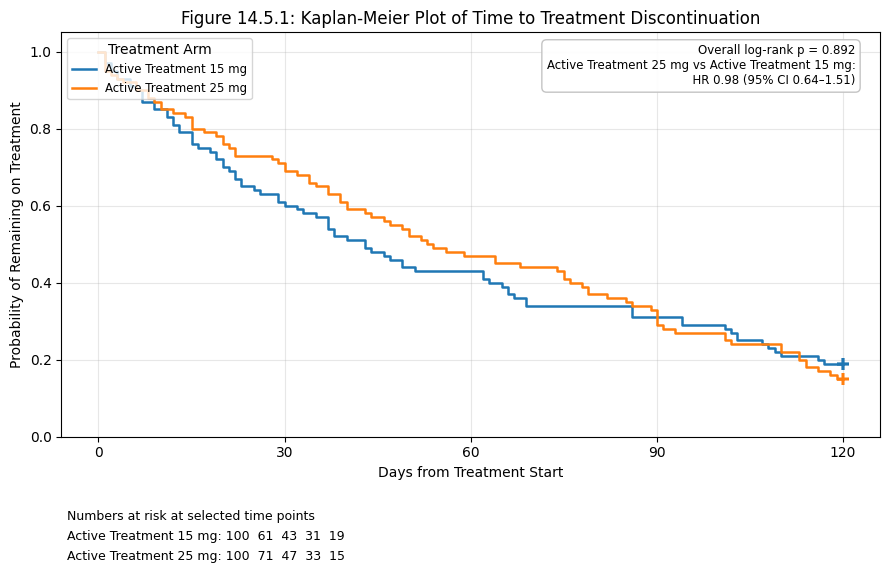

OK: figure_14_5_1_km.png


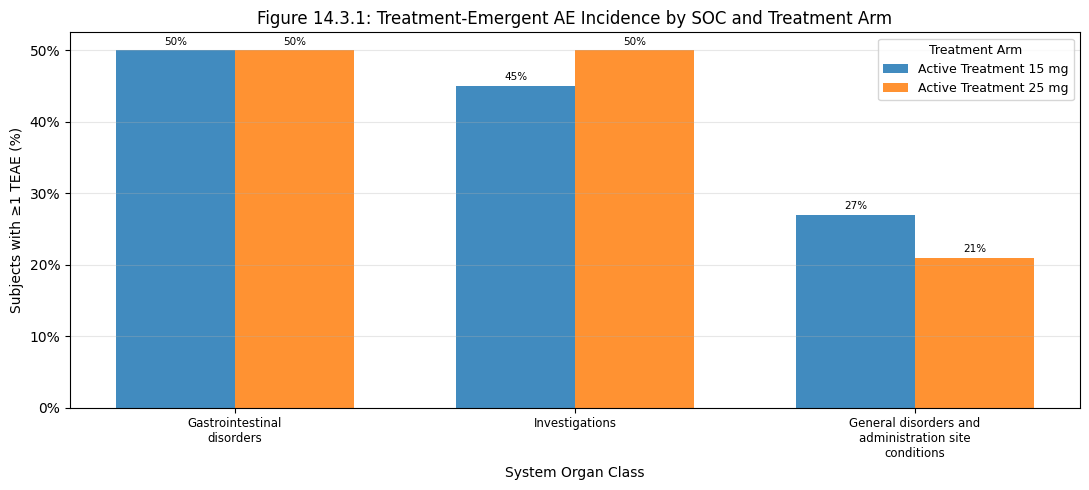

OK: figure_14_3_1_ae_incidence.png
OK: listing_16_1_1_subject_disposition.csv and listing_16_1_1_subject_disposition.html
  SAEs / Grade ≥3: 63 records, 53 subjects
OK: listing_16_2_1_sae_grade3plus.csv and listing_16_2_1_sae_grade3plus.html

FIGURES AND LISTINGS COMPLETE
Output: /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/tlf

Figures:
  figure_14_3_1_ae_incidence.png
  figure_14_5_1_km.png

Listings:
  listing_16_1_1_subject_disposition  (220 subjects)
  listing_16_2_1_sae_grade3plus       (63 records)


In [0]:
# =============================================================================
# CELL 15: Generate Figures and Listings
# =============================================================================
# Figures:
#   figure_14_3_1_ae_incidence.png  — TEAE incidence bar chart by SOC and arm
#   figure_14_5_1_km.png            — KM plot of time to treatment discontinuation
#
# Listings:
#   listing_16_1_1_subject_disposition.csv/.html  — individual subject enrolment
#   listing_16_2_1_sae_grade3plus.csv/.html       — SAEs and Grade ≥3 TEAEs
# =============================================================================

import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist
from pyspark.sql import functions as F

print("=" * 70)
print("GENERATE FIGURES AND LISTINGS")
print("=" * 70)

_SEED = globals().get("PSEUDO_RANDOM_SEED", 311)


# =============================================================================
# SECTION 1: Load ADTTE from adam_adtte (derived in ADaM Cell 13)
# =============================================================================
# ADTTE is no longer re-derived here. Cell 7 now owns the derivation and
# registers adam_adtte as a Spark temp view + adtte.csv export.
adtte = spark.table("adam_adtte").toPandas()
print(f"ADTTE (adam_adtte): {len(adtte)} records, "
      f"{adtte['CNSR'].eq(0).sum()} events, "
      f"{adtte['CNSR'].eq(1).sum()} censored")
print(adtte.groupby(["ARM", "CNSR"]).size().rename("n").reset_index().to_string(index=False))


# =============================================================================
# SECTION 2: KM statistical helpers
# =============================================================================

def _compute_km_points(arm_df):
    arm_df = arm_df.sort_values(["AVAL", "CNSR"]).reset_index(drop=True)
    n, s = len(arm_df), 1.0
    times, survivals = [0], [1.0]
    for tv in sorted(arm_df["AVAL"].dropna().unique()):
        d = int(((arm_df["AVAL"] == tv) & (arm_df["CNSR"] == 0)).sum())
        c = int(((arm_df["AVAL"] == tv) & (arm_df["CNSR"] == 1)).sum())
        if n > 0 and d > 0:
            s *= 1 - d / n
        times.append(tv)
        survivals.append(s)
        n -= (d + c)
    return pd.DataFrame({"time": times, "survival": survivals})


def _log_rank_test(group_data):
    all_evt = sorted({t for times, evts in group_data for t, e in zip(times, evts) if e == 1})
    k = len(group_data)
    O, E = [0.0] * k, [0.0] * k
    for t in all_evt:
        n_i = [sum(1 for tj in times if tj >= t) for times, _ in group_data]
        d_i = [sum(1 for tj, ej in zip(times, evts) if tj == t and ej == 1) for times, evts in group_data]
        N, D = sum(n_i), sum(d_i)
        if N > 0:
            for i in range(k):
                O[i] += d_i[i]
                E[i] += D * n_i[i] / N
    stat = sum((O[i] - E[i]) ** 2 / E[i] for i in range(k) if E[i] > 0)
    return stat, float(1 - chi2_dist.cdf(stat, df=k - 1))


def _mh_hr(t_trt, e_trt, t_ref, e_ref):
    all_evt = sorted({t for t, e in list(zip(t_trt, e_trt)) + list(zip(t_ref, e_ref)) if e == 1})
    U = V = 0.0
    for t in all_evt:
        n1 = sum(1 for tj in t_trt if tj >= t)
        n0 = sum(1 for tj in t_ref if tj >= t)
        d1 = sum(1 for tj, ej in zip(t_trt, e_trt) if tj == t and ej == 1)
        d0 = sum(1 for tj, ej in zip(t_ref, e_ref) if tj == t and ej == 1)
        N = n1 + n0
        if N > 0:
            U += d1 * n0 / N
            V += d0 * n1 / N
    if U <= 0 or V <= 0:
        return None, None, None
    hr = U / V
    se = math.sqrt(1 / U + 1 / V)
    return hr, math.exp(math.log(hr) - 1.96 * se), math.exp(math.log(hr) + 1.96 * se)


# =============================================================================
# FIGURE 14.5.1: KM plot of time to treatment discontinuation
# =============================================================================

def generate_figure_14_5_1(df):
    df = df.copy()
    df["EVENT"] = (df["CNSR"] == 0).astype(int)
    arm_order = list(df["ARM"].drop_duplicates())
    ref_arm = arm_order[0]

    groups = [
        (df.loc[df["ARM"] == a, "AVAL"].tolist(),
         df.loc[df["ARM"] == a, "EVENT"].tolist())
        for a in arm_order
    ]
    _, p_overall = _log_rank_test(groups)

    ref_t = df.loc[df["ARM"] == ref_arm, "AVAL"].tolist()
    ref_e = df.loc[df["ARM"] == ref_arm, "EVENT"].tolist()
    hr_results = {}
    for arm in arm_order:
        if arm == ref_arm:
            continue
        hr, ci_lo, ci_hi = _mh_hr(
            df.loc[df["ARM"] == arm, "AVAL"].tolist(),
            df.loc[df["ARM"] == arm, "EVENT"].tolist(),
            ref_t, ref_e,
        )
        hr_results[arm] = (hr, ci_lo, ci_hi)

    x_max = max(float(df["AVAL"].max()), 1.0)
    tick_values = sorted(set(
        [t for t in [0, 30, 60, 90, 120] if t <= x_max + 15]
        + [int(math.ceil(x_max / 30.0) * 30)]
    ))

    fig, ax = plt.subplots(figsize=(9, 5))
    risk_rows = []
    line_colors = {}
    for arm in arm_order:
        arm_df = df[df["ARM"] == arm].copy()
        km = _compute_km_points(arm_df)
        line, = ax.step(km["time"], km["survival"], where="post", label=arm, linewidth=1.8)
        line_colors[arm] = line.get_color()
        for _, row in arm_df[arm_df["CNSR"] == 1].iterrows():
            t_c = float(row["AVAL"])
            before = km[km["time"] <= t_c]
            s_c = before["survival"].iloc[-1] if not before.empty else 1.0
            ax.plot(t_c, s_c, "+", markersize=9, color=line_colors[arm], markeredgewidth=1.5)
        risk_rows.append(
            f"{arm}: " + "  ".join(str(int((arm_df["AVAL"] >= t).sum())) for t in tick_values)
        )

    p_str = "p < 0.001" if p_overall < 0.001 else f"p = {p_overall:.3f}"
    annot_lines = [f"Overall log-rank {p_str}"]
    for arm, (hr, ci_lo, ci_hi) in hr_results.items():
        if hr is not None:
            annot_lines.append(f"{arm} vs {ref_arm}:\n  HR {hr:.2f} (95% CI {ci_lo:.2f}\u2013{ci_hi:.2f})")
        else:
            annot_lines.append(f"{arm} vs {ref_arm}: HR not estimable")
    ax.text(
        0.97, 0.97, "\n".join(annot_lines),
        transform=ax.transAxes, fontsize=8.5, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.75", alpha=0.92),
    )

    ax.set_title("Figure 14.5.1: Kaplan-Meier Plot of Time to Treatment Discontinuation")
    ax.set_xlabel("Days from Treatment Start")
    ax.set_ylabel("Probability of Remaining on Treatment")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(tick_values)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Treatment Arm", loc="upper left", fontsize=8.5)
    plt.figtext(0.08, -0.05, "Numbers at risk at selected time points", ha="left", fontsize=9)
    for idx, row_text in enumerate(risk_rows):
        plt.figtext(0.08, -0.09 - idx * 0.04, row_text, ha="left", fontsize=9)
    plt.tight_layout()
    path = TLF_DIR / "figure_14_5_1_km.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_5_1 = generate_figure_14_5_1(adtte[adtte["PARAMCD"] == "TTDISC"].copy())


# =============================================================================
# FIGURE 14.3.1: TEAE incidence bar chart by SOC
# =============================================================================

def generate_figure_14_3_1(adae_spark, adsl_spark):
    adae_pdf = adae_spark.select("USUBJID", "TRT01A", "AEBODSYS", "TRTEMFL").toPandas()
    adae_pdf = adae_pdf[adae_pdf["TRTEMFL"] == "Y"].copy()
    adsl_pdf = adsl_spark.select("USUBJID", "TRT01A", "SAFFL").toPandas()
    adsl_pdf = adsl_pdf[adsl_pdf["SAFFL"] == "Y"].copy()

    denom = adsl_pdf.groupby("TRT01A")["USUBJID"].nunique()
    arms = sorted(denom.index.tolist())

    soc_subj = (
        adae_pdf.groupby(["TRT01A", "AEBODSYS"])["USUBJID"].nunique()
        .reset_index()
        .rename(columns={"USUBJID": "n"})
    )
    soc_subj["pct"] = soc_subj.apply(
        lambda r: 100.0 * r["n"] / denom.get(r["TRT01A"], 1), axis=1
    )
    top_socs = (
        soc_subj.groupby("AEBODSYS")["n"].sum()
        .sort_values(ascending=False)
        .head(5).index.tolist()
    )
    plot_df = soc_subj[soc_subj["AEBODSYS"].isin(top_socs)].copy()

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    x = np.arange(len(top_socs))
    bar_width = 0.7 / max(len(arms), 1)

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, arm in enumerate(arms):
        arm_df = plot_df[plot_df["TRT01A"] == arm].set_index("AEBODSYS")
        vals = [arm_df.loc[s, "pct"] if s in arm_df.index else 0.0 for s in top_socs]
        offset = (i - (len(arms) - 1) / 2.0) * bar_width
        bars = ax.bar(x + offset, vals, bar_width, label=arm, color=colors[i % len(colors)], alpha=0.85)
        for bar, v in zip(bars, vals):
            if v > 1:
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.0f}%",
                        ha="center", va="bottom", fontsize=7.5)

    wrapped_labels = ["\n".join(textwrap.wrap(s, 22)) for s in top_socs]
    ax.set_xticks(x)
    ax.set_xticklabels(wrapped_labels, fontsize=8.5, ha="center")
    ax.set_ylabel("Subjects with \u22651 TEAE (%)")
    ax.set_xlabel("System Organ Class")
    ax.set_title("Figure 14.3.1: Treatment-Emergent AE Incidence by SOC and Treatment Arm")
    ax.legend(title="Treatment Arm", fontsize=9, title_fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    plt.tight_layout()
    path = TLF_DIR / "figure_14_3_1_ae_incidence.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_3_1 = generate_figure_14_3_1(spark.table("adam_adae"), spark.table("adam_adsl"))


# =============================================================================
# LISTING 16.1.1: Individual subject disposition
# =============================================================================

def generate_listing_16_1_1(adsl_spark):
    want = ["USUBJID", "SITEID", "ARM", "ARMCD", "SAFFL", "ITTFL",
            "SEX", "AGE", "RFXSTDTC", "DTHDTC", "DTHFL"]
    cols = [c for c in want if c in adsl_spark.columns]
    pdf = (
        adsl_spark.select(*cols)
        .orderBy("ARMCD", "USUBJID")
        .toPandas()
        .fillna("")
    )
    pdf = pdf.rename(columns={
        "USUBJID": "Subject ID",
        "SITEID": "Site",
        "ARM": "Treatment Arm",
        "ARMCD": "Arm Code",
        "SAFFL": "SAF",
        "ITTFL": "ITT",
        "SEX": "Sex",
        "AGE": "Age",
        "RFXSTDTC": "First Dose Date",
        "DTHDTC": "Death Date",
        "DTHFL": "Death",
    })
    write_tlf(pdf, "listing_16_1_1_subject_disposition",
              "Listing 16.1.1: Individual Subject Disposition")
    return pdf


lst_16_1_1 = generate_listing_16_1_1(spark.table("adam_adsl"))


# =============================================================================
# LISTING 16.2.1: SAEs and Grade ≥3 TEAEs
# =============================================================================

def generate_listing_16_2_1(adae_spark):
    pdf = (
        adae_spark
        .filter(
            (F.col("TRTEMFL") == "Y")
            & ((F.col("AESER") == "Y") | (F.col("AETOXGRN") >= 3))
        )
        .select(
            "USUBJID", "TRT01A", "AEDECOD", "AEBODSYS",
            "AETOXGR", "AESER", "AEREL", "AEOUT", "AESTDTC", "AEENDTC",
        )
        .orderBy("TRT01A", "USUBJID", F.col("AESTDTC").asc_nulls_last())
        .toPandas()
        .fillna("")
    )
    pdf = pdf.rename(columns={
        "USUBJID": "Subject ID",
        "TRT01A": "Treatment Arm",
        "AEDECOD": "Preferred Term",
        "AEBODSYS": "System Organ Class",
        "AETOXGR": "Grade",
        "AESER": "Serious",
        "AEREL": "Relatedness",
        "AEOUT": "Outcome",
        "AESTDTC": "Start Date",
        "AEENDTC": "End Date",
    })
    print(f"  SAEs / Grade \u22653: {len(pdf)} records, {pdf['Subject ID'].nunique()} subjects")
    write_tlf(pdf, "listing_16_2_1_sae_grade3plus",
              "Listing 16.2.1: Serious and Grade 3 or Higher TEAEs")
    return pdf


lst_16_2_1 = generate_listing_16_2_1(spark.table("adam_adae"))


# =============================================================================
# Summary
# =============================================================================

print("")
print("=" * 70)
print("FIGURES AND LISTINGS COMPLETE")
print("=" * 70)
print(f"Output: {TLF_DIR}")
print("")
print("Figures:")
print("  figure_14_3_1_ae_incidence.png")
print("  figure_14_5_1_km.png")
print("")
print("Listings:")
print(f"  listing_16_1_1_subject_disposition  ({len(lst_16_1_1)} subjects)")
print(f"  listing_16_2_1_sae_grade3plus       ({len(lst_16_2_1)} records)")
print("=" * 70)

FIGURE 14.7.1: LABORATORY SHIFT PLOT
Shift pairs: 800 (4 tests, 200 subjects)


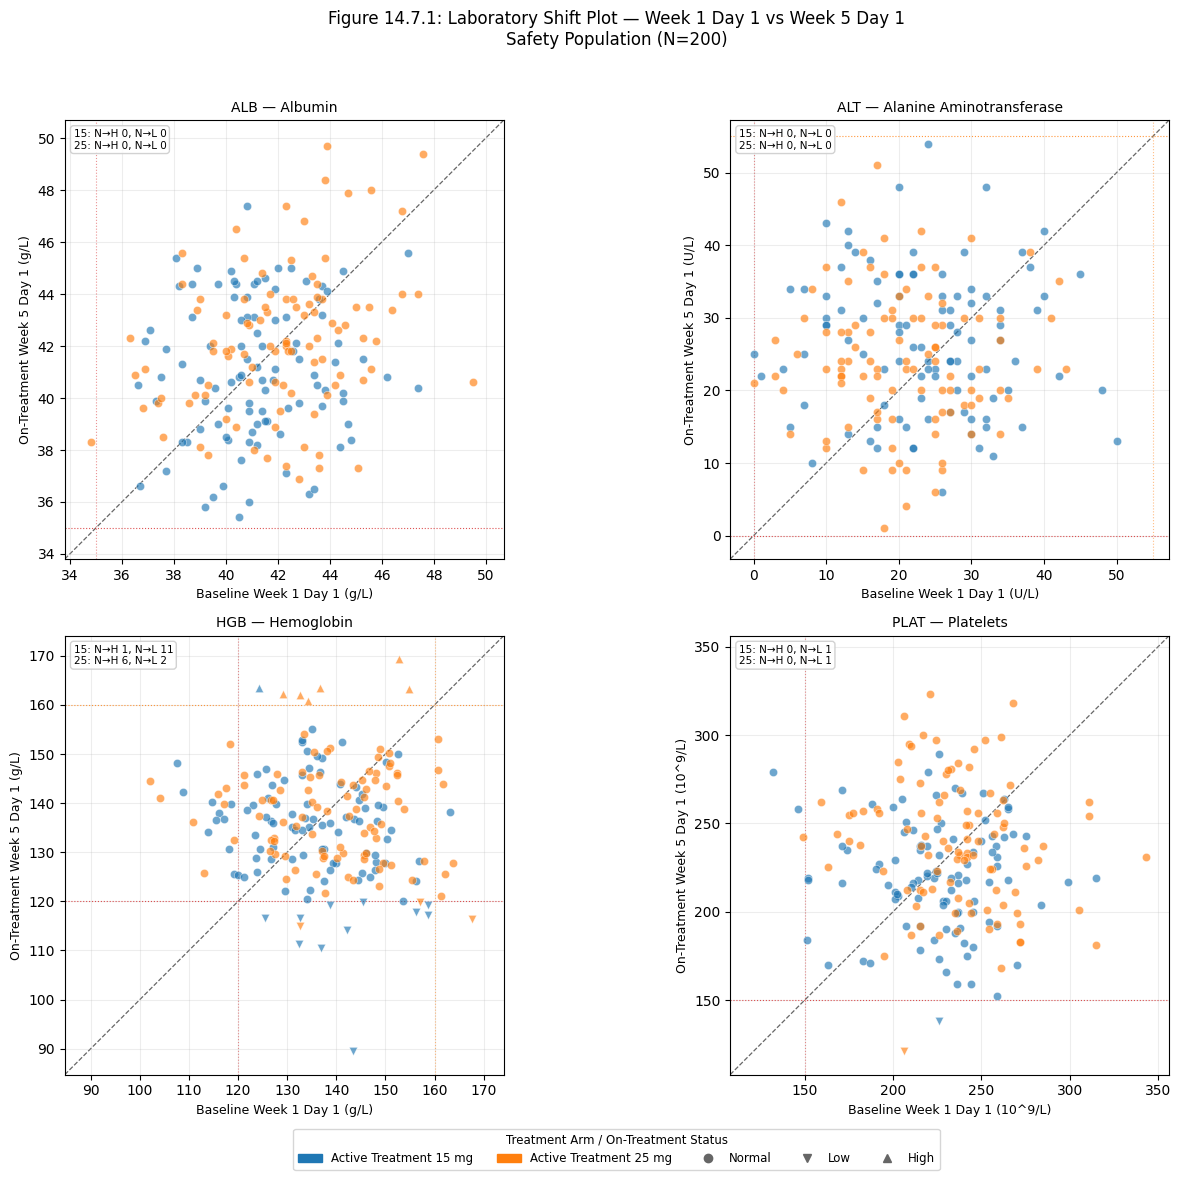

OK: figure_14_7_1_lab_shift.png  (313 KB)

Shift summary (Normal→High / Normal→Low):
  ALB: Normal→High=0, Normal→Low=0
  ALT: Normal→High=0, Normal→Low=0
  HGB: Normal→High=7, Normal→Low=13
  PLAT: Normal→High=0, Normal→Low=2


In [0]:
# =============================================================================
# CELL 16: Figure 14.7.1 — Laboratory Shift Plot
# =============================================================================
# Shows baseline (Week 1 Day 1) vs on-treatment (Week 5 Day 1) values for each
# lab parameter, coloured by treatment arm, with:
#   - Identity diagonal (no change line)
#   - Vertical / horizontal reference-range boundary lines
#   - Symbol coded by ANRIND at the on-treatment visit
#   - Quadrant counts (N↑, N↓, H, L) per arm per test
# =============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pyspark.sql import functions as F

print("=" * 70)
print("FIGURE 14.7.1: LABORATORY SHIFT PLOT")
print("=" * 70)

# Reference ranges (from pseudodata generator — used when ANRLO/ANRHI not in ADaM)
_REF_RANGES = {
    "ALB":  {"lo": 35.0,  "hi": 52.0},
    "ALT":  {"lo":  0.0,  "hi": 55.0},
    "HGB":  {"lo": 120.0, "hi": 160.0},
    "PLAT": {"lo": 150.0, "hi": 400.0},
}

BASELINE_VISIT    = "Week 1 Day 1"
ONTREATMENT_VISIT = "Week 5 Day 1"

_adlb = spark.table("adam_adlb").filter(F.col("SAFFL") == "Y").toPandas()

base_df = (
    _adlb[_adlb["VISIT"] == BASELINE_VISIT]
    [["USUBJID", "PARAMCD", "AVAL"]]
    .rename(columns={"AVAL": "BASE"})
)
post_df = (
    _adlb[_adlb["VISIT"] == ONTREATMENT_VISIT]
    [["USUBJID", "TRT01A", "PARAMCD", "PARAM", "AVAL", "LBSTRESU", "ANRIND"]]
    .rename(columns={"AVAL": "POST"})
)
shift_df = post_df.merge(base_df, on=["USUBJID", "PARAMCD"], how="inner")
print(f"Shift pairs: {len(shift_df)} ({shift_df['PARAMCD'].nunique()} tests, {shift_df['USUBJID'].nunique()} subjects)")

paramcds = ["ALB", "ALT", "HGB", "PLAT"]
paramcds = [p for p in paramcds if p in shift_df["PARAMCD"].unique()]
ntest = len(paramcds)
ncols = 2
nrows = math.ceil(ntest / ncols)

arms = sorted(shift_df["TRT01A"].dropna().unique())
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
arm_color = {arm: palette[i % len(palette)] for i, arm in enumerate(arms)}

# ANRIND → marker shape
anrind_marker = {"NORMAL": "o", "LOW": "v", "HIGH": "^", None: "o", "": "o"}

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)

for idx, pcd in enumerate(paramcds):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]

    tdf = shift_df[shift_df["PARAMCD"] == pcd].copy()
    tdf["ANRIND"] = tdf["ANRIND"].fillna("NORMAL").replace("", "NORMAL")
    param_name = tdf["PARAM"].iloc[0] if not tdf.empty else pcd
    unit       = tdf["LBSTRESU"].iloc[0] if not tdf.empty else ""

    ref_lo = _REF_RANGES.get(pcd, {}).get("lo")
    ref_hi = _REF_RANGES.get(pcd, {}).get("hi")

    # ── scatter by arm × ANRIND ───────────────────────────────────────────────
    for arm in arms:
        arm_df = tdf[tdf["TRT01A"] == arm]
        for nrind, marker in anrind_marker.items():
            if nrind is None:
                continue
            sub = arm_df[arm_df["ANRIND"] == nrind]
            if sub.empty:
                continue
            ax.scatter(
                sub["BASE"], sub["POST"],
                color=arm_color[arm], marker=marker,
                alpha=0.65, s=35, linewidths=0.4, edgecolors="white",
                zorder=3,
            )

    # ── identity line ─────────────────────────────────────────────────────────
    all_vals = pd.concat([tdf["BASE"], tdf["POST"]]).dropna()
    if not all_vals.empty:
        v_min = all_vals.min()
        v_max = all_vals.max()
        pad   = max((v_max - v_min) * 0.06, 1.0)
        ax_lo = v_min - pad
        ax_hi = v_max + pad
        ax.plot([ax_lo, ax_hi], [ax_lo, ax_hi], color="0.4", lw=0.9,
                ls="--", zorder=1, label="No change")
        ax.set_xlim(ax_lo, ax_hi)
        ax.set_ylim(ax_lo, ax_hi)

    # ── reference range boundary lines ────────────────────────────────────────
    if ref_lo is not None:
        ax.axhline(ref_lo, color="#d62728", lw=0.8, ls=":", alpha=0.8,
                   label=f"Ref Lo ({ref_lo:.0f})")
        ax.axvline(ref_lo, color="#d62728", lw=0.8, ls=":", alpha=0.5)
    if ref_hi is not None:
        ax.axhline(ref_hi, color="#ff7f0e", lw=0.8, ls=":", alpha=0.8,
                   label=f"Ref Hi ({ref_hi:.0f})")
        ax.axvline(ref_hi, color="#ff7f0e", lw=0.8, ls=":", alpha=0.5)

    # ── quadrant shift counts ──────────────────────────────────────────────────
    if ref_lo is not None and ref_hi is not None:
        # NL→H  top-right of ref-hi: base normal, post high
        # NL→L  bottom-left of ref-lo: base normal, post low
        def _q(arm_label):
            s = tdf[tdf["TRT01A"] == arm_label]
            n2h = ((s["BASE"].between(ref_lo, ref_hi)) & (s["POST"] > ref_hi)).sum()
            n2l = ((s["BASE"].between(ref_lo, ref_hi)) & (s["POST"] < ref_lo)).sum()
            return int(n2h), int(n2l)
        ann_lines = []
        for arm in arms:
            n2h, n2l = _q(arm)
            short = arm.split()[2] if len(arm.split()) >= 3 else arm
            ann_lines.append(f"{short}: N→H {n2h}, N→L {n2l}")
        ax.text(0.02, 0.98, "\n".join(ann_lines),
                transform=ax.transAxes, fontsize=7.5, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="0.8", alpha=0.88))

    ax.set_xlabel(f"Baseline {BASELINE_VISIT} ({unit})", fontsize=9)
    ax.set_ylabel(f"On-Treatment {ONTREATMENT_VISIT} ({unit})", fontsize=9)
    ax.set_title(f"{pcd} — {param_name}", fontsize=10)
    ax.grid(True, alpha=0.22)
    ax.set_aspect("equal", adjustable="box")

# ── figure-level legend ───────────────────────────────────────────────────────
arm_handles  = [mpatches.Patch(color=arm_color[a], label=a) for a in arms]
nrind_handles = [
    mlines.Line2D([], [], marker="o", color="0.4", ls="none", ms=6, label="Normal"),
    mlines.Line2D([], [], marker="v", color="0.4", ls="none", ms=6, label="Low"),
    mlines.Line2D([], [], marker="^", color="0.4", ls="none", ms=6, label="High"),
]
fig.legend(
    handles=arm_handles + nrind_handles,
    title="Treatment Arm / On-Treatment Status",
    loc="lower center", ncol=len(arms) + 3,
    fontsize=8.5, title_fontsize=8.5,
    bbox_to_anchor=(0.5, -0.04),
)

# Hide unused subplots
for idx in range(ntest, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

fig.suptitle(
    f"Figure 14.7.1: Laboratory Shift Plot — {BASELINE_VISIT} vs {ONTREATMENT_VISIT}\n"
    f"Safety Population (N={shift_df['USUBJID'].nunique()})",
    fontsize=12, y=1.02,
)
plt.tight_layout()

_path = TLF_DIR / "figure_14_7_1_lab_shift.png"
plt.savefig(str(_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"OK: {_path.name}  ({_path.stat().st_size // 1024} KB)")

# Summary of shifts
print("")
print("Shift summary (Normal→High / Normal→Low):")
for pcd in paramcds:
    lo = _REF_RANGES.get(pcd, {}).get("lo")
    hi = _REF_RANGES.get(pcd, {}).get("hi")
    if lo is None or hi is None:
        continue
    tdf = shift_df[shift_df["PARAMCD"] == pcd]
    n2h = ((tdf["BASE"].between(lo, hi)) & (tdf["POST"] > hi)).sum()
    n2l = ((tdf["BASE"].between(lo, hi)) & (tdf["POST"] < lo)).sum()
    print(f"  {pcd}: Normal→High={int(n2h)}, Normal→Low={int(n2l)}")

ADDITIONAL FIGURES: 14.5.2 / 14.6.1 / 14.6.2 / 14.7.2 / 14.8.1
Tumour data : 200 subjects from adam_adtr/adam_adrs (CR=0, PR=95, SD=75, PD=30)


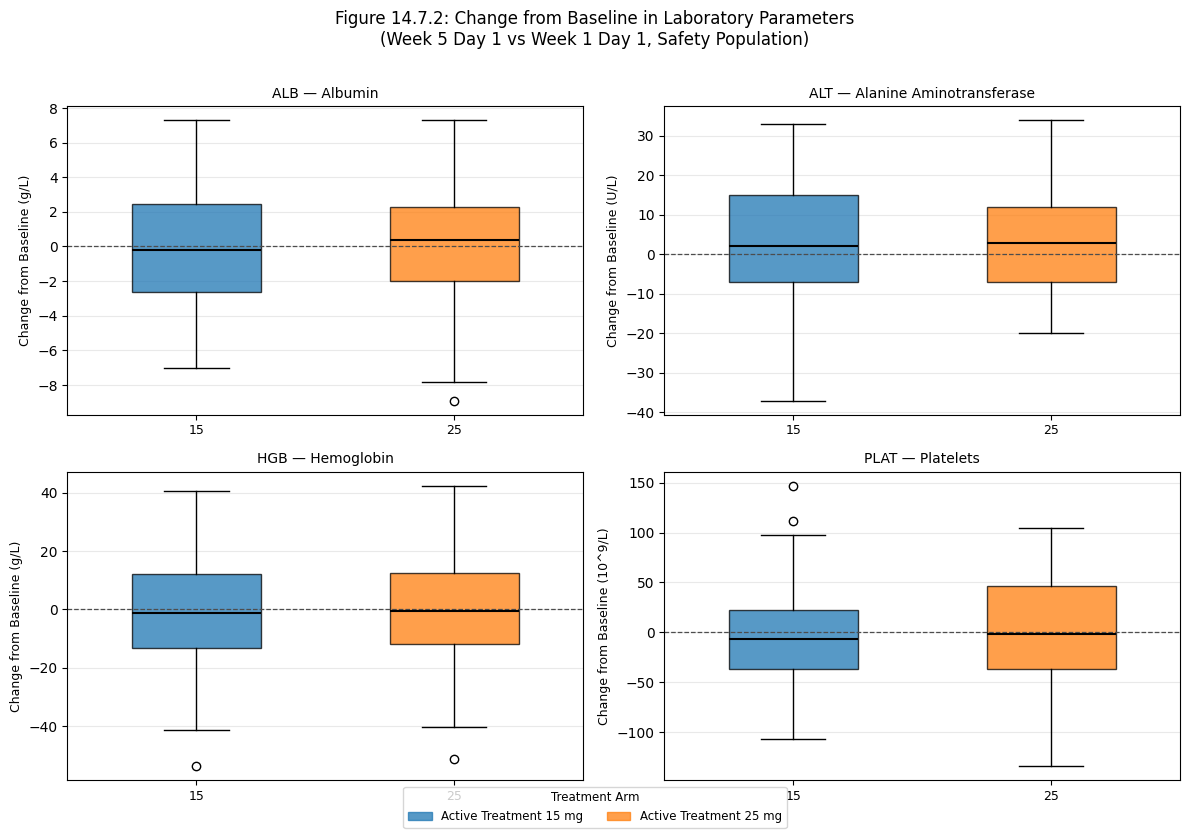

OK: figure_14_7_2_lab_cfb_boxplot.png


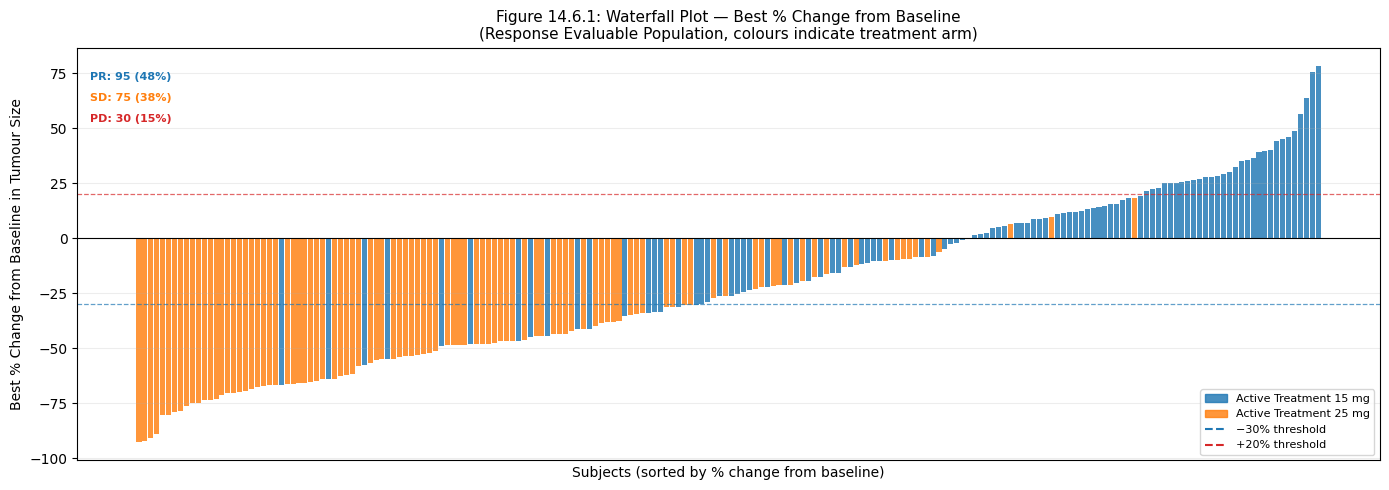

OK: figure_14_6_1_waterfall.png


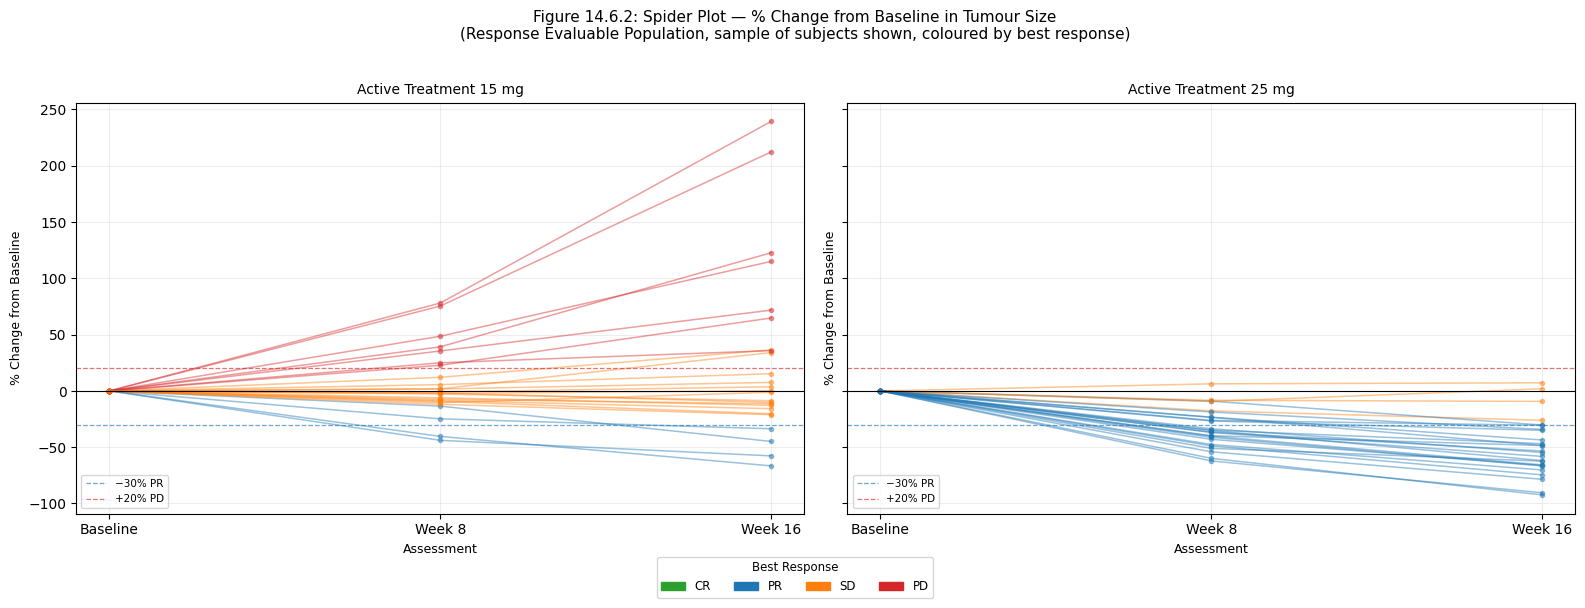

OK: figure_14_6_2_spider.png


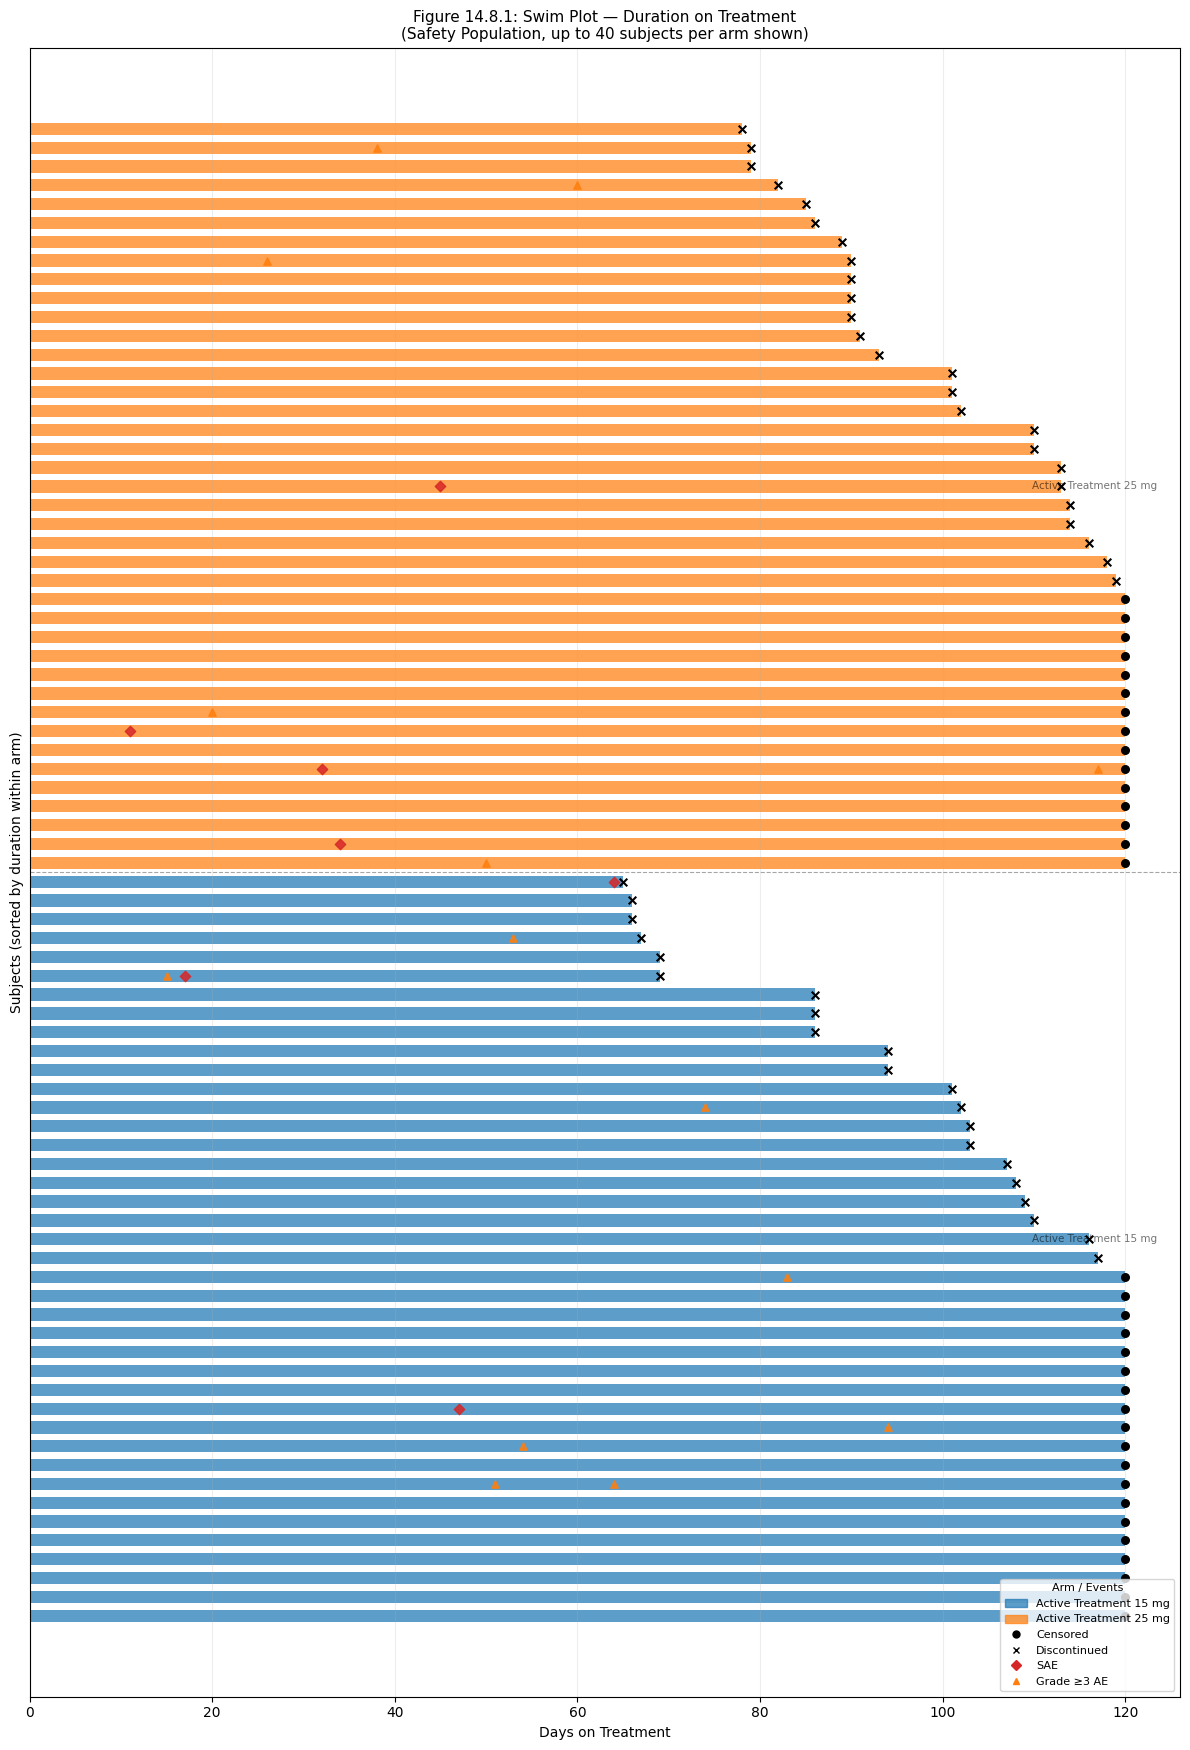

OK: figure_14_8_1_swim.png


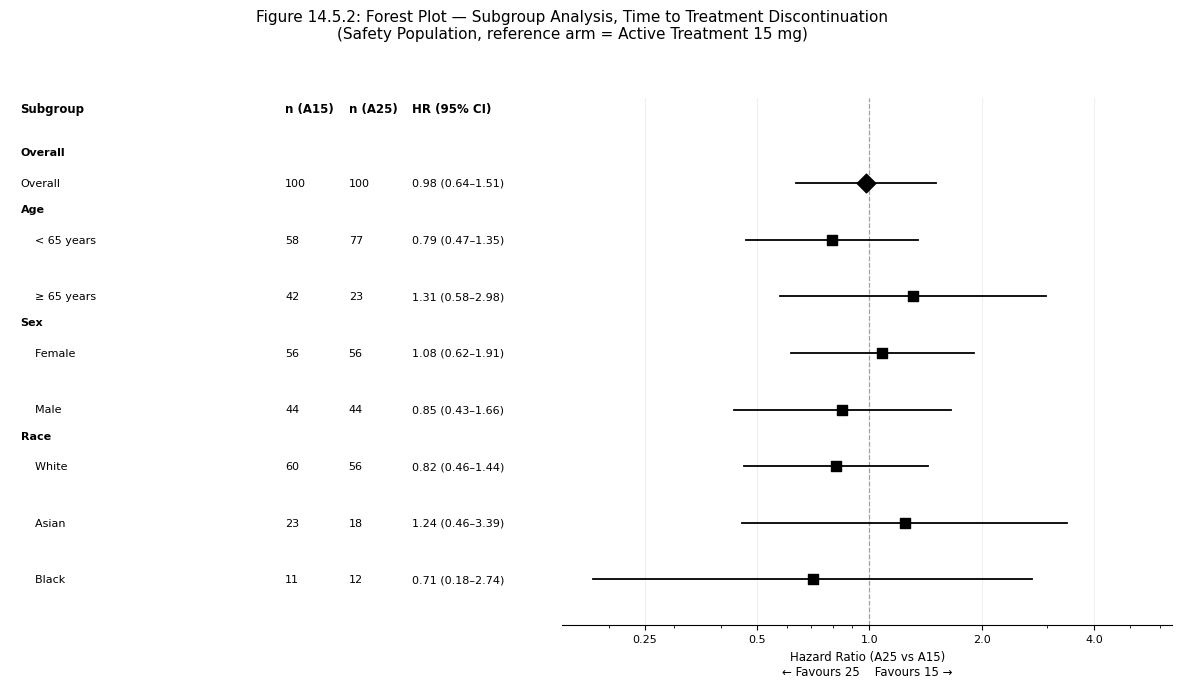

OK: figure_14_5_2_forest.png

ADDITIONAL FIGURES COMPLETE
  figure_14_5_2_forest.png                      100 KB
  figure_14_6_1_waterfall.png                   83 KB
  figure_14_6_2_spider.png                      219 KB
  figure_14_7_2_lab_cfb_boxplot.png             110 KB
  figure_14_8_1_swim.png                        131 KB


In [0]:
# =============================================================================
# CELL 17: Additional Oncology Figures (14.5.2, 14.6.1, 14.6.2, 14.7.2, 14.8.1)
# =============================================================================
# 14.5.2  Forest plot  — subgroup HR analysis (time to discontinuation)
# 14.6.1  Waterfall    — best % change from baseline in tumour size
# 14.6.2  Spider plot  — individual % change trajectories over time
# 14.7.2  Box plot     — change from baseline in lab parameters by arm
# 14.8.1  Swim plot    — treatment duration with SAE / Grade ≥3 event markers
# =============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pyspark.sql import functions as F

print("=" * 70)
print("ADDITIONAL FIGURES: 14.5.2 / 14.6.1 / 14.6.2 / 14.7.2 / 14.8.1")
print("=" * 70)

_SEED  = globals().get("PSEUDO_RANDOM_SEED", 311)
_pal   = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ---------------------------------------------------------------------------
# Shared data pulls (once, reused across figures)
# ---------------------------------------------------------------------------
_adsl = (
    spark.table("adam_adsl")
    .select("USUBJID", "ARMCD", "ARM", "TRT01A", "AGE", "SEX", "RACE", "RFXSTDTC", "DTHFL", "SAFFL")
    .toPandas()
)
_adsl_saf = _adsl[_adsl["SAFFL"] == "Y"].copy().reset_index(drop=True)
_adsl_saf["AGE"] = pd.to_numeric(_adsl_saf["AGE"], errors="coerce")
_adsl_saf["AGE_GRP"] = _adsl_saf["AGE"].apply(
    lambda a: "< 65 years" if pd.notna(a) and a < 65 else "\u2265 65 years"
)

_adlb = spark.table("adam_adlb").filter(F.col("SAFFL") == "Y").toPandas()
_adae_raw = (
    spark.table("adam_adae")
    .select("USUBJID", "TRT01A", "AESER", "AETOXGRN", "TRTEMFL", "AESTDTC")
    .toPandas()
)
_tte = adtte[adtte["PARAMCD"] == "TTDISC"].copy()  # from Cell 9A

arms     = sorted(_adsl_saf["ARMCD"].dropna().unique())
arm_name = {row["ARMCD"]: row["TRT01A"] for _, row in _adsl_saf.iterrows()}
arm_col  = {arm: _pal[i % len(_pal)] for i, arm in enumerate(arms)}
ref_arm  = arms[0]   # A15
trt_arm  = arms[1]   # A25


# ---------------------------------------------------------------------------
# Tumour response data from adam_adrs / adam_adtr  (real longitudinal data)
# ---------------------------------------------------------------------------
_adrs = spark.table("adam_adrs").toPandas()
_adtr = spark.table("adam_adtr").toPandas()

# Best PCHG per subject from post-baseline ADTR records
_adtr_best = (
    _adtr[_adtr["ABLFL"] != "Y"][["USUBJID", "PCHG"]]
    .groupby("USUBJID")["PCHG"]
    .min().reset_index()
    .rename(columns={"PCHG": "PCHG_BEST"})
)
# Response category from ADRS
_adrs_resp = (
    _adrs[_adrs["PARAMCD"] == "BESTRESP"][["USUBJID", "AVALC"]]
    .rename(columns={"AVALC": "RESPONSE"})
)
_tumor = (
    _adsl_saf[["USUBJID", "ARMCD", "TRT01A"]]
    .merge(_adtr_best, on="USUBJID", how="inner")
    .merge(_adrs_resp, on="USUBJID", how="left")
    .rename(columns={"PCHG_BEST": "PCHG"})
    .assign(RESPONSE=lambda d: d["RESPONSE"].fillna("SD"))
)
print(f"Tumour data : {len(_tumor)} subjects from adam_adtr/adam_adrs "
      f"(CR={(_tumor['RESPONSE']=='CR').sum()}, "
      f"PR={(_tumor['RESPONSE']=='PR').sum()}, "
      f"SD={(_tumor['RESPONSE']=='SD').sum()}, "
      f"PD={(_tumor['RESPONSE']=='PD').sum()})")

resp_col = {"CR": "#2ca02c", "PR": "#1f77b4", "SD": "#ff7f0e", "PD": "#d62728"}


# ===========================================================================
# FIGURE 14.7.2 — Change from Baseline Box Plot
# ===========================================================================
def _fig_14_7_2(adlb):
    base = (adlb[adlb["VISIT"] == "Week 1 Day 1"]
            [["USUBJID", "PARAMCD", "AVAL"]].rename(columns={"AVAL": "BASE"}))
    post = adlb[adlb["VISIT"] == "Week 5 Day 1"].copy()
    merged = post.merge(base, on=["USUBJID", "PARAMCD"], how="inner")
    merged["CHG"] = merged["AVAL"] - merged["BASE"]

    pcds = [p for p in ["ALB", "ALT", "HGB", "PLAT"] if p in merged["PARAMCD"].unique()]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
    flat = axes.flatten()

    for idx, pcd in enumerate(pcds):
        ax = flat[idx]
        tdf = merged[merged["PARAMCD"] == pcd]
        unit = tdf["LBSTRESU"].iloc[0] if not tdf.empty else ""
        data  = [tdf[tdf["TRT01A"] == arm_name[a]]["CHG"].dropna().values for a in arms]
        bp = ax.boxplot(data, positions=list(range(len(arms))), widths=0.5,
                        patch_artist=True, notch=False,
                        medianprops=dict(color="black", linewidth=1.5),
                        whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1))
        for patch, arm in zip(bp["boxes"], arms):
            patch.set_facecolor(arm_col[arm])
            patch.set_alpha(0.75)
        ax.axhline(0, color="0.3", lw=0.9, ls="--")
        ax.set_xticks(range(len(arms)))
        ax.set_xticklabels([arm_name[a].split()[2] for a in arms], fontsize=9)
        ax.set_ylabel(f"Change from Baseline ({unit})", fontsize=9)
        ax.set_title(f"{pcd} — {tdf['PARAM'].iloc[0] if not tdf.empty else pcd}", fontsize=10)
        ax.grid(axis="y", alpha=0.28)

    for idx in range(len(pcds), 4):
        flat[idx].set_visible(False)

    handles = [mpatches.Patch(color=arm_col[a], alpha=0.75, label=arm_name[a]) for a in arms]
    fig.legend(handles=handles, title="Treatment Arm", loc="lower center", ncol=len(arms),
               fontsize=8.5, title_fontsize=8.5, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(
        "Figure 14.7.2: Change from Baseline in Laboratory Parameters\n"
        "(Week 5 Day 1 vs Week 1 Day 1, Safety Population)",
        fontsize=12, y=1.01)
    plt.tight_layout()
    path = TLF_DIR / "figure_14_7_2_lab_cfb_boxplot.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_7_2 = _fig_14_7_2(_adlb)


# ===========================================================================
# FIGURE 14.6.1 — Waterfall Plot
# ===========================================================================
def _fig_14_6_1(tumor):
    plot = tumor.sort_values("PCHG").reset_index(drop=True)
    colors = [arm_col[r] for r in plot["ARMCD"]]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(len(plot)), plot["PCHG"], color=colors, width=0.85, alpha=0.82)
    ax.axhline(0,   color="black", lw=0.8)
    ax.axhline(-30, color="#1f77b4", lw=0.9, ls="--", alpha=0.7, label="−30% (PR threshold)")
    ax.axhline( 20, color="#d62728", lw=0.9, ls="--", alpha=0.7, label="+20% (PD threshold)")

    # Response proportion labels
    for resp, label in [("CR", "CR"), ("PR", "PR"), ("SD", "SD"), ("PD", "PD")]:
        n = (plot["RESPONSE"] == resp).sum()
        if n:
            pct = 100 * n / len(plot)
            ax.text(0.01, 0.99 - {"CR": 0, "PR": 0.05, "SD": 0.10, "PD": 0.15}[resp],
                    f"{label}: {n} ({pct:.0f}%)", transform=ax.transAxes,
                    fontsize=8, va="top", ha="left",
                    color=resp_col[resp], fontweight="bold")

    arm_handles = [mpatches.Patch(color=arm_col[a], alpha=0.82, label=arm_name[a]) for a in arms]
    ax.legend(handles=arm_handles + [
        mlines.Line2D([], [], color="#1f77b4", ls="--", label="−30% threshold"),
        mlines.Line2D([], [], color="#d62728", ls="--", label="+20% threshold"),
    ], fontsize=8, loc="lower right")

    ax.set_xticks([])
    ax.set_xlabel("Subjects (sorted by % change from baseline)", fontsize=10)
    ax.set_ylabel("Best % Change from Baseline in Tumour Size", fontsize=10)
    ax.set_title(
        "Figure 14.6.1: Waterfall Plot — Best % Change from Baseline\n"
        "(Response Evaluable Population, colours indicate treatment arm)",
        fontsize=11)
    ax.grid(axis="y", alpha=0.22)
    plt.tight_layout()
    path = TLF_DIR / "figure_14_6_1_waterfall.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_6_1 = _fig_14_6_1(_tumor)


# ===========================================================================
# FIGURE 14.6.2 — Spider Plot
# ===========================================================================
def _fig_14_6_2(tumor, adtr=None):
    _visit_wk = {1: 0, 2: 8, 3: 16}
    rng_s = np.random.default_rng(_SEED + 110)  # always needed for subject sampling

    if adtr is not None and not adtr.empty and "AVISITN" in adtr.columns:
        # Real longitudinal data from adam_adtr — 3 visits per subject
        long_df = (
            adtr[adtr["AVISITN"].isin([1, 2, 3])]
            .merge(_adsl_saf[["USUBJID", "ARMCD"]], on="USUBJID", how="left")
            .merge(tumor[["USUBJID", "RESPONSE"]], on="USUBJID", how="left")
            .assign(
                WEEK=lambda d: d["AVISITN"].map(_visit_wk),
                PCHG=lambda d: pd.to_numeric(d["PCHG"], errors="coerce").fillna(0.0),
                RESPONSE=lambda d: d["RESPONSE"].fillna("SD"),
            )
            [["USUBJID", "ARMCD", "TRT01A", "RESPONSE", "WEEK", "PCHG"]]
        )
    else:
        # Synthetic fallback (used if adam_adtr is unavailable)
        rows = []
        for _, row in tumor.iterrows():
            pf = row["PCHG"]
            interim = float(np.clip(rng_s.normal(pf * 0.45, max(abs(pf) * 0.25, 4)), -100, 100))
            for wk, pc in [(0, 0.0), (8, interim), (16, pf)]:
                rows.append({"USUBJID": row["USUBJID"], "ARMCD": row["ARMCD"],
                             "TRT01A": row["TRT01A"], "RESPONSE": row["RESPONSE"],
                             "WEEK": wk, "PCHG": pc})
        long_df = pd.DataFrame(rows)

    # Sample 25 per arm
    sample_subj = []
    for arm in arms:
        pool = tumor[tumor["ARMCD"] == arm]["USUBJID"].tolist()
        n    = min(25, len(pool))
        sample_subj += rng_s.choice(pool, n, replace=False).tolist()

    fig, axes = plt.subplots(1, len(arms), figsize=(8 * len(arms), 5.5), sharey=True)
    if len(arms) == 1:
        axes = [axes]

    for ax, arm in zip(axes, arms):
        sub = long_df[
            long_df["ARMCD"].eq(arm) & long_df["USUBJID"].isin(sample_subj)
        ]
        for subj, grp in sub.groupby("USUBJID"):
            resp  = grp["RESPONSE"].iloc[0]
            grp_s = grp.sort_values("WEEK")
            ax.plot(grp_s["WEEK"], grp_s["PCHG"],
                    color=resp_col.get(resp, "gray"), alpha=0.45, lw=1.1,
                    marker="o", markersize=3)
        ax.axhline(0,   color="black", lw=0.8)
        ax.axhline(-30, color="#1f77b4", lw=0.9, ls="--", alpha=0.65, label="−30% PR")
        ax.axhline( 20, color="#d62728", lw=0.9, ls="--", alpha=0.65, label="+20% PD")
        ax.set_xticks([0, 8, 16])
        ax.set_xticklabels(["Baseline", "Week 8", "Week 16"])
        ax.set_xlabel("Assessment", fontsize=9)
        ax.set_ylabel("% Change from Baseline", fontsize=9)
        ax.set_title(arm_name[arm], fontsize=10)
        ax.legend(fontsize=7.5, loc="lower left")
        ax.grid(True, alpha=0.22)

    resp_handles = [mpatches.Patch(color=resp_col[r], label=r)
                    for r in ["CR", "PR", "SD", "PD"]]
    fig.legend(handles=resp_handles, title="Best Response", loc="lower center",
               ncol=4, fontsize=8.5, title_fontsize=8.5, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(
        "Figure 14.6.2: Spider Plot — % Change from Baseline in Tumour Size\n"
        "(Response Evaluable Population, sample of subjects shown, coloured by best response)",
        fontsize=11, y=1.02)
    plt.tight_layout()
    path = TLF_DIR / "figure_14_6_2_spider.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_6_2 = _fig_14_6_2(_tumor, adtr=_adtr)


# ===========================================================================
# FIGURE 14.8.1 — Swim Plot
# ===========================================================================
def _fig_14_8_1(adsl, tte, adae):
    swim = (
        adsl.merge(
            tte[["USUBJID", "AVAL", "CNSR"]], on="USUBJID", how="left")
        .assign(AVAL=lambda d: pd.to_numeric(d["AVAL"], errors="coerce").fillna(0))
    )
    # Sample up to 40 per arm, sorted by duration descending
    parts = []
    for arm in arms:
        chunk = (
            swim[swim["ARMCD"] == arm]
            .sort_values("AVAL", ascending=False)
            .head(40)
        )
        parts.append(chunk)
    plot = pd.concat(parts).reset_index(drop=True)
    subj_y = {row["USUBJID"]: y for y, (_, row) in enumerate(plot.iterrows())}
    n_rows = len(plot)

    fig, ax = plt.subplots(figsize=(12, max(7, n_rows * 0.22)))

    for y, (_, row) in enumerate(plot.iterrows()):
        c = arm_col.get(row["ARMCD"], "gray")
        ax.barh(y, row["AVAL"], height=0.65, color=c, alpha=0.72, left=0)
        mk = "o" if row["CNSR"] == 1 else "x"
        ax.scatter(row["AVAL"], y, color="black", marker=mk, zorder=5, s=30)

    # SAE and Grade>=3 event markers
    rfx = adsl[["USUBJID", "RFXSTDTC"]].copy()
    ev = (
        adae[(adae["TRTEMFL"] == "Y")
             & ((adae["AESER"] == "Y") | (pd.to_numeric(adae["AETOXGRN"], errors="coerce") >= 3))]
        .merge(rfx, on="USUBJID", how="left")
        .dropna(subset=["RFXSTDTC", "AESTDTC"])
        .copy()
    )
    ev["AE_DAY"] = (
        pd.to_datetime(ev["AESTDTC"], errors="coerce")
        - pd.to_datetime(ev["RFXSTDTC"], errors="coerce")
    ).dt.days + 1
    ev = ev.dropna(subset=["AE_DAY"])
    for _, ev_row in ev.iterrows():
        y = subj_y.get(ev_row["USUBJID"])
        if y is None:
            continue
        max_dur = plot.loc[plot["USUBJID"] == ev_row["USUBJID"], "AVAL"]
        if max_dur.empty or ev_row["AE_DAY"] > float(max_dur.iloc[0]) + 5:
            continue
        mk2 = "D" if ev_row["AESER"] == "Y" else "^"
        c2  = "#d62728" if ev_row["AESER"] == "Y" else "#ff7f0e"
        ax.scatter(ev_row["AE_DAY"], y, color=c2, marker=mk2, zorder=6, s=28, alpha=0.85)

    # Arm separator
    n1 = len(plot[plot["ARMCD"] == arms[0]])
    if n1 < n_rows:
        ax.axhline(n1 - 0.5, color="black", lw=0.8, ls="--", alpha=0.35)
    ax.text(ax.get_xlim()[1] * 0.98, n1 * 0.5, arm_name.get(arms[0], arms[0]),
            ha="right", va="center", fontsize=7.5, alpha=0.55)
    ax.text(ax.get_xlim()[1] * 0.98, n1 + (n_rows - n1) * 0.5, arm_name.get(arms[1], arms[1]),
            ha="right", va="center", fontsize=7.5, alpha=0.55)

    ax.set_yticks([])
    ax.set_xlabel("Days on Treatment", fontsize=10)
    ax.set_ylabel("Subjects (sorted by duration within arm)", fontsize=10)
    ax.set_title(
        "Figure 14.8.1: Swim Plot — Duration on Treatment\n"
        "(Safety Population, up to 40 subjects per arm shown)",
        fontsize=11)
    ax.grid(axis="x", alpha=0.22)

    leg = (
        [mpatches.Patch(color=arm_col[a], alpha=0.72, label=arm_name[a]) for a in arms]
        + [
            mlines.Line2D([], [], marker="o", color="black", ls="none", ms=5, label="Censored"),
            mlines.Line2D([], [], marker="x", color="black", ls="none", ms=5, label="Discontinued"),
            mlines.Line2D([], [], marker="D", color="#d62728", ls="none", ms=5, label="SAE"),
            mlines.Line2D([], [], marker="^", color="#ff7f0e", ls="none", ms=5, label="Grade ≥3 AE"),
        ]
    )
    ax.legend(handles=leg, fontsize=8, title="Arm / Events", title_fontsize=8, loc="lower right")
    plt.tight_layout()
    path = TLF_DIR / "figure_14_8_1_swim.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_8_1 = _fig_14_8_1(_adsl_saf, _tte, _adae_raw)


# ===========================================================================
# FIGURE 14.5.2 — Forest Plot (subgroup HR)
# ===========================================================================
def _fig_14_5_2(adsl, tte):
    merged = adsl.merge(tte[["USUBJID", "AVAL", "CNSR"]], on="USUBJID", how="inner")

    subgroups = [
        ("Overall",   "Overall",          None,      None),
        ("Age",       "< 65 years",        "AGE_GRP", "< 65 years"),
        ("Age",       "\u2265 65 years",   "AGE_GRP", "\u2265 65 years"),
        ("Sex",       "Female",            "SEX",     "F"),
        ("Sex",       "Male",              "SEX",     "M"),
        ("Race",      "White",             "RACE",    "WHITE"),
        ("Race",      "Asian",             "RACE",    "ASIAN"),
        ("Race",      "Black",             "RACE",    "BLACK OR AFRICAN AMERICAN"),
    ]

    rows = []
    for cat, lbl, col, val in subgroups:
        sub = merged if col is None else merged[merged[col] == val]
        r = sub[sub["ARMCD"] == ref_arm]
        t = sub[sub["ARMCD"] == trt_arm]
        hr = ci_lo = ci_hi = None
        if len(r) >= 3 and len(t) >= 3:
            e_r = (r["CNSR"] == 0).astype(int).tolist()
            e_t = (t["CNSR"] == 0).astype(int).tolist()
            if sum(e_t) >= 1 and sum(e_r) >= 1:
                hr, ci_lo, ci_hi = _mh_hr(
                    t["AVAL"].tolist(), e_t, r["AVAL"].tolist(), e_r
                )
        rows.append({"cat": cat, "lbl": lbl, "nr": len(r), "nt": len(t),
                     "hr": hr, "lo": ci_lo, "hi": ci_hi})

    res = pd.DataFrame(rows)
    n   = len(res)
    yp  = list(range(n - 1, -1, -1))

    fig = plt.figure(figsize=(15, n * 0.58 + 2.2))
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(1, 2, figure=fig, width_ratios=[2.6, 3], wspace=0.04)
    ax_t = fig.add_subplot(gs[0])
    ax_f = fig.add_subplot(gs[1])

    # ── left text panel ──
    ax_t.set_xlim(0, 100)
    ax_t.set_ylim(-0.8, n + 0.5)
    ax_t.axis("off")

    # header row
    for x, hdr in zip([2, 52, 64, 76],
                       ["Subgroup",
                        f"n ({ref_arm})", f"n ({trt_arm})",
                        "HR (95% CI)"]):
        ax_t.text(x, n + 0.2, hdr, fontsize=8.5, fontweight="bold", va="bottom", ha="left")

    prev_cat = None
    for y, (_, row) in zip(yp, res.iterrows()):
        if row["cat"] != prev_cat:
            ax_t.text(2, y + 0.45, row["cat"],
                      fontsize=8, fontweight="bold", va="bottom", ha="left")
            prev_cat = row["cat"]
        indent = "    " if row["cat"] != "Overall" else ""
        ax_t.text(2, y, f"{indent}{row['lbl']}",  fontsize=8, va="center")
        ax_t.text(52, y, str(row["nr"]),           fontsize=8, va="center")
        ax_t.text(64, y, str(row["nt"]),           fontsize=8, va="center")
        if row["hr"] is not None:
            ci_txt = f"{row['hr']:.2f} ({row['lo']:.2f}\u2013{row['hi']:.2f})"
        else:
            ci_txt = "n.e."
        ax_t.text(76, y, ci_txt, fontsize=8, va="center")

    # ── right forest panel ──
    ax_f.set_xlim(0.15, 6.5)
    ax_f.set_xscale("log")
    ax_f.set_ylim(-0.8, n + 0.5)
    ax_f.axvline(1.0, color="gray", lw=0.9, ls="--", alpha=0.7)

    for y, (_, row) in zip(yp, res.iterrows()):
        if row["hr"] is not None:
            ax_f.plot([max(row["lo"], 0.15), min(row["hi"], 6.5)], [y, y],
                      color="black", lw=1.3)
            sz = 90 if row["lbl"] == "Overall" else 45
            mk = "D" if row["lbl"] == "Overall" else "s"
            ax_f.scatter([row["hr"]], [y], color="black", marker=mk,
                         s=sz, zorder=5)
        else:
            ax_f.text(1.0, y, "n.e.", ha="center", va="center",
                      fontsize=8, color="gray")

    for spine in ["top", "right", "left"]:
        ax_f.spines[spine].set_visible(False)
    ax_f.set_xticks([0.25, 0.5, 1.0, 2.0, 4.0])
    ax_f.set_xticklabels(["0.25", "0.5", "1.0", "2.0", "4.0"], fontsize=8)
    ax_f.set_yticks([])
    ax_f.set_xlabel(
        f"Hazard Ratio ({trt_arm} vs {ref_arm})"
        f"\n\u2190 Favours {arm_name[trt_arm].split()[2]}    "
        f"Favours {arm_name[ref_arm].split()[2]} \u2192",
        fontsize=8.5)
    ax_f.grid(axis="x", alpha=0.2)

    fig.suptitle(
        "Figure 14.5.2: Forest Plot — Subgroup Analysis, Time to Treatment Discontinuation\n"
        f"(Safety Population, reference arm = {arm_name[ref_arm]})",
        fontsize=11, y=1.01)

    path = TLF_DIR / "figure_14_5_2_forest.png"
    plt.savefig(str(path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"OK: {path.name}")
    return path


fig_14_5_2 = _fig_14_5_2(_adsl_saf, _tte)


# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("")
print("=" * 70)
print("ADDITIONAL FIGURES COMPLETE")
print("=" * 70)
for fname in [
    "figure_14_5_2_forest.png",
    "figure_14_6_1_waterfall.png",
    "figure_14_6_2_spider.png",
    "figure_14_7_2_lab_cfb_boxplot.png",
    "figure_14_8_1_swim.png",
]:
    p = TLF_DIR / fname
    status = f"{p.stat().st_size // 1024} KB" if p.exists() else "MISSING"
    print(f"  {fname:<45} {status}")
print("=" * 70)

In [0]:
# =============================================================================
# CELL 18: Final Pipeline Summary
# =============================================================================
print("=" * 70)
print("POC MVP PIPELINE COMPLETE")
print("=" * 70)
print(f"Project root : {PROJECT_ROOT}")
print(f"Run timestamp: {TS}")
print(f"SDTM XPT dir : {XPT_DIR}")
print(f"ADaM dir     : {ADAM_DIR}")
print(f"TLF dir      : {TLF_DIR}")
print("Created in-memory views:")
for view_name in [
    "sdtmdata_dm", "sdtmdata_ae", "sdtmdata_lb",
    "adam_adsl", "adam_adae", "adam_adlb",
    "adam_adtte", "adam_adtr", "adam_adrs",
]:
    try:
        df = spark.table(view_name)
        print(f"  {view_name}: {safe_row_count(df)} rows, {len(df.columns)} cols")
    except Exception as exc:
        print(f"  {view_name}: unavailable - {exc}")
print("=" * 70)

POC MVP PIPELINE COMPLETE
Project root : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC
Run timestamp: 20260716T202633Z
SDTM XPT dir : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/sdtm_xpt
ADaM dir     : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/adam
TLF dir      : /Workspace/Users/rossinni.r@gmail.com/Drafts/SDTM_Build_POC/out/20260716T202633Z/tlf
Created in-memory views:
  sdtmdata_dm: not counted rows, 25 cols
  sdtmdata_ae: not counted rows, 37 cols
  sdtmdata_lb: not counted rows, 28 cols
  adam_adsl: not counted rows, 23 cols
  adam_adae: not counted rows, 21 cols
  adam_adlb: not counted rows, 15 cols
  adam_adtte: not counted rows, 11 cols
  adam_adtr: not counted rows, 16 cols
  adam_adrs: not counted rows, 9 cols
